## Импорты
Важно, чтобы сервер был поднят на astro_env и тянул оттуда все импорты

In [5]:
import sys
print(sys.executable)

[03:25:15] /Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/astro_env/bin/python3


In [6]:
import argparse, numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
import builtins
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
from astropy.stats import sigma_clipped_stats
from scipy.ndimage import gaussian_filter
from scipy import ndimage
from scipy.signal import fftconvolve
from astropy.convolution import Gaussian2DKernel, interpolate_replace_nans
from photutils.isophote import Ellipse, EllipseGeometry, build_ellipse_model
from photutils.segmentation import detect_sources, deblend_sources, SegmentationImage, SourceCatalog
import stpsf                                    # PSF под JWST файл
from scipy.fft import fft2, fftfreq, fftshift, set_workers
from photutils.background import Background2D, MedianBackground
from astropy.stats import SigmaClip
from astropy.modeling.models import Sersic2D
from astropy.modeling.fitting import LevMarLSQFitter
# Все print в файле автоматически получают префикс с текущим временем устройства
_orig_print = builtins.print

def print(*args, **kwargs):
    _orig_print(f"[{time.strftime('%H:%M:%S')}]", *args, **kwargs)



# Конфиг статпеременных

In [7]:
# --- жёстко заданные входные файлы ---
f150w_path = Path("data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d.fits")
f090w_path = Path("data/NGC 1380/jw03055-o001_t001_nircam_clear-f090w_i2d.fits")

# --- куда писать результаты ---
out_dir = f150w_path.parent
stem = f150w_path.stem

# --- физические константы ---
# Используются во всех переводах MJy/sr <-> Jy/pix и в AB zero point.
# Обычно их не крутят вообще, если только не меняется фотометрическая конвенция.
ARCSEC2_PER_SR = 2.350443e-11
MJY_SR_TO_JY_PER_ARCSEC2 = 2.350443e-5
AB_ZEROPOINT_JY = 3631.0

# --- режимы ---
USE_ISOPHOTE = True
DUMP_ISOPHOTES = True
USE_BKG = True
DO_DEBLEND = True
DRY = False

# --- центр ---
# Используются в auto-centering перед Sérsic/isophote fit.
# Обычно: down 2..8, sigma 2..5, q 99.0..99.9.
FIXED_CENTER = None      # пример: (6306.0, 2730.0)
CENTER_GUESS_DOWN = 4
CENTER_GUESS_SMOOTH_SIGMA = 3.0
CENTER_GUESS_Q = 99.5
CENTER_GUESS_MIN_PIXELS = 50
CENTER_GUESS_VALID_FLOOR = 1e-6
CENTER_GUESS_WEIGHT_FLOOR = 1e-12

# --- background / premask ---
# Используются в оценке фона, грубой детекции источников и source premask.
# Обычно: BKG_BOX* 128..512, SIGMA_STAT 2.5..4, SIGMA_DET 1.5..4, MASK_NPIXELS 3..10.
BKG_BOX0 = 256
BKG_BOX2D = 256
BKG_FILTER = 5
SIGMA_STAT = 3.0
SIGMA_DET = 2.5
SIGMA_MAXIT = 5
MASK_NPIXELS = 4
SOURCE_DETECT_CONNECTIVITY = 8
DEBLEND_NLEVELS = 8
DEBLEND_CONTRAST = 0.001
DEBLEND_NPROC = 8
PREMASK_MAX_COMPACT_AREA = 25 * 25
BKG_CHECK_CORNER_FRAC = 0.10
BKG_CHECK_MIN_PIXELS = 100

# --- Sérsic старт и bounds ---
# Используются только для заливки invalid-пикселей и стабилизации isophote fit.
# Обычно: sample_step 8..32, INIT_PERCENTILE 90..99, INIT_REFF_DIV 6..12.
SERSIC_FIT_SAMPLE_STEP = 16
SERSIC_INIT_PERCENTILE = 95
SERSIC_INIT_REFF_DIV = 8.0
SERSIC_MIN_AMPLITUDE = 1e-6
SERSIC_MIN_REFF = 10.0
SERSIC_INIT_N = 4.0
SERSIC_INIT_ELLIP = 0.2
SERSIC_INIT_THETA = 0.0
SERSIC_REFF_BOUND_MIN = 5.0
SERSIC_N_BOUNDS = (0.5, 8.0)
SERSIC_ELLIP_BOUND_MAX = 0.9

# --- crop / isophote fit ---
# Используются в кропе, старте изофот и sanity-check fitted isophotes.
# HALF_SIZE обычно 2000..4000, ISO_START_SMA 20..100, шаги 5..20 px.
HALF_SIZE = 3000
ISO_START_SMA = 50.0
ISO_START_EPS = 0.2
ISO_START_PA = 0.0
ISO_MAXSMA_FRAC = 0.90
ISO_MINSMA = 15.0
ISO_STEP_MAIN = 10.0
ISO_STEP_COARSE = 20.0
ISO_CHECK_SMA_RANGE = (100.0, 300.0)

# --- extrapolated full-frame model for science annuli ---
# Используются в построении model_full / resid_full для фиксированных круговых annuli.
# Радиусы 8.2-16.4" и 16.4-32.8" взяты из science-ветки; margin обычно 1.01..1.10.
SBF_LIT_INNER_ARCSEC = (8.2, 16.4)
SBF_LIT_OUTER_ARCSEC = (16.4, 32.8)
SBF_MODEL_MARGIN = 1.03
MODEL_FULL_CHUNK_ROWS = 256
EXTRAP_GEOM_N = 20
EXTRAP_PROFILE_FIT_N = 20
EXTRAP_PROFILE_FIT_MIN_N = 5
MODEL_GEOM_EPS_MAX = 0.95
MODEL_FULL_EPS_CLIP_MAX = 0.90
MODEL_FULL_Q_MIN = 0.05

# --- общие guardrails / робастные полы ---
# Используются в sanity-check по всему ноутбуку.
ROBUST_SCALE_FLOOR = 1e-12
GEOM_Q_FLOOR = 1e-3
MIN_PIXELS_ISO_CROP = 5000
MIN_PIXELS_SBF = 5000
MIN_PIXELS_SIGMA_CLIP = 100
MIN_POINTS_PK_BIN = 10
MIN_POINTS_FIT = 10
MIN_COLOR_PIXELS = 100
MIN_WORKING_ISOPHOTES = 10
MIN_ISO_CHECK_POINTS = 5
MIN_ISOPHOTES_MODEL_PROFILE = 8
MIN_ISOPHOTES_MODEL_GEOM = 5

# --- sigma-cap для science residual и согласованных диагностик ---
# Используются в full-frame residual clip, выборе окон, histogram/zone QC.
# Обычно: sigma 3..5, maxit 3..10.
CLIP_SIGMA_QC = 3.5
CLIP_MAXIT_QC = 5
CLIP_TAG_QC = f"{CLIP_SIGMA_QC:g}".replace(".", "p")

# --- isophote-window scan / plateau ---
# Используются в автоматическом выборе эллиптического окна SBF.
# Обычно: WIN_LEN 6..12, WIN_STEP 1..4, DM_RANGE_MAX 0.05..0.30.
WIN_LEN = 8
WIN_STEP = 2
QUALITY_MAD_SCALE = 1.5
PLATEAU_MIN_LEN = 5
PLATEAU_MAX_LEN = None
DM_RANGE_MAX = 0.15
PLATEAU_ERR_WEIGHT = 0.7
PLATEAU_LEN_WEIGHT = 0.5
WINDOW_LEVEL_WEIGHT = 1.0
WINDOW_DYN_WEIGHT = 0.03
WINDOW_STD_WEIGHT = 0.03
WINDOW_MASK_WEIGHT = 0.03
PLATEAU_SPEC_MIN_SUCCESS = 3
SINGLE_WINDOW_SPEC_MIN_SUCCESS = 1

# --- FFT / PSF / spectral SBF ---
# Используются в main FFT, plateau diagnostics и circular-annulus science branch.
# Обычно: E-realizations 8..32, kbins 50..120, k-range ~0.02..0.40.
FFT_WORKERS = -1         # -1 = все доступные потоки scipy.fft
PSF_SIZE = 129
PSF_NLAMBDA = 7
PSFREF = None            # если None, считаем PSF по f150w_path
FFT_E_REALIZATIONS_MAIN = 16
FFT_E_REALIZATIONS_DIAG = 8
FFT_KBINS_N = 80
FFT_K_RANGE_MAIN = (0.03, 0.40)
SBF_REGION_K_WINDOWS = [
    (0.02, 0.35),
    FFT_K_RANGE_MAIN,
    (0.04, 0.35),
]
FIT_CORR_WARN = 0.3
FIT_P1_WARN_FACTOR = 5.0


# --- unresolved-source LF / P_r correction ---
# Используются в каталоге compact sources и в оценке residual variance P_r от
# недомаскированных/неразрешённых contaminating sources. Обычно: MAG_BIN 0.2..0.4,
# FIT_WIDTH 1.0..2.5 mag, gamma 0.15..0.50, local min sources 4..10.
SBF_PR_ENABLE = True
SBF_PR_MAG_BIN = 0.25
SBF_PR_MLIM_OVERRIDE = None          # явный completeness/masking limit в AB mag; None = оценивать из каталога
SBF_PR_MLIM_OFFSET = 0.0             # сдвиг относительно turnover/quantile оценки, mag
SBF_PR_FIT_WIDTH = 1.5               # диапазон ярче m_lim, где fit/normalization LF устойчивее всего
SBF_PR_MIN_SOURCES_REGION = 6
SBF_PR_MIN_SOURCES_GLOBAL = 20
SBF_PR_MIN_FIT_BINS = 3
SBF_PR_GAMMA_BOUNDS = (0.10, 0.70)
SBF_PR_DEFAULT_GAMMA = 0.30
SBF_PR_FALLBACK_QUANTILE = 0.80
SBF_PR_CATALOG_MIN_FLUX_JY = 0.0
SBF_PR_MAX_CORRECTION_WARN = 0.50    # если Pr/P0 больше этого, correction надо считать подозрительно большой
SBF_PR_DET_SIGMA = SIGMA_DET         # threshold для detection на data-model внутри model-support region
SBF_PR_DET_NPIXELS = MASK_NPIXELS    # min connected pixels для compact-source detection в residual image
SBF_PR_MAX_COMPACT_AREA = PREMASK_MAX_COMPACT_AREA
SBF_PR_DO_DEBLEND = DO_DEBLEND
SBF_PR_SOURCE_IMAGE = "img_minus_model_full_unmasked"    # фотометрия sources для Pr берётся по data-model без premask-NaN

# --- color diagnostics ---
# Используются только в annulus-matched color checks.
# Обычно: sigma 2.5..4, maxit 3..10.
COLOR_CLIP_SIGMA = 3.0
COLOR_CLIP_MAXIT = 5

# --- unroll diagnostics ---
# Используются только в конце ноутбука для визуальной развёртки кольца.
# Обычно: bins 180..720, subannuli 3..10, spline_points 500..3000.
UNROLL_N_BINS = 360
UNROLL_N_SUBANNULI = 6
UNROLL_PAD_EXTRA = 3
UNROLL_MIN_PIXELS = 10
UNROLL_SPLINE_POINTS = 1000
UNROLL_SPLINE_SMOOTH_BINS = 21


Это бывший load_i2d, но в развёрнутом виде.

In [8]:
print("loading i2d files...")

# F150W
with fits.open(f150w_path, memmap=False) as hdul:
    img_f150 = hdul["SCI"].data.astype(float)
    hdr150 = hdul["SCI"].header
    valid150 = np.isfinite(img_f150)

    if "WHT" in hdul:
        try:
            wht150 = hdul["WHT"].data
            valid150 &= np.isfinite(wht150) & (wht150 > 0)
        except Exception:
            pass

wcs150 = WCS(hdr150)
pixar_sr = float(hdr150["PIXAR_SR"])
pix_area = pixar_sr / ARCSEC2_PER_SR
print(f"[WCS] PIXAR_SR={pixar_sr:.8e} sr → pix_area={pix_area:.8e} arcsec^2")

# F090W (опционально)
img_f090 = None
hdr090 = None
valid090 = None
wcs090 = None

if f090w_path.exists():
    with fits.open(f090w_path, memmap=False) as hdul:
        img_f090 = hdul["SCI"].data.astype(float)
        hdr090 = hdul["SCI"].header
        valid090 = np.isfinite(img_f090)

        if "WHT" in hdul:
            try:
                wht090 = hdul["WHT"].data
                valid090 &= np.isfinite(wht090) & (wht090 > 0)
            except Exception:
                pass

    wcs090 = WCS(hdr090)

print(f"F150W shape = {img_f150.shape}, valid = {valid150.sum()}")
if img_f090 is not None:
    print(f"F090W shape = {img_f090.shape}, valid = {valid090.sum()}")

[03:25:15] loading i2d files...
[03:25:16]

Set DATE-AVG to '2023-11-09T21:33:24.076' from MJD-AVG.
Set DATE-END to '2023-11-09T21:52:00.860' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    23.109100 from OBSGEO-[XYZ].
Set OBSGEO-H to 1523626142.965 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


 [WCS] PIXAR_SR=2.29190411e-14 sr → pix_area=9.75094527e-04 arcsec^2
[03:25:16] F150W shape = (4377, 9876), valid = 33055333
[03:25:16] F090W shape = (4376, 9875), valid = 33051148


Set DATE-AVG to '2023-11-09T19:55:21.653' from MJD-AVG.
Set DATE-END to '2023-11-09T21:10:19.167' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    23.148810 from OBSGEO-[XYZ].
Set OBSGEO-H to 1522915295.335 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


## Быстрый поиск центра

Это единственная маленькая функция, которую реально стоит оставить. Без неё код в следующих ячейках станет только грязнее.

In [9]:
def guess_center_fast(img, valid, down=None, sigma=None, q=None, min_sel_pixels=None, wcs=None, log=True):
    if down is None:
        down = CENTER_GUESS_DOWN
    if sigma is None:
        sigma = CENTER_GUESS_SMOOTH_SIGMA
    if q is None:
        q = CENTER_GUESS_Q
    if min_sel_pixels is None:
        min_sel_pixels = CENTER_GUESS_MIN_PIXELS

    down = int(down)
    sigma = float(sigma)
    q = float(q)
    min_sel_pixels = int(min_sel_pixels)

    ny, nx = img.shape

    def _log_center(xc, yc, note=""):
        if not log:
            return
        msg = f"[CENTER-FAST] x={xc:.2f}, y={yc:.2f}"
        if note:
            msg += f" ({note})"
        if wcs is not None:
            ra_deg, dec_deg = wcs.pixel_to_world_values(xc, yc)
            msg += f" | RA={ra_deg:.8f} deg, Dec={dec_deg:.8f} deg"
        print(msg)

    img_d = img[::down, ::down]
    val_d = valid[::down, ::down] & np.isfinite(img_d)

    if not np.any(val_d):
        xc, yc = nx / 2.0, ny / 2.0
        _log_center(xc, yc, note="fallback: no valid downsampled pixels")
        return xc, yc

    data = np.where(val_d, img_d, 0.0).astype(np.float32)
    w = val_d.astype(np.float32)

    num = gaussian_filter(data, sigma=sigma)
    den = gaussian_filter(w, sigma=sigma)
    sm = np.divide(
        num,
        den,
        out=np.full_like(num, np.nan),
        where=den > CENTER_GUESS_VALID_FLOOR,
    )

    if not np.isfinite(sm).any():
        xc, yc = nx / 2.0, ny / 2.0
        _log_center(xc, yc, note="fallback: sm is all-NaN")
        return xc, yc

    thr = np.nanpercentile(sm, q)
    sel = np.isfinite(sm) & (sm >= thr)

    if sel.sum() < min_sel_pixels:
        y, x = np.unravel_index(np.nanargmax(sm), sm.shape)
        xc, yc = float(x * down), float(y * down)
        _log_center(xc, yc, note="fallback: argmax")
        return xc, yc

    ys, xs = np.nonzero(sel)
    ws = sm[sel] - np.nanmin(sm[sel])
    ws = np.nan_to_num(ws, nan=0.0) + CENTER_GUESS_WEIGHT_FLOOR

    x0 = float((xs * ws).sum() / ws.sum()) * down
    y0 = float((ys * ws).sum() / ws.sum()) * down
    _log_center(x0, y0, note=f"down={down}, sigma={sigma}, q={q}")
    return x0, y0


## Подготовка кадра и маски

Здесь либо работаем без фона, либо через двухпроходный фон. Это бывший кусок prepare_image_and_mask, но развёрнуто в явный сценарий.

# Очистка фона

In [10]:
print("estimating and subtracting background...")

img0 = np.array(img_f150, copy=True)

# работаем только по валидным пикселям
work0 = np.array(img0, copy=True)
work0[~valid150] = np.nan

if USE_BKG:
    # ------------------------------------------------------------
    # 1. Грубая оценка фона без сложной маски
    # ------------------------------------------------------------
    bkg0 = Background2D(
        work0,
        box_size=BKG_BOX0,
        filter_size=(BKG_FILTER, BKG_FILTER),
        sigma_clip=SigmaClip(sigma=SIGMA_STAT, maxiters=SIGMA_MAXIT),
        bkg_estimator=MedianBackground(),
        mask=~valid150,
    )

    bg_scalar = float(np.nanmedian(bkg0.background))
    print(f"[BKG] rough scalar background = {bg_scalar:.3e}")

    img1 = img0 - bg_scalar

    # ------------------------------------------------------------
    # 2. На img1 строим грубую маску источников
    # ------------------------------------------------------------
    det_work = np.array(img1, copy=True)
    det_work[~valid150] = np.nan

    mean_det, med_det, std_det = sigma_clipped_stats(
        det_work[np.isfinite(det_work)],
        sigma=SIGMA_STAT,
        maxiters=SIGMA_MAXIT,
    )

    thr_det = med_det + SIGMA_DET * max(std_det, ROBUST_SCALE_FLOOR)

    segm = detect_sources(
        det_work,
        threshold=thr_det,
        npixels=MASK_NPIXELS,
        connectivity=SOURCE_DETECT_CONNECTIVITY,
    )

    src_mask = np.zeros_like(img1, dtype=bool)
    if segm is not None:
        src_mask = segm.data > 0

    # ------------------------------------------------------------
    # 3. Финальная 2D-оценка фона уже с маской источников
    # ------------------------------------------------------------
    final_mask = (~valid150) | src_mask

    bkg2d = Background2D(
        img1,
        box_size=BKG_BOX2D,
        filter_size=(BKG_FILTER, BKG_FILTER),
        sigma_clip=SigmaClip(sigma=SIGMA_STAT, maxiters=SIGMA_MAXIT),
        bkg_estimator=MedianBackground(),
        mask=final_mask,
    )

    bg_map = np.array(bkg2d.background, copy=True)
    img = img1 - bg_map

    print(
        f"[BKG] final map: "
        f"min={np.nanmin(bg_map):.3e}, "
        f"med={np.nanmedian(bg_map):.3e}, "
        f"max={np.nanmax(bg_map):.3e}"
    )

else:
    bg_scalar = 0.0
    bg_map = np.zeros_like(img0)
    img = img0.copy()
    print("[BKG] skipped")

[03:25:16] estimating and subtracting background...
[03:25:20] [BKG] rough scalar background = 3.655e-01
[03:25:28] [BKG] final map: min=-1.758e-01, med=-4.386e-03, max=2.673e-01


## Проверка фона

In [11]:
print("checking residual background after subtraction...")

check = np.array(img, copy=True)
check[~valid150] = np.nan

# грубая оценка внешнего фона: берём углы кадра
ny, nx = check.shape
dx = max(1, int(nx * BKG_CHECK_CORNER_FRAC))
dy = max(1, int(ny * BKG_CHECK_CORNER_FRAC))

corners = np.concatenate([
    check[:dy, :dx].ravel(),
    check[:dy, -dx:].ravel(),
    check[-dy:, :dx].ravel(),
    check[-dy:, -dx:].ravel(),
])

corners = corners[np.isfinite(corners)]

if corners.size > BKG_CHECK_MIN_PIXELS:
    mean_c, med_c, std_c = sigma_clipped_stats(corners, sigma=SIGMA_STAT, maxiters=SIGMA_MAXIT)
    print(
        f"[BKG-CHECK] corners: "
        f"med={med_c:.3e}, mean={mean_c:.3e}, std={std_c:.3e}, N={corners.size}"
    )
else:
    print("[BKG-CHECK] too few valid corner pixels")

[03:25:28] checking residual background after subtraction...
[03:25:28] [BKG-CHECK] corners: med=-2.838e-03, mean=-3.939e-03, std=2.702e-02, N=1322679


## Маска 
Сначала убираем яркие штуки сигмой, потом льём Серсика в наны

In [12]:
# --- 1. Ищем яркие компактные объекты до подгонки Серсика ---

# Работаем по исходному кадру без фона и без заливки.
# valid150 уже есть: True там, где данные реальны и не NaN/WHT>0.
use_det = valid150 & np.isfinite(img)

# Считаем робастные статистики по реальным пикселям.
# sigma=3.0:
#   берём довольно жёсткий клиппинг, чтобы статистика не слишком
#   искажалась яркими объектами.
# maxiters=5:
#   обычно этого хватает для сходимости, а больше смысла мало.
mean_det, med_det, std_det = sigma_clipped_stats(
    img[use_det],
    sigma=SIGMA_STAT,
    maxiters=SIGMA_MAXIT,
)

thr_det = med_det + SIGMA_DET * max(std_det, ROBUST_SCALE_FLOOR)
print(f"[PREMASK] med={med_det:.3e}, std={std_det:.3e}, threshold={thr_det:.3e}")

# detect_sources ищет связные области выше порога.
# npixels=MASK_NPIXELS:
# минимальный размер области, чтобы одиночные шумовые пиксели не считались источником.
segm = detect_sources(
    img,
    threshold=thr_det,
    npixels=MASK_NPIXELS,
    connectivity=SOURCE_DETECT_CONNECTIVITY,
)
print(f"[PREMASK] detected {segm.nlabels if segm is not None else 0} sources")

compact_labels = []
premask_segm = segm

if segm is None:
    premask_src = np.zeros_like(img, dtype=bool)
else:
    if DO_DEBLEND:
        print("[PREMASK] deblending sources...")
        try:
            segm = deblend_sources(
                img,
                segm,
                npixels=MASK_NPIXELS,
                nlevels=DEBLEND_NLEVELS,
                contrast=DEBLEND_CONTRAST,
                nproc=DEBLEND_NPROC,
                progress_bar=False,
            )
        except Exception as e:
            print(f"[PREMASK] deblend skipped: {e}")

    premask_segm = segm

    # Теперь отбираем только КОМПАКТНЫЕ области.
    # Всё, что больше PREMASK_MAX_COMPACT_AREA, считаем частью крупной структуры
    # галактики/ядра и не используем как contaminating source mask/catalog.
    max_compact_area = PREMASK_MAX_COMPACT_AREA
    labels = segm.labels
    counts = np.bincount(segm.data.ravel(), minlength=labels.max() + 1)
    counts[0] = 0

    compact_labels = [int(lab) for lab in labels if 0 < counts[lab] <= max_compact_area]

    premask_src = np.zeros_like(img, dtype=bool)
    for lab in compact_labels:
        premask_src |= (segm.data == lab)

premask_compact_labels = np.array(compact_labels, dtype=int)

# Финальная предварительная маска для Серсика:
#  - невалидные пиксели
#  - яркие compact sources
premask = (~valid150) | premask_src

print(f"[PREMASK] compact labels kept = {len(premask_compact_labels)}")
print(f"[PREMASK] coverage = {100.0 * premask.sum() / premask.size:.2f}%")


[03:25:31] [PREMASK] med=5.439e-03, std=2.025e-01, threshold=5.116e-01
[03:25:31] [PREMASK] detected 27864 sources
[03:25:31] [PREMASK] deblending sources...


[03:33:15] [PREMASK] compact labels kept = 35010
[03:33:15] [PREMASK] coverage = 24.46%


## выбор центра

In [13]:
print("choosing galaxy center...")

if FIXED_CENTER is None:
    x0_center, y0_center = guess_center_fast(
        img,
        valid150 & (~premask),
        down=CENTER_GUESS_DOWN,
        sigma=CENTER_GUESS_SMOOTH_SIGMA,
        q=CENTER_GUESS_Q,
        min_sel_pixels=CENTER_GUESS_MIN_PIXELS,
        wcs=wcs150,
        log=True,
    )
    center_src = "auto-fast"
else:
    x0_center, y0_center = FIXED_CENTER
    ra_deg, dec_deg = wcs150.pixel_to_world_values(x0_center, y0_center)
    print(f"[CENTER-FIXED] x={x0_center:.2f}, y={y0_center:.2f} | RA={ra_deg:.8f} deg, Dec={dec_deg:.8f} deg")
    center_src = "fixed"

print(f"[CENTER] using ({x0_center:.2f}, {y0_center:.2f}) [{center_src}]")

[03:33:15] choosing galaxy center...
[03:33:15] [CENTER-FAST] x=6616.89, y=1167.35 (down=4, sigma=3.0, q=99.5) | RA=54.11488972 deg, Dec=-34.97607414 deg
[03:33:15] [CENTER] using (6616.89, 1167.35) [auto-fast]


## Sérsic Fit


In [14]:
# --- 2. Подгонка гладкой модели Серсика по очищенному кадру ---

yy_full, xx_full = np.indices(img.shape, dtype=float)

# Используем только реальные пиксели, которые не попали в premask.
use_fit = (~premask) & np.isfinite(img)

# Чтобы не закапывать фиттер миллионами точек, прорежаем выборку.
# sample_step=16:
#   это НЕ "правильное физическое число", а чисто вычислительный компромисс.
#   Берём каждую 16-ю точку из уже отфильтрованного массива,
#   чтобы фит не умирал по времени и памяти.
#   Если хочешь более точный, но более медленный фит — уменьшаешь до 8.
#   Если хочешь быстрее — увеличиваешь до 32.
sample_step = SERSIC_FIT_SAMPLE_STEP

y_fit = yy_full[use_fit][::sample_step]
x_fit = xx_full[use_fit][::sample_step]
z_fit = img[use_fit][::sample_step]

print(f"[SERSIC] fit sample size = {z_fit.size}")

# amplitude:
#   стартовую амплитуду берём как 95-й перцентиль по очищенной выборке.
#   Почему не максимум?
#   Потому что максимум легко определяется случайным ярким остатком/артефактом.
#   Почему 95-й?
#   Это просто верхняя яркая часть распределения, но ещё не экстремум.
amp0 = float(np.nanpercentile(z_fit, SERSIC_INIT_PERCENTILE))

# r_eff:
#   стартовый эффективный радиус берём как min(shape)/8.
#   Это не "истина", а стартовый масштаб порядка:
#   если кадр ~4000 пикс по меньшей стороне, то получаем ~500 пикс.
#   Это типичный разумный стартовый масштаб для крупной галактики,
#   чтобы фит не начинал с совсем микроскопического или гигантского размера.
r_eff0 = float(min(img.shape) / SERSIC_INIT_REFF_DIV)

sersic_init = Sersic2D(
    # amplitude должен быть >0, поэтому страхуемся от нулей.
    amplitude=max(amp0, SERSIC_MIN_AMPLITUDE),

    # r_eff тоже не должен быть нулевым.
    r_eff=max(r_eff0, SERSIC_MIN_REFF),

    # n=4.0:
    #   классический de Vaucouleurs-like старт для ранних типов галактик.
    #   Это просто хороший стартовый guess, а не фиксированная истина.
    n=SERSIC_INIT_N,

    # x_0, y_0:
    #   центр НЕ грубый, а твой валидный центр, как ты и сказал.
    x_0=float(x0_center),
    y_0=float(y0_center),

    # ellip=0.2:
    #   стартовая умеренная эллиптичность.
    #   Это не "мы знаем, что галактика 0.2", а просто безопасный старт,
    #   чтобы модель не начинала ни с круга, ни с экстремально вытянутой формы.
    ellip=SERSIC_INIT_ELLIP,

    # theta=0:
    #   стартовый угол просто нулевой.
    #   Фит потом сам его сдвинет.
    theta=SERSIC_INIT_THETA,
)

# Ограничения нужны только для того, чтобы фит не улетел в физический бред.

# amplitude >= 0:
#   отрицательная яркость для гладкой модели галактики бессмысленна.
sersic_init.amplitude.bounds = (0.0, None)

# r_eff от 5 пикс до размера кадра:
#   5 пикс — чтобы не схлопнуться в почти точечный объект;
#   max(img.shape) — чтобы не улететь в безумно большой масштаб.
sersic_init.r_eff.bounds = (SERSIC_REFF_BOUND_MIN, float(max(img.shape)))

# n от 0.5 до 8:
#   ниже 0.5 уже экзотика и обычно фит туда падает по нестабильности;
#   выше 8 часто уже начинается вырожденный бред.
sersic_init.n.bounds = SERSIC_N_BOUNDS

# центр должен оставаться внутри кадра.
sersic_init.x_0.bounds = (0.0, float(img.shape[1] - 1))
sersic_init.y_0.bounds = (0.0, float(img.shape[0] - 1))

# ellip от 0 до 0.9:
#   0 — круг;
#   0.9 — уже очень вытянуто, но ещё не математическая катастрофа.
sersic_init.ellip.bounds = (0.0, SERSIC_ELLIP_BOUND_MAX)

# theta от -pi/2 до +pi/2:
#   этого диапазона хватает, потому что ориентация эллипса периодична.
sersic_init.theta.bounds = (-np.pi / 2.0, np.pi / 2.0)

fitter = LevMarLSQFitter()

try:
    sersic_fit = fitter(sersic_init, x_fit, y_fit, z_fit)
    print(
        "[SERSIC] fitted:",
        f"amp={float(sersic_fit.amplitude.value):.3e},",
        f"r_eff={float(sersic_fit.r_eff.value):.2f},",
        f"n={float(sersic_fit.n.value):.2f},",
        f"x0={float(sersic_fit.x_0.value):.2f},",
        f"y0={float(sersic_fit.y_0.value):.2f},",
        f"ellip={float(sersic_fit.ellip.value):.3f},",
        f"theta={float(sersic_fit.theta.value):.3f}",
    )
except Exception as e:
    print(f"[SERSIC] fit failed, fallback to initial model: {e}")
    sersic_fit = sersic_init

sersic_model = sersic_fit(xx_full, yy_full)

# --- 3. Заполняем только missing-data области моделью Серсика ---

sm = np.array(img, copy=True)

# bad = там, где данных нет или они невалидны
bad = (~valid150) | (~np.isfinite(sm))

# Только эти области заменяем гладкой моделью
sm[bad] = sersic_model[bad]

[03:33:15] [SERSIC] fit sample size = 2040767
[03:33:27] [SERSIC] fitted: amp=3.677e+00, r_eff=890.52, n=3.46, x0=6610.72, y0=1166.06, ellip=0.000, theta=-1.571


In [15]:
mask_src_path = out_dir / f"{stem}_dbg_mask_src.fits"
mask_path = out_dir / f"{stem}_dbg_mask.fits"
valid_path = out_dir / f"{stem}_dbg_valid150.fits"

fits.writeto(mask_src_path, premask_src.astype(np.uint8), hdr150, overwrite=True)
fits.writeto(mask_path, premask.astype(np.uint8), hdr150, overwrite=True)
fits.writeto(valid_path, valid150.astype(np.uint8), hdr150, overwrite=True)

print(f"[DBG] mask_src → {mask_src_path}")
print(f"[DBG] mask     → {mask_path}")
print(f"[DBG] valid150 → {valid_path}")

[03:33:29] [DBG] mask_src → data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_dbg_mask_src.fits
[03:33:29] [DBG] mask     → data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_dbg_mask.fits
[03:33:29] [DBG] valid150 → data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_dbg_valid150.fits


## Кроп вокруг галактики

Это бывший cutout_box, но без отдельной функции.

In [16]:
print("building cutout...")

ny, nx = sm.shape
x1 = max(0, int(x0_center - HALF_SIZE))
x2 = min(nx, int(x0_center + HALF_SIZE))
y1 = max(0, int(y0_center - HALF_SIZE))
y2 = min(ny, int(y0_center + HALF_SIZE))

img_c = sm[y1:y2, x1:x2]
valid_c = valid150[y1:y2, x1:x2]
mask_c = premask_src[y1:y2, x1:x2]

x0c = x0_center - x1
y0c = y0_center - y1

print(f"[CUTOUT] bounds = x[{x1}:{x2}], y[{y1}:{y2}]")
print(f"[CUTOUT] center in crop = ({x0c:.2f}, {y0c:.2f})")
print(f"[CUTOUT] shape = {img_c.shape}")

[03:33:29] building cutout...
[03:33:29] [CUTOUT] bounds = x[3616:9616], y[0:4167]
[03:33:29] [CUTOUT] center in crop = (3000.89, 1167.35)
[03:33:29] [CUTOUT] shape = (4167, 6000)


## Подготовка данных для изофот

Это вход для Ellipse.

In [17]:
print("preparing data for isophote fit...")

data = img_c.astype(float).copy()

# Не убиваем обратно серсиковскую заливку old-invalid пикселей.
# Маскируем только реальные компактные яркие источники.
data[mask_c] = np.nan

ok = np.isfinite(data)
data_ma = np.ma.array(data, mask=~ok)

print(f"[ISO] finite pixels in crop = {ok.sum()}")

if ok.sum() < MIN_PIXELS_ISO_CROP:
    raise RuntimeError(f"[ISO] too few valid pixels in crop: N={int(ok.sum())}")
print(f"[ISO] masked by source mask = {mask_c.sum()}, old invalid in crop = {(~valid_c).sum()}")

[03:33:29] preparing data for isophote fit...
[03:33:29] [ISO] finite pixels in crop = 24627270
[03:33:29] [ISO] masked by source mask = 374730, old invalid in crop = 7521627


## Фит изофот

Это главный кусок, который сейчас и надо тестировать отдельно.

In [18]:
print("fitting isophotes...")

geom = EllipseGeometry(
    x0=x0c,
    y0=y0c,
    sma=ISO_START_SMA,
    eps=ISO_START_EPS,
    pa=ISO_START_PA,
)

ell = Ellipse(data_ma, geom)

ny0, nx0 = data.shape
maxsma = ISO_MAXSMA_FRAC * float(min(x0c, y0c, (nx0 - 1 - x0c), (ny0 - 1 - y0c)))

# Не даём photutils лезть в sma=0.
# Берём минимальную полуось положительной и заметно больше центральной дырки.
# Если центральная проблемная область порядка ~8x10 px,
# то minsma=15 px уже безопасно отталкивает фит от нулевой изофоты.
minsma = ISO_MINSMA

isolist = None
last_err = None

# 1) Основной вариант: линейный шаг + явный minsma
try:
    isolist = ell.fit_image(
        minsma=minsma,
        maxsma=maxsma,
        step=ISO_STEP_MAIN,
        linear=True,
    )
    print("[ISO] fit_image succeeded: linear=True")
except TypeError as e:
    last_err = e
    print(f"[ISO] fit_image(linear=True) signature mismatch: {e}")
except Exception as e:
    last_err = e
    print(f"[ISO] fit_image(linear=True) failed: {e}")

# 2) Упрощённый вариант: без linear, но всё ещё с minsma
if isolist is None:
    try:
        isolist = ell.fit_image(
            minsma=minsma,
            maxsma=maxsma,
        )
        print("[ISO] fit_image succeeded: no linear")
    except Exception as e:
        last_err = e
        print(f"[ISO] fit_image(no linear) failed: {e}")

# 3) Совсем консервативный вариант: шаг покрупнее
if isolist is None:
    try:
        isolist = ell.fit_image(
            minsma=minsma,
            maxsma=maxsma,
            step=ISO_STEP_COARSE,
        )
        print("[ISO] fit_image succeeded: coarse step=20")
    except Exception as e:
        last_err = e
        print(f"[ISO] fit_image(coarse) failed: {e}")

if isolist is None or len(isolist) < MIN_WORKING_ISOPHOTES:
    raise RuntimeError(
        f"[ISO] isolist too short: {0 if isolist is None else len(isolist)}; "
        f"last_err={last_err}"
    )

print(f"[ISO] isolist N={len(isolist)}, maxsma≈{float(isolist[-1].sma):.1f} px")

x0_fit = float(np.nanmedian([iso.x0 for iso in isolist]))
y0_fit = float(np.nanmedian([iso.y0 for iso in isolist]))
eps_fit = float(np.nanmedian([iso.eps for iso in isolist]))
pa_fit = float(np.nanmedian([iso.pa for iso in isolist]))
print(f"[ISO] fitted center≈({x0_fit:.1f}, {y0_fit:.1f}) in crop, eps≈{eps_fit:.3f}, pa≈{pa_fit:.3f} rad")

[03:33:29] fitting isophotes...
[03:43:20] [ISO] fit_image succeeded: linear=True
[03:43:20] [ISO] isolist N=104, maxsma≈1050.0 px
[03:43:20] [ISO] fitted center≈(2998.6, 1167.9) in crop, eps≈0.360, pa≈1.901 rad


## Построение модели и residual

Если ты хочешь прямо глазами смотреть, где проблема, это одна из самых важных ячеек.

In [19]:
print("building isophote model...")

model_c = build_ellipse_model(data.shape, isolist)
model_c = np.where(np.isfinite(model_c) & (model_c > 0.0), model_c, np.nan)

# Полный кадр модели.
# Размер и форма такие же, как у исходного кадра img.
model = np.full_like(img, np.nan)

# Residual считаем по РЕАЛЬНЫМ данным, а не по sm.
# sm нужен был только для устойчивого фита изофот.
resid = np.full_like(img, np.nan)

# Вставляем модель в соответствующее место полного кадра.
model[y1:y2, x1:x2] = model_c

# Для residual берём кроп ИЗ ИСХОДНОГО кадра, не из sm.
img_real_c = img[y1:y2, x1:x2]

# Вычитаем модель из реальных данных.
resid[y1:y2, x1:x2] = img_real_c - model_c

# Финальная маска residual:
#    - все старые invalid пиксели,
#    - все яркие компактные источники.
# premask как раз это и содержит.
resid[premask] = np.nan

finite_resid = np.isfinite(resid)
print(
    f"[CHK] resid: finite={finite_resid.sum()}, "
    f"min={np.nanmin(resid):.3e}, med={np.nanmedian(resid):.3e}, max={np.nanmax(resid):.3e}"
)

# Доп. диагностика: сколько валидных пикселей у модели в кропе
finite_model_c = np.isfinite(model_c)
print(
    f"[CHK] model_c: finite={finite_model_c.sum()}, "
    f"min={np.nanmin(model_c):.3e}, med={np.nanmedian(model_c):.3e}, max={np.nanmax(model_c):.3e}"
)

[03:43:20] building isophote model...
[03:43:22] [CHK] resid: finite=2054131, min=-8.064e+01, med=-6.710e-02, max=3.748e+02
[03:43:22] [CHK] model_c: finite=2054742, min=4.760e+00, med=8.560e+00, max=3.676e+02


## Extrapolated full-frame elliptical model

Расширенная модель для фиксированных круговых annuli 8.2-16.4" и 16.4-32.8".

In [20]:
print("building extrapolated full-frame elliptical model for Jensen/TRGB-SBF annuli...")

# Старый build_ellipse_model остаётся как fitted-isophote diagnostic.
# Для science annuli 8.2-16.4" и 16.4-32.8" нужна модель, конечная во всём
# внешнем круговом annulus. Поэтому ниже фиксируем внешнюю геометрию изофот
# и продолжаем только профиль яркости I(sma).
pix_scale = float(np.sqrt(pix_area))  # arcsec / pix
r1_in, r1_out = SBF_LIT_INNER_ARCSEC[0] / pix_scale, SBF_LIT_INNER_ARCSEC[1] / pix_scale
r2_in, r2_out = SBF_LIT_OUTER_ARCSEC[0] / pix_scale, SBF_LIT_OUTER_ARCSEC[1] / pix_scale
lit_outer_r_px = float(r2_out)

iso_sma_model = np.array([float(iso.sma) for iso in isolist], dtype=float)
iso_x0_model = np.array([float(iso.x0) for iso in isolist], dtype=float)
iso_y0_model = np.array([float(iso.y0) for iso in isolist], dtype=float)
iso_eps_model = np.array([float(iso.eps) for iso in isolist], dtype=float)
iso_pa_model = np.array([float(iso.pa) for iso in isolist], dtype=float)
iso_int_model = np.array([float(getattr(iso, "intens", np.nan)) for iso in isolist], dtype=float)

profile_good = (
    np.isfinite(iso_sma_model)
    & np.isfinite(iso_int_model)
    & (iso_sma_model > 0.0)
    & (iso_int_model > 0.0)
)
if int(profile_good.sum()) < MIN_ISOPHOTES_MODEL_PROFILE:
    raise RuntimeError(f"[MODEL-FULL] too few positive fitted isophotes: N={int(profile_good.sum())}")

profile_df = pd.DataFrame({
    "sma": iso_sma_model[profile_good],
    "intens": iso_int_model[profile_good],
})
profile_df = profile_df.groupby("sma", as_index=False)["intens"].median().sort_values("sma")
sma_profile = profile_df["sma"].to_numpy(dtype=float)
int_profile = profile_df["intens"].to_numpy(dtype=float)

fitted_sma_min_px = float(np.nanmin(sma_profile))
fitted_sma_max_px = float(np.nanmax(sma_profile))

geom_good = (
    np.isfinite(iso_sma_model)
    & np.isfinite(iso_x0_model)
    & np.isfinite(iso_y0_model)
    & np.isfinite(iso_eps_model)
    & np.isfinite(iso_pa_model)
    & (iso_sma_model > 0.0)
    & (iso_eps_model >= 0.0)
    & (iso_eps_model < MODEL_GEOM_EPS_MAX)
)
if int(geom_good.sum()) < MIN_ISOPHOTES_MODEL_GEOM:
    raise RuntimeError(f"[MODEL-FULL] too few valid isophote geometries: N={int(geom_good.sum())}")

geom_df = pd.DataFrame({
    "sma": iso_sma_model[geom_good],
    "x0": iso_x0_model[geom_good],
    "y0": iso_y0_model[geom_good],
    "eps": iso_eps_model[geom_good],
    "pa": iso_pa_model[geom_good],
}).sort_values("sma")
geom_tail = geom_df.tail(min(EXTRAP_GEOM_N, len(geom_df)))

# Внешнюю геометрию фиксируем: не продолжаем шумные изменения eps/PA/x0/y0 наружу.
x0_model_crop = float(np.nanmedian(geom_tail["x0"]))
y0_model_crop = float(np.nanmedian(geom_tail["y0"]))
eps_model_full = float(np.clip(np.nanmedian(geom_tail["eps"]), 0.0, MODEL_FULL_EPS_CLIP_MAX))
pa_model_full = float(np.nanmedian(np.unwrap(geom_tail["pa"].to_numpy(dtype=float))))
q_model_full = max(MODEL_FULL_Q_MIN, 1.0 - eps_model_full)
x0_model_full = float(x1 + x0_model_crop)
y0_model_full = float(y1 + y0_model_crop)

# Чтобы круг радиуса R был целиком внутри фиксированной эллиптической модели,
# модель нужна до sma >= R/q: максимум r_ell внутри круга достигается вдоль minor axis.
sma_needed_for_outer_circle_px = float(lit_outer_r_px / q_model_full)
sma_model_full_max_px = float(max(fitted_sma_max_px, sma_needed_for_outer_circle_px) * SBF_MODEL_MARGIN)

# Внешний хвост I(sma): log-linear fit по последним стабильным положительным изофотам.
# Если наклон получается неубывающим/нестабильным, используем плоский хвост как явный fallback.
tail_n = min(EXTRAP_PROFILE_FIT_N, len(sma_profile))
tail_sma = sma_profile[-tail_n:]
tail_int = int_profile[-tail_n:]
I_at_fit_edge = float(np.interp(fitted_sma_max_px, sma_profile, int_profile))
outer_log_slope = 0.0
profile_extrap_note = "flat outer fallback"

if tail_n >= EXTRAP_PROFILE_FIT_MIN_N and np.all(tail_int > 0.0):
    try:
        slope, intercept = np.polyfit(tail_sma, np.log(tail_int), 1)
        if np.isfinite(slope) and slope < 0.0:
            outer_log_slope = float(slope)
            profile_extrap_note = f"log-linear outer tail, dlnI/dsma={outer_log_slope:.3e} pix^-1"
    except Exception as err:
        profile_extrap_note = f"flat outer fallback; log-linear fit failed: {err}"


def eval_extrapolated_profile(r_ell):
    r_ell = np.asarray(r_ell, dtype=float)
    vals = np.interp(r_ell, sma_profile, int_profile, left=int_profile[0], right=I_at_fit_edge)
    beyond = r_ell > fitted_sma_max_px
    if np.any(beyond):
        vals[beyond] = I_at_fit_edge * np.exp(outer_log_slope * (r_ell[beyond] - fitted_sma_max_px))
    vals[(~np.isfinite(vals)) | (vals <= 0.0)] = np.nan
    return vals


ny_full, nx_full = img.shape
model_full = np.full(img.shape, np.nan, dtype=np.float32)
x_grid = np.arange(nx_full, dtype=np.float32)
cos_pa = float(np.cos(pa_model_full))
sin_pa = float(np.sin(pa_model_full))
inv_q = float(1.0 / q_model_full)

for ylo in range(0, ny_full, MODEL_FULL_CHUNK_ROWS):
    yhi = min(ny_full, ylo + MODEL_FULL_CHUNK_ROWS)
    y_grid = np.arange(ylo, yhi, dtype=np.float32)[:, None]

    dx = x_grid[None, :] - x0_model_full
    dy = y_grid - y0_model_full
    xp = dx * cos_pa + dy * sin_pa
    yp = -dx * sin_pa + dy * cos_pa
    r_ell = np.sqrt(xp * xp + (yp * inv_q) * (yp * inv_q))

    inside = r_ell <= sma_model_full_max_px
    block = np.full(r_ell.shape, np.nan, dtype=np.float32)
    if np.any(inside):
        block[inside] = eval_extrapolated_profile(r_ell[inside]).astype(np.float32)

    block[(~valid150[ylo:yhi]) | (~np.isfinite(img[ylo:yhi]))] = np.nan
    model_full[ylo:yhi] = block

resid_full = np.array(img - model_full, dtype=np.float32, copy=True)
resid_full[premask | (~np.isfinite(model_full)) | (~np.isfinite(img))] = np.nan

# Центр для опубликованных круговых annuli: тот же внешний устойчивый центр модели.
x0_sbf_circ = x0_model_full
y0_sbf_circ = y0_model_full


def circular_annulus_model_coverage(r_in, r_out):
    total_valid = 0
    model_valid = 0
    unmasked_model_valid = 0
    for ylo in range(0, ny_full, MODEL_FULL_CHUNK_ROWS):
        yhi = min(ny_full, ylo + MODEL_FULL_CHUNK_ROWS)
        y_grid = np.arange(ylo, yhi, dtype=np.float32)[:, None]
        rr = np.hypot(x_grid[None, :] - x0_sbf_circ, y_grid - y0_sbf_circ)
        ann = (rr >= float(r_in)) & (rr <= float(r_out))
        valid_ann = ann & valid150[ylo:yhi] & np.isfinite(img[ylo:yhi])
        model_ann = valid_ann & np.isfinite(model_full[ylo:yhi]) & (model_full[ylo:yhi] > 0.0)
        unmasked_model_ann = model_ann & (~premask[ylo:yhi])
        total_valid += int(valid_ann.sum())
        model_valid += int(model_ann.sum())
        unmasked_model_valid += int(unmasked_model_ann.sum())
    frac_model = float(model_valid / total_valid) if total_valid > 0 else np.nan
    frac_unmasked_model = float(unmasked_model_valid / total_valid) if total_valid > 0 else np.nan
    return total_valid, model_valid, unmasked_model_valid, frac_model, frac_unmasked_model

inner_cov = circular_annulus_model_coverage(r1_in, r1_out)
outer_cov = circular_annulus_model_coverage(r2_in, r2_out)

print(
    f"[MODEL-FULL] fitted profile sma range = "
    f"{fitted_sma_min_px:.1f}..{fitted_sma_max_px:.1f} px "
    f"({fitted_sma_min_px * pix_scale:.2f}..{fitted_sma_max_px * pix_scale:.2f} arcsec)"
)
print(
    f"[MODEL-FULL] Jensen/TRGB-SBF circular annuli = "
    f"{SBF_LIT_INNER_ARCSEC[0]:.1f}-{SBF_LIT_INNER_ARCSEC[1]:.1f} arcsec and "
    f"{SBF_LIT_OUTER_ARCSEC[0]:.1f}-{SBF_LIT_OUTER_ARCSEC[1]:.1f} arcsec "
    f"= {r1_in:.1f}-{r1_out:.1f} px and {r2_in:.1f}-{r2_out:.1f} px"
)
print(
    f"[MODEL-FULL] fixed outer geometry: "
    f"x0={x0_model_full:.2f}, y0={y0_model_full:.2f}, "
    f"eps={eps_model_full:.3f}, q={q_model_full:.3f}, pa={pa_model_full:.3f} rad"
)
print(
    f"[MODEL-FULL] to cover circular R=32.8 arcsec, required elliptical sma≈"
    f"{sma_needed_for_outer_circle_px:.1f} px; built to {sma_model_full_max_px:.1f} px"
)
print(f"[MODEL-FULL] outer profile extrapolation: {profile_extrap_note}")
print(
    f"[MODEL-FULL] inner annulus model coverage: "
    f"valid={inner_cov[0]}, model={inner_cov[1]} ({100.0 * inner_cov[3]:.2f}%), "
    f"unmasked+model={inner_cov[2]} ({100.0 * inner_cov[4]:.2f}%)"
)
print(
    f"[MODEL-FULL] outer annulus model coverage: "
    f"valid={outer_cov[0]}, model={outer_cov[1]} ({100.0 * outer_cov[3]:.2f}%), "
    f"unmasked+model={outer_cov[2]} ({100.0 * outer_cov[4]:.2f}%)"
)
print(
    f"[MODEL-FULL] resid_full finite={int(np.isfinite(resid_full).sum())}, "
    f"model_full finite={int(np.isfinite(model_full).sum())}"
)


[03:43:22] building extrapolated full-frame elliptical model for Jensen/TRGB-SBF annuli...
[03:43:23] [MODEL-FULL] fitted profile sma range = 20.0..1050.0 px (0.62..32.79 arcsec)
[03:43:23] [MODEL-FULL] Jensen/TRGB-SBF circular annuli = 8.2-16.4 arcsec and 16.4-32.8 arcsec = 262.6-525.2 px and 525.2-1050.4 px
[03:43:23] [MODEL-FULL] fixed outer geometry: x0=6608.14, y0=1168.18, eps=0.401, q=0.599, pa=1.904 rad
[03:43:23] [MODEL-FULL] to cover circular R=32.8 arcsec, required elliptical sma≈1752.3 px; built to 1804.9 px
[03:43:23] [MODEL-FULL] outer profile extrapolation: log-linear outer tail, dlnI/dsma=-1.819e-03 pix^-1
[03:43:23] [MODEL-FULL] inner annulus model coverage: valid=649914, model=649914 (100.00%), unmasked+model=649914 (100.00%)
[03:43:23] [MODEL-FULL] outer annulus model coverage: valid=2559051, model=2559051 (100.00%), unmasked+model=2559051 (100.00%)
[03:43:23] [MODEL-FULL] resid_full finite=4694137, model_full finite=4694476


## Science Residual Clipping

Sigma-cap and saved FITS products for the full-frame science residual used by every spectral SBF branch below.


In [21]:
print("building sigma-capped full-frame science residual for SBF annuli...")

if "resid_full" not in globals() or "model_full" not in globals():
    raise RuntimeError("[RESID-CLIP] run the extrapolated full-frame model cell before sigma clipping")

# Здесь именно обрезаем residual, который потом пойдёт в SBF FFT,
# а не только строим diagnostic clip для картинки.
science_clip_mask = (~premask) & np.isfinite(resid_full) & np.isfinite(model_full) & (model_full > 0.0)
n_science_clip = int(science_clip_mask.sum())
if n_science_clip < MIN_PIXELS_SBF:
    raise RuntimeError(f"[RESID-CLIP] too few valid science pixels: N={n_science_clip}")

vals_science_clip = resid_full[science_clip_mask]
mean_clip_full, med_clip_full, std_clip_full = sigma_clipped_stats(
    vals_science_clip,
    sigma=CLIP_SIGMA_QC,
    maxiters=CLIP_MAXIT_QC,
)

if (not np.isfinite(std_clip_full)) or std_clip_full <= 0.0:
    raise RuntimeError(f"[RESID-CLIP] bad clipped std={std_clip_full}")

clip_lo_full = float(med_clip_full - CLIP_SIGMA_QC * std_clip_full)
clip_hi_full = float(med_clip_full + CLIP_SIGMA_QC * std_clip_full)

resid_full_clip = np.array(resid_full, dtype=np.float32, copy=True)
resid_full_clip[science_clip_mask] = np.clip(
    resid_full_clip[science_clip_mask],
    clip_lo_full,
    clip_hi_full,
)
resid_full_clip[~science_clip_mask] = np.nan

resid_full_clip_delta = np.full_like(resid_full_clip, np.nan, dtype=np.float32)
resid_full_clip_delta[science_clip_mask] = (
    resid_full_clip[science_clip_mask] - resid_full[science_clip_mask]
)

n_clip_changed = int(np.count_nonzero(np.abs(resid_full_clip_delta[science_clip_mask]) > 0.0))
clip_tag = CLIP_TAG_QC

print(
    f"[RESID-CLIP] sigma={CLIP_SIGMA_QC}, valid={n_science_clip}, "
    f"med={med_clip_full:.3e}, std={std_clip_full:.3e}"
)
print(
    f"[RESID-CLIP] cap range = [{clip_lo_full:.3e}, {clip_hi_full:.3e}], "
    f"changed={n_clip_changed} px ({100.0 * n_clip_changed / n_science_clip:.2f}%)"
)


[03:43:23] building sigma-capped full-frame science residual for SBF annuli...
[03:43:24] [RESID-CLIP] sigma=3.5, valid=4694137, med=-1.330e-02, std=6.155e-01
[03:43:24] [RESID-CLIP] cap range = [-2.168e+00, 2.141e+00], changed=280438 px (5.97%)


In [22]:
print("saving sigma-capped science residual FITS right after clipping...")

resid_science_clip_path = out_dir / f"{stem}_sbf_resid_full_science_clip_{CLIP_TAG_QC}sigma.fits"
resid_science_delta_path = out_dir / f"{stem}_sbf_resid_full_science_clip_{CLIP_TAG_QC}sigma_delta.fits"
resid_science_path = out_dir / f"{stem}_sbf_resid_full_science.fits"

fits.writeto(resid_science_clip_path, np.array(resid_full_clip, dtype=np.float32), hdr150, overwrite=True)
fits.writeto(resid_science_delta_path, np.array(resid_full_clip_delta, dtype=np.float32), hdr150, overwrite=True)
fits.writeto(resid_science_path, np.array(resid_full_clip, dtype=np.float32), hdr150, overwrite=True)

print(f"[OUT] science residual clipped  -> {resid_science_clip_path}")
print(f"[OUT] clip delta                -> {resid_science_delta_path}")
print(f"[OUT] science residual used     -> {resid_science_path}")


[03:43:24] saving sigma-capped science residual FITS right after clipping...
[03:43:25] [OUT] science residual clipped  -> data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_resid_full_science_clip_3p5sigma.fits
[03:43:25] [OUT] clip delta                -> data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_resid_full_science_clip_3p5sigma_delta.fits
[03:43:25] [OUT] science residual used     -> data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_resid_full_science.fits


In [23]:
print("saving raw and sigma-capped full-frame residual FITS...")

# Для просмотра пишем весь кадр: где модель конечна, это img - model;
# где модель отсутствует, оставляем сам img.
# Science residual для annuli ниже — sigma-capped resid_full_clip.
model_for_view = model_full if "model_full" in globals() else model
model_support = np.isfinite(model_for_view) & (model_for_view > 0.0)
model_zero = np.where(model_support, model_for_view, 0.0)
resid_full_frame = np.array(img - model_zero, dtype=np.float32, copy=True)
resid_full_frame[premask | ~np.isfinite(resid_full_frame)] = np.nan

resid_full_frame_path = out_dir / f"{stem}_sbf_resid_full_frame.fits"
resid_full_masked_path = out_dir / f"{stem}_sbf_resid_full_masked.fits"
model_support_path = out_dir / f"{stem}_sbf_model_support_mask.fits"
model_full_path = out_dir / f"{stem}_sbf_model_full.fits"
resid_science_raw_path = out_dir / f"{stem}_sbf_resid_full_science_raw.fits"
resid_science_clip_path = out_dir / f"{stem}_sbf_resid_full_science_clip_{CLIP_TAG_QC}sigma.fits"
resid_science_delta_path = out_dir / f"{stem}_sbf_resid_full_science_clip_{CLIP_TAG_QC}sigma_delta.fits"
resid_science_path = out_dir / f"{stem}_sbf_resid_full_science.fits"

hdr_resid_full = hdr150.copy()
hdr_resid_full["BUNIT"] = hdr150.get("BUNIT", "")
hdr_resid_full.add_history("Full-frame residual view for inspection")
hdr_resid_full.add_history("Where model is finite: background-subtracted SCI - smooth model")
hdr_resid_full.add_history("Where model is not finite: background-subtracted SCI is kept unchanged")
hdr_resid_full.add_history("Pixels in premask or non-finite output are stored as NaN")

fits.writeto(resid_full_frame_path, resid_full_frame, hdr_resid_full, overwrite=True)
fits.writeto(resid_full_masked_path, resid_full_frame, hdr_resid_full, overwrite=True)
fits.writeto(model_support_path, model_support.astype(np.uint8), hdr150, overwrite=True)
fits.writeto(model_full_path, np.array(model_for_view, dtype=np.float32), hdr150, overwrite=True)

if "resid_full" in globals():
    fits.writeto(resid_science_raw_path, np.array(resid_full, dtype=np.float32), hdr150, overwrite=True)

if "resid_full_clip" in globals():
    fits.writeto(resid_science_clip_path, np.array(resid_full_clip, dtype=np.float32), hdr150, overwrite=True)
    fits.writeto(resid_science_delta_path, np.array(resid_full_clip_delta, dtype=np.float32), hdr150, overwrite=True)
    fits.writeto(resid_science_path, np.array(resid_full_clip, dtype=np.float32), hdr150, overwrite=True)
elif "resid_full" in globals():
    fits.writeto(resid_science_path, np.array(resid_full, dtype=np.float32), hdr150, overwrite=True)

finite_full = np.isfinite(resid_full_frame)
print(f"[OUT] full-frame residual view -> {resid_full_frame_path}")
print(f"[OUT] compatibility copy      -> {resid_full_masked_path}")
print(f"[OUT] model support mask       -> {model_support_path}")
print(f"[OUT] smooth model             -> {model_full_path}")
if "resid_full" in globals():
    print(f"[OUT] science residual raw      -> {resid_science_raw_path}")
if "resid_full_clip" in globals():
    print(f"[OUT] science residual clipped  -> {resid_science_clip_path}")
    print(f"[OUT] clip delta                -> {resid_science_delta_path}")
print(f"[OUT] science residual used     -> {resid_science_path}")
print(
    f"[RESID-FULL] finite={int(finite_full.sum())} px, "
    f"model_support={int(model_support.sum())} px "
    f"({100.0 * model_support.sum() / model_support.size:.2f}%)"
)
print(
    f"[RESID-FULL] med={np.nanmedian(resid_full_frame):.3e}, "
    f"std={np.nanstd(resid_full_frame):.3e}"
)


[03:43:25] saving raw and sigma-capped full-frame residual FITS...
[03:43:26] [OUT] full-frame residual view -> data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_resid_full_frame.fits
[03:43:26] [OUT] compatibility copy      -> data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_resid_full_masked.fits
[03:43:26] [OUT] model support mask       -> data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_model_support_mask.fits
[03:43:26] [OUT] smooth model             -> data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_model_full.fits
[03:43:26] [OUT] science residual raw      -> data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_resid_full_science_raw.fits
[03:43:26] [OUT] science residual clipped  -> data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_resid_full_science_clip_3p5sigma.fits
[03:43:26] [OUT] clip delta                -> data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_resid_full_science_clip_3p5sigma_delta.fits
[03:43:2

## Unified Science Residual Path

Ниже все spectral SBF-измерения должны использовать одну и ту же пару массивов:
`science_model` и `science_resid`. Это убирает смешение между локальным `model/resid`
и full-frame science branch.


In [24]:
print("selecting unified science residual/model path for all spectral SBF measurements...")

if "model_full" not in globals() or "resid_full_clip" not in globals():
    raise RuntimeError("[SCIENCE-PATH] run the full-frame model and sigma-capped residual cells before spectral SBF")

science_model = model_full
science_resid = resid_full_clip
science_model_name = "model_full"
science_resid_name = f"resid_full_clip_{CLIP_TAG_QC}sigma"

if science_model.shape != science_resid.shape:
    raise RuntimeError(
        f"[SCIENCE-PATH] shape mismatch: model={science_model.shape}, resid={science_resid.shape}"
    )

def _science_array_stats(arr):
    good = np.isfinite(arr)
    if not np.any(good):
        return {
            "shape": tuple(arr.shape),
            "n_finite": 0,
            "min": np.nan,
            "median": np.nan,
            "max": np.nan,
            "std": np.nan,
        }
    vals = arr[good]
    return {
        "shape": tuple(arr.shape),
        "n_finite": int(good.sum()),
        "min": float(np.nanmin(vals)),
        "median": float(np.nanmedian(vals)),
        "max": float(np.nanmax(vals)),
        "std": float(np.nanstd(vals)),
    }

science_model_stats = _science_array_stats(science_model)
science_resid_stats = _science_array_stats(science_resid)

print(f"[SCIENCE-PATH] science_model = {science_model_name}")
print(f"[SCIENCE-PATH] science_resid = {science_resid_name}")
print(
    f"[SCIENCE-PATH][model] shape={science_model_stats['shape']}, finite={science_model_stats['n_finite']}, "
    f"min={science_model_stats['min']:.3e}, med={science_model_stats['median']:.3e}, "
    f"max={science_model_stats['max']:.3e}, std={science_model_stats['std']:.3e}"
)
print(
    f"[SCIENCE-PATH][resid] shape={science_resid_stats['shape']}, finite={science_resid_stats['n_finite']}, "
    f"min={science_resid_stats['min']:.3e}, med={science_resid_stats['median']:.3e}, "
    f"max={science_resid_stats['max']:.3e}, std={science_resid_stats['std']:.3e}"
)


[03:43:26] selecting unified science residual/model path for all spectral SBF measurements...
[03:43:26] [SCIENCE-PATH] science_model = model_full
[03:43:26] [SCIENCE-PATH] science_resid = resid_full_clip_3p5sigma
[03:43:26] [SCIENCE-PATH][model] shape=(4377, 9876), finite=4694476, min=1.206e+00, med=4.147e+00, max=3.691e+02, std=1.351e+01
[03:43:26] [SCIENCE-PATH][resid] shape=(4377, 9876), finite=4694137, min=-2.168e+00, med=2.846e-02, max=2.141e+00, std=7.708e-01


## Каталог compact sources для $P_r$

Здесь строится **отдельный** каталог compact sources именно для unresolved-source correction. Сегментация больше не берётся как пересечение старого `premask` с областью `model_full > 0`: это почти выжигало все объекты внутри галактики.

Новая схема такая:
- detection строится на `img - model_full` внутри области, где модель определена;
- photometry считается по **signed** flux на том же `data - model` изображении;
- post-filters явно печатают, сколько сегментов отсеяно по площади и по невалидной/неположительной фотометрии.


In [25]:
print("building compact-source catalog for unresolved-source variance correction...")

jy_per_pix = MJY_SR_TO_JY_PER_ARCSEC2 * pix_area
source_catalog_ref_mask = np.isfinite(model_full) & (model_full > 0.0)
source_catalog_columns = [
    "label", "xcentroid", "ycentroid", "area_pix",
    "flux_img_signed", "flux_img_positive", "flux_img_adopted",
    "flux_jy", "mag_ab",
]

if not np.any(source_catalog_ref_mask):
    raise RuntimeError("[SRC-CAT] model_full has no positive pixels for reference mask")

source_catalog_seg_full = np.zeros(model_full.shape, dtype=np.int32)
source_catalog_build_info = {}
compact_source_catalog = None  # legacy placeholder; actual catalog is stored in source_catalog_df


yy_ref, xx_ref = np.where(source_catalog_ref_mask)
y0_src, y1_src = int(yy_ref.min()), int(yy_ref.max()) + 1
x0_src, x1_src = int(xx_ref.min()), int(xx_ref.max()) + 1
source_catalog_bbox = (y0_src, y1_src, x0_src, x1_src)

ref_mask_crop = np.asarray(source_catalog_ref_mask[y0_src:y1_src, x0_src:x1_src], dtype=bool)
catalog_image = np.array(
    img[y0_src:y1_src, x0_src:x1_src] - model_full[y0_src:y1_src, x0_src:x1_src],
    dtype=float,
    copy=True,
)
catalog_image[~np.isfinite(catalog_image)] = np.nan
catalog_image[~ref_mask_crop] = np.nan

valid_detect = ref_mask_crop & np.isfinite(catalog_image)
detect_values = catalog_image[valid_detect]
if detect_values.size < MIN_PIXELS_SIGMA_CLIP:
    raise RuntimeError(f"[SRC-CAT] too few valid residual pixels in model-support crop: N={detect_values.size}")

mean_det, med_det, std_det = sigma_clipped_stats(
    detect_values,
    sigma=SIGMA_STAT,
    maxiters=SIGMA_MAXIT,
)
threshold_det = float(med_det + SBF_PR_DET_SIGMA * max(std_det, ROBUST_SCALE_FLOOR))

detect_image = np.zeros_like(catalog_image, dtype=float)
detect_image[valid_detect] = catalog_image[valid_detect]

segm_detect = detect_sources(
    detect_image,
    threshold=threshold_det,
    npixels=SBF_PR_DET_NPIXELS,
    connectivity=SOURCE_DETECT_CONNECTIVITY,
)
n_detect_raw = int(segm_detect.nlabels) if segm_detect is not None else 0

if segm_detect is not None and SBF_PR_DO_DEBLEND:
    try:
        segm_detect = deblend_sources(
            detect_image,
            segm_detect,
            npixels=SBF_PR_DET_NPIXELS,
            nlevels=DEBLEND_NLEVELS,
            contrast=DEBLEND_CONTRAST,
            nproc=DEBLEND_NPROC,
            progress_bar=False,
        )
    except Exception as err:
        print(f"[SRC-CAT] deblend skipped: {err}")

n_detect_deblend = int(segm_detect.nlabels) if segm_detect is not None else 0

premask_overlap_count = np.nan
if "premask_segm" in globals() and premask_segm is not None and "premask_compact_labels" in globals():
    premask_crop = np.asarray(premask_segm.data[y0_src:y1_src, x0_src:x1_src], dtype=int)
    premask_overlap_labels = np.intersect1d(
        np.unique(premask_crop[ref_mask_crop & (premask_crop > 0)]),
        np.asarray(premask_compact_labels, dtype=int),
        assume_unique=False,
    )
    premask_overlap_count = int(premask_overlap_labels.size)

source_catalog_df = pd.DataFrame(columns=source_catalog_columns)
source_catalog_seg_crop = np.zeros_like(detect_image, dtype=np.int32)
dropped_large_area = 0
dropped_nonpositive_signed_flux = 0
dropped_nonfinite_mag = 0
n_compact_area = 0
n_final = 0
source_pixels_final = 0

if segm_detect is not None and segm_detect.nlabels > 0:
    seg_data = np.asarray(segm_detect.data, dtype=np.int32)
    seg_data[~ref_mask_crop] = 0

    labels_all = np.asarray(segm_detect.labels, dtype=int)
    max_label = int(seg_data.max()) if seg_data.size else 0
    counts = np.bincount(seg_data.ravel(), minlength=max_label + 1) if max_label > 0 else np.zeros(1, dtype=int)
    counts[0] = 0

    compact_labels = labels_all[(counts[labels_all] > 0) & (counts[labels_all] <= SBF_PR_MAX_COMPACT_AREA)]
    dropped_large_area = int(labels_all.size - compact_labels.size)
    n_compact_area = int(compact_labels.size)

    label_lut = np.zeros(max_label + 1, dtype=np.int32)
    if compact_labels.size > 0:
        label_lut[compact_labels] = compact_labels.astype(np.int32)
    source_catalog_seg_crop = label_lut[seg_data]

    ys_src, xs_src = np.nonzero(source_catalog_seg_crop > 0)
    if ys_src.size > 0:
        labels_src = source_catalog_seg_crop[ys_src, xs_src].astype(np.int64, copy=False)
        labels_present = np.unique(labels_src)
        values_src = np.nan_to_num(catalog_image[ys_src, xs_src], nan=0.0)
        positive_values_src = np.clip(values_src, 0.0, None)

        signed_sum = np.bincount(labels_src, weights=values_src, minlength=max_label + 1)
        positive_sum = np.bincount(labels_src, weights=positive_values_src, minlength=max_label + 1)
        area_sum = np.bincount(labels_src, minlength=max_label + 1)
        x_sum = np.bincount(labels_src, weights=xs_src.astype(float), minlength=max_label + 1)
        y_sum = np.bincount(labels_src, weights=ys_src.astype(float), minlength=max_label + 1)

        rows = []
        kept_labels = []
        for label in labels_present.astype(int):
            area_pix = int(area_sum[label])
            if area_pix <= 0:
                continue

            flux_img_signed = float(signed_sum[label])
            flux_img_positive = float(positive_sum[label])
            flux_img_adopted = flux_img_signed

            if not (np.isfinite(flux_img_adopted) and flux_img_adopted > 0.0):
                dropped_nonpositive_signed_flux += 1
                continue

            flux_jy = float(flux_img_adopted * jy_per_pix)
            mag_ab = float(-2.5 * np.log10(flux_jy / AB_ZEROPOINT_JY)) if flux_jy > 0.0 else np.nan
            if not np.isfinite(mag_ab):
                dropped_nonfinite_mag += 1
                continue

            kept_labels.append(label)
            rows.append({
                "label": label,
                "xcentroid": float(x0_src + x_sum[label] / area_pix),
                "ycentroid": float(y0_src + y_sum[label] / area_pix),
                "area_pix": area_pix,
                "flux_img_signed": flux_img_signed,
                "flux_img_positive": flux_img_positive,
                "flux_img_adopted": flux_img_adopted,
                "flux_jy": flux_jy,
                "mag_ab": mag_ab,
            })

        source_catalog_df = pd.DataFrame(rows, columns=source_catalog_columns)
        if not source_catalog_df.empty:
            source_catalog_df = source_catalog_df.sort_values(["mag_ab", "label"], na_position="last").reset_index(drop=True)

        final_lut = np.zeros(max_label + 1, dtype=np.int32)
        if kept_labels:
            final_lut[np.asarray(kept_labels, dtype=int)] = np.asarray(kept_labels, dtype=np.int32)
        source_catalog_seg_crop = final_lut[source_catalog_seg_crop]
        source_catalog_seg_full[y0_src:y1_src, x0_src:x1_src] = source_catalog_seg_crop
        n_final = int(len(kept_labels))
        source_pixels_final = int(np.count_nonzero(source_catalog_seg_crop))

source_catalog_build_info.update({
    "bbox": source_catalog_bbox,
    "support_pixels": int(source_catalog_ref_mask.sum()),
    "n_detect_raw": int(n_detect_raw),
    "n_detect_deblend": int(n_detect_deblend),
    "n_compact_area": int(n_compact_area),
    "dropped_large_area": int(dropped_large_area),
    "dropped_nonpositive_signed_flux": int(dropped_nonpositive_signed_flux),
    "dropped_nonfinite_mag": int(dropped_nonfinite_mag),
    "n_final": int(n_final),
    "source_pixels_final": int(source_pixels_final),
    "premask_overlap_count": premask_overlap_count,
    "detect_threshold": float(threshold_det),
    "detect_med": float(med_det),
    "detect_std": float(std_det),
    "detect_image": SBF_PR_SOURCE_IMAGE,
})

source_catalog_csv_path = out_dir / f"{stem}_sbf_compact_source_catalog.csv"
source_catalog_df.to_csv(source_catalog_csv_path, index=False)

finite_mag = np.isfinite(source_catalog_df.get("mag_ab", pd.Series(dtype=float))).sum() if not source_catalog_df.empty else 0
print(
    f"[SRC-CAT] detect image={SBF_PR_SOURCE_IMAGE}, crop={y0_src}:{y1_src}, {x0_src}:{x1_src}, "
    f"support pixels={int(source_catalog_ref_mask.sum())}"
)
print(
    f"[SRC-CAT] residual stats in support: med={med_det:.3e}, std={std_det:.3e}, "
    f"threshold={threshold_det:.3e}"
)
if np.isfinite(premask_overlap_count):
    print(f"[SRC-CAT] old premask-overlap inside model support = {int(premask_overlap_count)} compact labels")
print(
    f"[SRC-CAT] segmentation: raw={n_detect_raw}, deblended={n_detect_deblend}, "
    f"compact-area pass={n_compact_area}, dropped_large={dropped_large_area}"
)
print(
    f"[SRC-CAT] photometry filter: kept={n_final}, dropped_nonpositive_signed_flux={dropped_nonpositive_signed_flux}, "
    f"dropped_nonfinite_mag={dropped_nonfinite_mag}, source pixels kept={source_pixels_final}"
)
print(
    f"[SRC-CAT] compact catalog size={len(source_catalog_df)}, finite mags={finite_mag}, "
    f"reference pixels={int(source_catalog_ref_mask.sum())}"
)
print(f"[OUT] compact source catalog -> {source_catalog_csv_path}")


[03:43:26] building compact-source catalog for unresolved-source variance correction...


[03:43:33] [SRC-CAT] detect image=img_minus_model_full_unmasked, crop=112:2911, 5604:7666, support pixels=4694476
[03:43:33] [SRC-CAT] residual stats in support: med=-2.480e-02, std=5.671e-01, threshold=1.393e+00
[03:43:33] [SRC-CAT] old premask-overlap inside model support = 1 compact labels
[03:43:33] [SRC-CAT] segmentation: raw=9394, deblended=10729, compact-area pass=10723, dropped_large=6
[03:43:33] [SRC-CAT] photometry filter: kept=10723, dropped_nonpositive_signed_flux=0, dropped_nonfinite_mag=0, source pixels kept=108650
[03:43:33] [SRC-CAT] compact catalog size=10723, finite mags=10723, reference pixels=4694476
[03:43:33] [OUT] compact source catalog -> data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_compact_source_catalog.csv


## Оценка $P_r$ от unresolved contaminants

Здесь оценивается residual variance $P_r$ от неразрешённых/недомаскированных compact sources. Мы явно отделяем raw PSF-like power $P_0$ от corrected stellar fluctuation power `P_fluc = P0 - Pr`.

В текущем notebook нет надёжного GC-vs-galaxy classifier и нет независимого prior на apparent GCLF turnover, поэтому здесь используется **combined contaminant LF**: faint-end power law, нормированная по observed source counts около masking/completeness limit. Это ближе к литературной схеме Jensen/Blakeslee, чем прямое использование $P_0$, и остаётся устойчивым для текущего pipeline.


In [26]:
print("preparing unresolved-source variance helpers...")


def sbf_ab_zeropoint_from_pix_area(pix_area):
    jy_per_pix_local = MJY_SR_TO_JY_PER_ARCSEC2 * pix_area
    return float(-2.5 * np.log10(jy_per_pix_local / AB_ZEROPOINT_JY))


def sbf_flux_image_units_from_mag(mag_ab, pix_area):
    zp_ab_local = sbf_ab_zeropoint_from_pix_area(pix_area)
    return float(10.0 ** (-0.4 * (float(mag_ab) - zp_ab_local)))


def optional_finite_float(value):
    try:
        value_f = float(value)
    except (TypeError, ValueError):
        return np.nan
    return value_f if np.isfinite(value_f) else np.nan


def select_sources_in_region_mask(region_mask, region_origin_x=0, region_origin_y=0):
    if source_catalog_df.empty:
        return source_catalog_df.copy()

    region_mask = np.asarray(region_mask, dtype=bool)
    ny_mask, nx_mask = region_mask.shape

    seg_full = globals().get("source_catalog_seg_full", None)
    if isinstance(seg_full, np.ndarray) and seg_full.ndim == 2:
        y0 = int(region_origin_y)
        x0 = int(region_origin_x)
        y1 = y0 + ny_mask
        x1 = x0 + nx_mask
        if 0 <= y0 < y1 <= seg_full.shape[0] and 0 <= x0 < x1 <= seg_full.shape[1]:
            seg_view = np.asarray(seg_full[y0:y1, x0:x1], dtype=int)
            labels_in_region = np.unique(seg_view[region_mask & (seg_view > 0)])
            if labels_in_region.size == 0:
                return source_catalog_df.iloc[0:0].copy()
            keep = source_catalog_df["label"].isin(labels_in_region.astype(int))
            return source_catalog_df.loc[keep].copy().reset_index(drop=True)

    keep = []
    for idx, row in source_catalog_df.iterrows():
        xcen = row.get("xcentroid", np.nan)
        ycen = row.get("ycentroid", np.nan)
        if not (np.isfinite(xcen) and np.isfinite(ycen)):
            continue

        ix = int(np.rint(float(xcen))) - int(region_origin_x)
        iy = int(np.rint(float(ycen))) - int(region_origin_y)
        if 0 <= ix < nx_mask and 0 <= iy < ny_mask and bool(region_mask[iy, ix]):
            keep.append(idx)

    if not keep:
        return source_catalog_df.iloc[0:0].copy()
    return source_catalog_df.loc[keep].copy().reset_index(drop=True)


def summarize_sources_in_region_mask(region_mask, region_origin_x=0, region_origin_y=0):
    reg_sources = select_sources_in_region_mask(
        region_mask,
        region_origin_x=region_origin_x,
        region_origin_y=region_origin_y,
    )
    if reg_sources.empty:
        return {
            "n_overlap": 0,
            "n_valid": 0,
            "n_nonpositive_flux": 0,
            "mag_min": np.nan,
            "mag_med": np.nan,
            "mag_max": np.nan,
        }

    flux = reg_sources["flux_jy"].to_numpy(dtype=float) if "flux_jy" in reg_sources else np.full(len(reg_sources), np.nan)
    mags = reg_sources["mag_ab"].to_numpy(dtype=float) if "mag_ab" in reg_sources else np.full(len(reg_sources), np.nan)
    valid = np.isfinite(flux) & (flux > SBF_PR_CATALOG_MIN_FLUX_JY) & np.isfinite(mags)
    mags_valid = mags[valid]

    return {
        "n_overlap": int(len(reg_sources)),
        "n_valid": int(np.count_nonzero(valid)),
        "n_nonpositive_flux": int(np.count_nonzero(~(np.isfinite(flux) & (flux > SBF_PR_CATALOG_MIN_FLUX_JY)))),
        "mag_min": float(np.nanmin(mags_valid)) if mags_valid.size > 0 else np.nan,
        "mag_med": float(np.nanmedian(mags_valid)) if mags_valid.size > 0 else np.nan,
        "mag_max": float(np.nanmax(mags_valid)) if mags_valid.size > 0 else np.nan,
    }


def estimate_turnover_magnitude(mags, mag_bin=None):
    if mag_bin is None:
        mag_bin = SBF_PR_MAG_BIN
    arr = np.asarray(mags, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size < 3:
        return np.nan, {"method": "too_few_sources", "n_sources": int(arr.size)}

    lo = float(np.floor(np.nanmin(arr) / mag_bin) * mag_bin)
    hi = float(np.ceil(np.nanmax(arr) / mag_bin) * mag_bin + mag_bin)
    edges = np.arange(lo, hi + 0.5 * mag_bin, mag_bin)
    if edges.size < 3:
        return np.nan, {"method": "bad_edges", "n_sources": int(arr.size)}

    counts, edges = np.histogram(arr, bins=edges)
    if not np.any(counts > 0):
        return np.nan, {"method": "empty_hist", "n_sources": int(arr.size)}

    idx_peak = int(np.argmax(counts))
    m_turn = float(0.5 * (edges[idx_peak] + edges[idx_peak + 1]))
    return m_turn, {
        "method": "turnover_hist",
        "n_sources": int(arr.size),
        "peak_count": int(counts[idx_peak]),
        "n_bins": int(counts.size),
    }


def fit_combined_contaminant_lf(mags, area_pix, m_lim, fit_width=None, mag_bin=None, gamma_fallback=None):
    if fit_width is None:
        fit_width = SBF_PR_FIT_WIDTH
    if mag_bin is None:
        mag_bin = SBF_PR_MAG_BIN
    if gamma_fallback is None or not np.isfinite(gamma_fallback):
        gamma_fallback = SBF_PR_DEFAULT_GAMMA

    arr = np.asarray(mags, dtype=float)
    arr = arr[np.isfinite(arr)]
    area_pix = float(area_pix)
    out = {
        "lf_model": "combined_power_law",
        "lf_gamma": np.nan,
        "lf_phi_mlim": np.nan,
        "lf_fit_method": "unavailable",
        "lf_fit_rmse": np.nan,
        "lf_n_fit_bins": 0,
        "lf_n_fit_sources": 0,
        "lf_fit_mbright": float(m_lim - fit_width),
        "lf_fit_mfaint": float(m_lim),
    }

    if arr.size == 0 or (not np.isfinite(m_lim)) or area_pix <= 0.0:
        out["lf_fit_method"] = "no_sources_or_bad_limit"
        return out

    m_lo = float(m_lim - fit_width)
    fit_sel = (arr >= m_lo) & (arr <= m_lim)
    fit_mags = arr[fit_sel]
    out["lf_n_fit_sources"] = int(fit_mags.size)

    edges = np.arange(m_lo, m_lim + mag_bin * 1.01, mag_bin)
    if edges.size < 3:
        out["lf_fit_method"] = "bad_edges"
        return out

    counts, edges = np.histogram(fit_mags, bins=edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    positive = counts > 0
    out["lf_n_fit_bins"] = int(np.count_nonzero(positive))

    gamma_min, gamma_max = map(float, SBF_PR_GAMMA_BOUNDS)
    local_fit_ok = out["lf_n_fit_bins"] >= int(SBF_PR_MIN_FIT_BINS)

    if local_fit_ok:
        x = centers[positive]
        y = np.log10(counts[positive] / (area_pix * mag_bin))
        w = np.sqrt(counts[positive].astype(float))
        try:
            coeff = np.polyfit(x, y, 1, w=w)
            gamma = float(coeff[0])
            intercept = float(coeff[1])
            if np.isfinite(gamma) and gamma_min <= gamma <= gamma_max:
                y_fit = intercept + gamma * x
                rmse = float(np.sqrt(np.nanmean((y - y_fit) ** 2))) if x.size > 0 else np.nan
                phi_mlim = float(10.0 ** (intercept + gamma * m_lim))
                if np.isfinite(phi_mlim) and phi_mlim > 0.0:
                    out.update({
                        "lf_gamma": gamma,
                        "lf_phi_mlim": phi_mlim,
                        "lf_fit_method": "local_histogram",
                        "lf_fit_rmse": rmse,
                    })
                    return out
        except Exception as err:
            out["lf_fit_method"] = f"local_histogram_failed: {err}"

    gamma = float(np.clip(gamma_fallback, gamma_min, gamma_max))
    span_integral = (1.0 - 10.0 ** (-gamma * fit_width)) / (gamma * np.log(10.0)) if gamma > 0.0 else float(fit_width)
    n_window = int(np.count_nonzero(fit_sel))
    if area_pix > 0.0 and span_integral > 0.0 and n_window > 0:
        phi_mlim = float((n_window / area_pix) / span_integral)
        out.update({
            "lf_gamma": gamma,
            "lf_phi_mlim": phi_mlim,
            "lf_fit_method": "local_window_norm_fixed_gamma",
        })
    else:
        out.update({
            "lf_gamma": gamma,
            "lf_fit_method": "fixed_gamma_no_local_norm",
        })
    return out


def integrate_pr_from_powerlaw_lf(phi_mlim, gamma, m_lim, pix_area):
    if not (np.isfinite(phi_mlim) and phi_mlim > 0.0 and np.isfinite(gamma) and np.isfinite(m_lim)):
        return np.nan
    if gamma >= 0.8:
        return np.nan

    f_lim_img = sbf_flux_image_units_from_mag(m_lim, pix_area)
    return float(phi_mlim * (f_lim_img ** 2) / ((0.8 - gamma) * np.log(10.0)))


def build_global_pr_reference():
    if source_catalog_df.empty:
        return {
            "region": "global_science_reference",
            "n_detected_sources": 0,
            "area_pix": int(source_catalog_ref_mask.sum()),
            "m_lim": np.nan,
            "m_lim_method": "empty_catalog",
            "lf_gamma": np.nan,
            "lf_phi_mlim": np.nan,
            "lf_fit_method": "empty_catalog",
            "Pr": np.nan,
        }

    ref_sources = select_sources_in_region_mask(source_catalog_ref_mask, region_origin_x=0, region_origin_y=0)
    ref_sources = ref_sources[
        np.isfinite(ref_sources.get("mag_ab", np.nan))
        & np.isfinite(ref_sources.get("flux_jy", np.nan))
        & (ref_sources.get("flux_jy", np.nan) > SBF_PR_CATALOG_MIN_FLUX_JY)
    ].copy()

    ref_mags = ref_sources["mag_ab"].to_numpy(dtype=float) if not ref_sources.empty else np.array([], dtype=float)
    m_lim_override = optional_finite_float(SBF_PR_MLIM_OVERRIDE)
    if np.isfinite(m_lim_override):
        m_lim = float(m_lim_override)
        m_lim_method = "manual_override"
    else:
        m_turn, turn_info = estimate_turnover_magnitude(ref_mags)
        if np.isfinite(m_turn) and ref_mags.size >= SBF_PR_MIN_SOURCES_GLOBAL:
            m_lim = float(m_turn + SBF_PR_MLIM_OFFSET)
            m_lim_method = f"global_{turn_info.get('method', 'turnover')}"
        elif ref_mags.size > 0:
            m_lim = float(np.nanquantile(ref_mags, SBF_PR_FALLBACK_QUANTILE) + SBF_PR_MLIM_OFFSET)
            m_lim_method = "global_quantile_fallback"
        else:
            m_lim = np.nan
            m_lim_method = "no_global_sources"

    fit = fit_combined_contaminant_lf(
        ref_mags,
        area_pix=float(source_catalog_ref_mask.sum()),
        m_lim=m_lim,
        gamma_fallback=SBF_PR_DEFAULT_GAMMA,
    )
    pr_value = integrate_pr_from_powerlaw_lf(fit.get("lf_phi_mlim", np.nan), fit.get("lf_gamma", np.nan), m_lim, pix_area)

    out = {
        "region": "global_science_reference",
        "n_detected_sources": int(ref_mags.size),
        "area_pix": int(source_catalog_ref_mask.sum()),
        "m_lim": m_lim,
        "m_lim_method": m_lim_method,
        "Pr": pr_value,
        **fit,
    }
    return out


def estimate_pr_for_region(region_mask, model, region_name="region", region_origin_x=0, region_origin_y=0):
    if not SBF_PR_ENABLE:
        return {
            "Pr": 0.0,
            "Pr_over_P0": np.nan,
            "n_detected_sources": 0,
            "n_detected_sources_total": 0,
            "m_lim": np.nan,
            "m_lim_method": "disabled",
            "lf_model": "disabled",
            "lf_gamma": np.nan,
            "lf_phi_mlim": np.nan,
            "lf_fit_method": "disabled",
            "lf_fit_rmse": np.nan,
            "lf_n_fit_bins": 0,
            "lf_n_fit_sources": 0,
            "lf_fit_mbright": np.nan,
            "lf_fit_mfaint": np.nan,
            "pr_note": "Pr correction disabled",
        }

    analysis_mask = np.asarray(region_mask, dtype=bool) & np.isfinite(model) & (model > 0.0)
    area_pix = int(np.count_nonzero(analysis_mask))
    reg_sources = select_sources_in_region_mask(analysis_mask, region_origin_x=region_origin_x, region_origin_y=region_origin_y)
    reg_sources_valid = reg_sources[
        np.isfinite(reg_sources.get("mag_ab", np.nan))
        & np.isfinite(reg_sources.get("flux_jy", np.nan))
        & (reg_sources.get("flux_jy", np.nan) > SBF_PR_CATALOG_MIN_FLUX_JY)
    ].copy()
    reg_mags = reg_sources_valid["mag_ab"].to_numpy(dtype=float) if not reg_sources_valid.empty else np.array([], dtype=float)

    global_ref = globals().get("sbf_pr_global_reference", None)
    global_gamma = global_ref.get("lf_gamma", np.nan) if isinstance(global_ref, dict) else np.nan
    global_phi = global_ref.get("lf_phi_mlim", np.nan) if isinstance(global_ref, dict) else np.nan
    global_mlim = global_ref.get("m_lim", np.nan) if isinstance(global_ref, dict) else np.nan

    m_lim_override = optional_finite_float(SBF_PR_MLIM_OVERRIDE)
    if np.isfinite(m_lim_override):
        m_lim = float(m_lim_override)
        m_lim_method = "manual_override"
    else:
        m_turn_local, local_turn_info = estimate_turnover_magnitude(reg_mags)
        if np.isfinite(m_turn_local) and reg_mags.size >= SBF_PR_MIN_SOURCES_REGION:
            m_lim = float(m_turn_local + SBF_PR_MLIM_OFFSET)
            m_lim_method = f"region_{local_turn_info.get('method', 'turnover')}"
        elif np.isfinite(global_mlim):
            m_lim = float(global_mlim)
            m_lim_method = "global_reference_turnover"
        elif reg_mags.size > 0:
            m_lim = float(np.nanquantile(reg_mags, SBF_PR_FALLBACK_QUANTILE) + SBF_PR_MLIM_OFFSET)
            m_lim_method = "region_quantile_fallback"
        else:
            m_lim = np.nan
            m_lim_method = "no_region_sources"

    fit = fit_combined_contaminant_lf(
        reg_mags,
        area_pix=float(area_pix),
        m_lim=m_lim,
        gamma_fallback=global_gamma,
    )

    pr_note = []
    if (not np.isfinite(fit.get("lf_phi_mlim", np.nan)) or fit.get("lf_phi_mlim", np.nan) <= 0.0) and np.isfinite(global_phi) and global_phi > 0.0:
        fit["lf_phi_mlim"] = float(global_phi)
        fit["lf_fit_method"] = str(fit.get("lf_fit_method", "unavailable")) + "+global_phi"
        pr_note.append("used global LF normalization")

    pr_value = integrate_pr_from_powerlaw_lf(fit.get("lf_phi_mlim", np.nan), fit.get("lf_gamma", np.nan), m_lim, pix_area)
    if np.isfinite(pr_value) and np.isfinite(global_ref.get("Pr", np.nan) if isinstance(global_ref, dict) else np.nan):
        pass
    elif np.isfinite(global_ref.get("Pr", np.nan) if isinstance(global_ref, dict) else np.nan):
        pr_value = float(global_ref["Pr"])
        pr_note.append("used global Pr fallback")

    if np.isfinite(pr_value) and np.isfinite(area_pix) and area_pix > 0 and reg_mags.size == 0:
        pr_note.append("no local detected sources; correction inherited from global reference")

    if np.isfinite(pr_value) and pr_value < 0.0:
        pr_value = np.nan
        pr_note.append("negative Pr clipped to NaN")

    if not pr_note:
        pr_note.append("local combined contaminant LF")

    return {
        "Pr": pr_value,
        "Pr_over_P0": np.nan,
        "n_detected_sources": int(reg_mags.size),
        "n_detected_sources_total": int(len(reg_sources)),
        "m_lim": m_lim,
        "m_lim_method": m_lim_method,
        "lf_model": fit.get("lf_model", "combined_power_law"),
        "lf_gamma": fit.get("lf_gamma", np.nan),
        "lf_phi_mlim": fit.get("lf_phi_mlim", np.nan),
        "lf_fit_method": fit.get("lf_fit_method", "unavailable"),
        "lf_fit_rmse": fit.get("lf_fit_rmse", np.nan),
        "lf_n_fit_bins": fit.get("lf_n_fit_bins", 0),
        "lf_n_fit_sources": fit.get("lf_n_fit_sources", 0),
        "lf_fit_mbright": fit.get("lf_fit_mbright", np.nan),
        "lf_fit_mfaint": fit.get("lf_fit_mfaint", np.nan),
        "pr_note": "; ".join(pr_note),
    }


def solve_sbf_power_budget(P0, Imean, Pr, pix_area, P0_fit_sigma=np.nan):
    out = {
        "measurement_ok": False,
        "failure_reason": "",
        "P0": float(P0) if np.isfinite(P0) else np.nan,
        "Pr": float(Pr) if np.isfinite(Pr) else np.nan,
        "P_fluc": np.nan,
        "Pr_over_P0": np.nan,
        "Imean": float(Imean) if np.isfinite(Imean) else np.nan,
        "Pf_spec_raw": np.nan,
        "Pf_spec": np.nan,
        "mbar_spec_raw": np.nan,
        "mbar_spec": np.nan,
        "Pf_spec_sigma_formal": np.nan,
        "Pf_spec_sigma_formal_raw": np.nan,
        "mbar_fit_sigma": np.nan,
        "mbar_fit_sigma_raw": np.nan,
    }

    if not (np.isfinite(P0) and P0 > 0.0):
        out["failure_reason"] = f"bad raw P0={P0}"
        return out
    if not (np.isfinite(Imean) and Imean > 0.0):
        out["failure_reason"] = f"bad Imean={Imean}"
        return out

    zp_ab_local = sbf_ab_zeropoint_from_pix_area(pix_area)
    Pf_spec_raw = float(P0 / Imean)
    out["Pf_spec_raw"] = Pf_spec_raw
    if np.isfinite(Pf_spec_raw) and Pf_spec_raw > 0.0:
        out["mbar_spec_raw"] = float(-2.5 * np.log10(Pf_spec_raw) + zp_ab_local)
        if np.isfinite(P0_fit_sigma) and P0_fit_sigma > 0.0:
            out["Pf_spec_sigma_formal_raw"] = float(Pf_spec_raw * P0_fit_sigma / P0)
            out["mbar_fit_sigma_raw"] = float((2.5 / np.log(10.0)) * P0_fit_sigma / P0)

    if not np.isfinite(Pr):
        out["failure_reason"] = "Pr is not finite"
        return out

    P_fluc = float(P0 - Pr)
    out["P_fluc"] = P_fluc
    out["Pr_over_P0"] = float(Pr / P0) if np.isfinite(Pr) else np.nan
    if not (np.isfinite(P_fluc) and P_fluc > 0.0):
        out["failure_reason"] = f"non-positive corrected power: P0={P0:.3e}, Pr={Pr:.3e}, P_fluc={P_fluc:.3e}"
        return out

    Pf_spec = float(P_fluc / Imean)
    out["Pf_spec"] = Pf_spec
    if not (np.isfinite(Pf_spec) and Pf_spec > 0.0):
        out["failure_reason"] = f"bad corrected Pf_spec={Pf_spec}"
        return out

    out["mbar_spec"] = float(-2.5 * np.log10(Pf_spec) + zp_ab_local)
    if np.isfinite(P0_fit_sigma) and P0_fit_sigma > 0.0:
        out["Pf_spec_sigma_formal"] = float(Pf_spec * P0_fit_sigma / P_fluc)
        out["mbar_fit_sigma"] = float((2.5 / np.log(10.0)) * P0_fit_sigma / P_fluc)

    out["measurement_ok"] = True
    return out


sbf_pr_global_reference = build_global_pr_reference()
print(
    f"[Pr-GLOBAL] Nsrc={sbf_pr_global_reference.get('n_detected_sources', 0)}, "
    f"m_lim={sbf_pr_global_reference.get('m_lim', np.nan):.3f}, "
    f"gamma={sbf_pr_global_reference.get('lf_gamma', np.nan):.3f}, "
    f"Pr={sbf_pr_global_reference.get('Pr', np.nan):.3e}, "
    f"fit={sbf_pr_global_reference.get('lf_fit_method', 'n/a')}"
)


[03:43:33] preparing unresolved-source variance helpers...
[03:43:33] [Pr-GLOBAL] Nsrc=10723, m_lim=25.875, gamma=0.328, Pr=8.033e-02, fit=local_histogram


### Проверка качества изофот

In [27]:
print("quick sanity-check of isolist in SBF range...")

iso_sma = np.array([float(iso.sma) for iso in isolist], dtype=float)
iso_x0  = np.array([float(iso.x0)  for iso in isolist], dtype=float)
iso_y0  = np.array([float(iso.y0)  for iso in isolist], dtype=float)
iso_eps = np.array([float(iso.eps) for iso in isolist], dtype=float)
iso_pa  = np.array([float(iso.pa)  for iso in isolist], dtype=float)
iso_int = np.array([float(getattr(iso, "intens", np.nan)) for iso in isolist], dtype=float)

sel = (iso_sma >= ISO_CHECK_SMA_RANGE[0]) & (iso_sma <= ISO_CHECK_SMA_RANGE[1])

if sel.sum() < MIN_ISO_CHECK_POINTS:
    print(f"[ISO-CHECK] too few isophotes in {ISO_CHECK_SMA_RANGE[0]:.0f}..{ISO_CHECK_SMA_RANGE[1]:.0f} px")
else:
    sma = iso_sma[sel]
    x0  = iso_x0[sel]
    y0  = iso_y0[sel]
    eps = iso_eps[sel]
    pa  = iso_pa[sel]
    inten = iso_int[sel]

    print(f"[ISO-CHECK] N={sel.sum()}, sma=[{sma.min():.1f}, {sma.max():.1f}]")
    print(f"[ISO-CHECK] x0:  med={np.nanmedian(x0):.3f},  std={np.nanstd(x0):.3e},  ptp={np.nanmax(x0)-np.nanmin(x0):.3e}")
    print(f"[ISO-CHECK] y0:  med={np.nanmedian(y0):.3f},  std={np.nanstd(y0):.3e},  ptp={np.nanmax(y0)-np.nanmin(y0):.3e}")
    print(f"[ISO-CHECK] eps: med={np.nanmedian(eps):.3f}, std={np.nanstd(eps):.3e}, ptp={np.nanmax(eps)-np.nanmin(eps):.3e}")
    print(f"[ISO-CHECK] pa:  med={np.nanmedian(pa):.3f},  std={np.nanstd(pa):.3e},  ptp={np.nanmax(pa)-np.nanmin(pa):.3e}")
    print(f"[ISO-CHECK] intens: med={np.nanmedian(inten):.3e}, std={np.nanstd(inten):.3e}")

    dx0 = np.diff(x0)
    dy0 = np.diff(y0)
    deps = np.diff(eps)
    dpa = np.diff(pa)

    print(f"[ISO-CHECK] max |Δx0|={np.nanmax(np.abs(dx0)):.3e}")
    print(f"[ISO-CHECK] max |Δy0|={np.nanmax(np.abs(dy0)):.3e}")
    print(f"[ISO-CHECK] max |Δeps|={np.nanmax(np.abs(deps)):.3e}")
    print(f"[ISO-CHECK] max |Δpa|={np.nanmax(np.abs(dpa)):.3e}")

[03:43:33] quick sanity-check of isolist in SBF range...
[03:43:33] [ISO-CHECK] N=21, sma=[100.0, 300.0]
[03:43:33] [ISO-CHECK] x0:  med=3000.211,  std=4.756e-01,  ptp=1.921e+00
[03:43:33] [ISO-CHECK] y0:  med=1168.201,  std=5.094e-01,  ptp=1.938e+00
[03:43:33] [ISO-CHECK] eps: med=0.291, std=2.294e-02, ptp=9.186e-02
[03:43:33] [ISO-CHECK] pa:  med=1.904,  std=6.637e-03,  ptp=2.843e-02
[03:43:33] [ISO-CHECK] intens: med=4.765e+01, std=1.920e+01
[03:43:33] [ISO-CHECK] max |Δx0|=1.109e+00
[03:43:33] [ISO-CHECK] max |Δy0|=1.716e+00
[03:43:33] [ISO-CHECK] max |Δeps|=2.288e-02
[03:43:33] [ISO-CHECK] max |Δpa|=2.843e-02


Если std малы, а максимальные дельты по порядку близки к std, считаем, что всё хорошо

## Карта изофот и overlay

## Сохраняем модель и residual

Это просто удобный артефакт для DS9/SAOImage/FITS Liberator и прочего человеческого страдания.

In [28]:
model_path = out_dir / f"{stem}_sbf_model.fits"
resid_path = out_dir / f"{stem}_sbf_resid.fits"

fits.writeto(model_path, model, hdr150, overwrite=True)
fits.writeto(resid_path, resid, hdr150, overwrite=True)

print(f"[OUT] model → {model_path}")
print(f"[OUT] resid → {resid_path}")

[03:43:34] [OUT] model → data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_model.fits
[03:43:34] [OUT] resid → data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_resid.fits


### Получаем геометрию из изофот

In [29]:
# CLIP_* moved to the config cell above.
clip_tag = CLIP_TAG_QC


## Поиск плато $\bar{m}$ в изофотах

In [30]:
print("auto-choosing SBF zone from sliding isophote windows...")
print(f"[SBF-ISO] unified science path for window scan: residual={science_resid_name}, model={science_model_name}")

# ------------------------------------------------------------
# 1. Изофотные массивы
# ------------------------------------------------------------
iso_sma = np.array([float(iso.sma) for iso in isolist], dtype=float)
iso_x0  = np.array([float(iso.x0)  for iso in isolist], dtype=float)
iso_y0  = np.array([float(iso.y0)  for iso in isolist], dtype=float)
iso_eps = np.array([float(iso.eps) for iso in isolist], dtype=float)
iso_pa  = np.array([float(iso.pa)  for iso in isolist], dtype=float)

# Убираем только совсем мусорные/невалидные значения, без ручного ограничения по sma
print("SBF-ISO CELL VERSION = NEW_NO_SMA_CUT")
sel_work = (
    np.isfinite(iso_sma) & np.isfinite(iso_x0) & np.isfinite(iso_y0) &
    np.isfinite(iso_eps) & np.isfinite(iso_pa) &
    (iso_sma > 0)
)
print(f"[DBG] total isolist points = {len(iso_sma)}")
print(f"[DBG] selected working points = {int(sel_work.sum())}")
print(f"[DBG] working sma range = [{iso_sma[sel_work].min():.1f}, {iso_sma[sel_work].max():.1f}]")

if int(sel_work.sum()) < MIN_WORKING_ISOPHOTES:
    raise RuntimeError(f"[SBF-ISO] too few working isophotes: N={int(sel_work.sum())}")

iso_sma_w = iso_sma[sel_work]
iso_x0_w  = iso_x0[sel_work]
iso_y0_w  = iso_y0[sel_work]
iso_eps_w = iso_eps[sel_work]
iso_pa_w  = iso_pa[sel_work]

print(f"[SBF-ISO] working isophotes: N={len(iso_sma_w)}, sma=[{iso_sma_w.min():.1f}, {iso_sma_w.max():.1f}]")

# ------------------------------------------------------------
# 3. Скользящие окна по соседним изофотам
# ------------------------------------------------------------
print(f"[SBF-ISO] window scan: WIN_LEN={WIN_LEN}, WIN_STEP={WIN_STEP}")

if len(iso_sma_w) < WIN_LEN:
    raise RuntimeError(f"[SBF-ISO] too few isophotes for WIN_LEN={WIN_LEN}")

# Полная сетка координат кадра
ny_r, nx_r = science_resid.shape
yy_r, xx_r = np.indices((ny_r, nx_r), dtype=float)

rows = []

for i0 in range(0, len(iso_sma_w) - WIN_LEN + 1, WIN_STEP):
    i1 = i0 + WIN_LEN - 1

    # Границы зоны берём по первой и последней изофоте окна
    sma_in = float(iso_sma_w[i0])
    sma_out = float(iso_sma_w[i1])

    if sma_out <= sma_in:
        continue

    # Геометрию окна берём медианой по всем изофотам внутри окна
    x0_ann = float(x1 + np.nanmedian(iso_x0_w[i0:i1 + 1]))
    y0_ann = float(y1 + np.nanmedian(iso_y0_w[i0:i1 + 1]))
    eps_ann = float(np.nanmedian(iso_eps_w[i0:i1 + 1]))
    pa_ann = float(np.nanmedian(iso_pa_w[i0:i1 + 1]))
    q_ann = max(GEOM_Q_FLOOR, 1.0 - eps_ann)

    # Эллиптический радиус для текущего окна
    dx = xx_r - x0_ann
    dy = yy_r - y0_ann

    cosp = np.cos(pa_ann)
    sinp = np.sin(pa_ann)

    xp = dx * cosp + dy * sinp
    yp = -dx * sinp + dy * cosp

    r_ell = np.sqrt(xp * xp + (yp / q_ann) * (yp / q_ann))

    zone = (r_ell >= sma_in) & (r_ell <= sma_out)
    n_zone = int(zone.sum())
    if n_zone < MIN_PIXELS_SBF:
        continue

    mask_zone = premask | (~zone)
    use_zone = (~mask_zone) & np.isfinite(science_resid) & np.isfinite(science_model) & (science_model > 0.0)

    n_use = int(use_zone.sum())
    if n_use < MIN_PIXELS_SBF:
        continue

    mask_fraction = 1.0 - (n_use / n_zone)

    vals = science_resid[use_zone]
    if vals.size < MIN_PIXELS_SBF:
        continue

    # --- Сырые метрики: просто для лога/диагностики
    std_raw = float(np.nanstd(vals))
    dyn_raw = float(np.nanmax(vals) - np.nanmin(vals))

    # --- Те же sigma-пределы, что и у full-frame science residual; здесь это diagnostic
    med_zone = float(np.nanmedian(vals))
    mean_clip, med_clip, std_clip = sigma_clipped_stats(
    vals,
    sigma=CLIP_SIGMA_QC,
    maxiters=CLIP_MAXIT_QC
    )

    if np.isfinite(std_clip) and std_clip > 0:
        lo_rob = med_clip - CLIP_SIGMA_QC * std_clip
        hi_rob = med_clip + CLIP_SIGMA_QC * std_clip
        vals_rob = vals[(vals >= lo_rob) & (vals <= hi_rob)]
        if vals_rob.size >= MIN_PIXELS_SIGMA_CLIP:
            std_clip_diag = float(np.nanstd(vals_rob))
            dyn_clip_diag = float(np.nanmax(vals_rob) - np.nanmin(vals_rob))
        else:
            std_clip_diag = np.nan
            dyn_clip_diag = np.nan
    else:
        std_clip_diag = np.nan
        dyn_clip_diag = np.nan

    std_zone = std_raw
    dyn_zone = dyn_raw

    use_I = use_zone
    n_I = int(use_I.sum())
    if n_I < MIN_PIXELS_SBF:
        continue

    Imean_zone = float(np.nanmean(science_model[use_I]))
    if (not np.isfinite(Imean_zone)) or (Imean_zone <= 0.0):
        continue

    # Грубая pixel-space диагностика mbar
    lo, hi = np.nanpercentile(vals, [5, 95])
    core_mask = (vals >= lo) & (vals <= hi)
    if int(core_mask.sum()) < MIN_PIXELS_SIGMA_CLIP:
        continue

    var_zone = float(np.nanvar(vals[core_mask]))
    if (not np.isfinite(var_zone)) or (var_zone <= 0.0):
        continue

    Pf_zone = var_zone / Imean_zone
    if (not np.isfinite(Pf_zone)) or (Pf_zone <= 0.0):
        continue
    jy_per_pix = MJY_SR_TO_JY_PER_ARCSEC2 * pix_area
    zp_ab = float(-2.5 * np.log10(jy_per_pix / AB_ZEROPOINT_JY))
    mbar_zone = float(-2.5 * np.log10(Pf_zone) + zp_ab)

    # Диагностика "плотности изофот":
    # средний зазор по большой полуоси внутри окна
    dsma = np.diff(iso_sma_w[i0:i1 + 1])
    dsma_mean = float(np.nanmean(dsma)) if dsma.size > 0 else np.nan

    rows.append({
    "i0": i0,
    "i1": i1,
    "sma_in": sma_in,
    "sma_out": sma_out,
    "sma_mid": 0.5 * (sma_in + sma_out),
    "x0": x0_ann,
    "y0": y0_ann,
    "eps": eps_ann,
    "pa": pa_ann,
    "q": q_ann,
    "n_zone": n_zone,
    "n_use": n_use,
    "mask_fraction": mask_fraction,
    "Imean": Imean_zone,
    "std_raw": std_raw,
    "dyn_raw": dyn_raw,
    "std": std_zone,
    "dyn": dyn_zone,
    "std_clip_diag": std_clip_diag,
    "dyn_clip_diag": dyn_clip_diag,
    "var": var_zone,
    "Pf": Pf_zone,
    "mbar": mbar_zone,
    "dsma_mean": dsma_mean,
    })


[03:43:34] auto-choosing SBF zone from sliding isophote windows...
[03:43:34] [SBF-ISO] unified science path for window scan: residual=resid_full_clip_3p5sigma, model=model_full
[03:43:34] SBF-ISO CELL VERSION = NEW_NO_SMA_CUT
[03:43:34] [DBG] total isolist points = 104
[03:43:34] [DBG] selected working points = 104
[03:43:34] [DBG] working sma range = [20.0, 1050.0]
[03:43:34] [SBF-ISO] working isophotes: N=104, sma=[20.0, 1050.0]
[03:43:34] [SBF-ISO] window scan: WIN_LEN=8, WIN_STEP=2


In [31]:
if not rows:
    raise RuntimeError("[SBF-ISO] no valid isophote-window candidates")

print(f"[SBF-ISO] valid windows = {len(rows)}")

# ------------------------------------------------------------
# 4. Quality cuts
# ------------------------------------------------------------
def mad(arr):
    arr = np.asarray(arr, float)
    med = np.nanmedian(arr)
    return np.nanmedian(np.abs(arr - med))

dyn_arr = np.array([r["dyn"] for r in rows], dtype=float)
std_arr = np.array([r["std"] for r in rows], dtype=float)
maskf_arr = np.array([r["mask_fraction"] for r in rows], dtype=float)

dyn_med, dyn_mad = np.nanmedian(dyn_arr), mad(dyn_arr)
std_med, std_mad = np.nanmedian(std_arr), mad(std_arr)
maskf_med, maskf_mad = np.nanmedian(maskf_arr), mad(maskf_arr)

rows_q = []
for r in rows:
    ok_dyn = r["dyn"] <= dyn_med + QUALITY_MAD_SCALE * max(dyn_mad, ROBUST_SCALE_FLOOR)
    ok_std = r["std"] <= std_med + QUALITY_MAD_SCALE * max(std_mad, ROBUST_SCALE_FLOOR)
    ok_mf  = r["mask_fraction"] <= maskf_med + QUALITY_MAD_SCALE * max(maskf_mad, ROBUST_SCALE_FLOOR)

    if ok_dyn and ok_std and ok_mf:
        rows_q.append(r)

if len(rows_q) < PLATEAU_MIN_LEN:
    print("[SBF-ISO] quality cuts too strict, falling back to all windows")
    rows_q = rows

print(f"[SBF-ISO] windows after quality cuts = {len(rows_q)}")

# ------------------------------------------------------------
# 5. Поиск ЛУЧШЕГО НЕПРЕРЫВНОГО ПЛАТО
# ------------------------------------------------------------
rows_sorted = sorted(rows_q, key=lambda r: r["sma_mid"])

sma_arr = np.array([r["sma_mid"] for r in rows_sorted], dtype=float)
m_arr   = np.array([r["mbar"] for r in rows_sorted], dtype=float)

print(
    f"[SBF-ISO] plateau search: min_len={PLATEAU_MIN_LEN}, "
    f"max_len={PLATEAU_MAX_LEN}, dm_range_max={DM_RANGE_MAX}"
)

n = len(rows_sorted)
if n < PLATEAU_MIN_LEN:
    raise RuntimeError(
        f"[SBF-ISO] too few windows after quality cuts: N={n}, need >= {PLATEAU_MIN_LEN}"
    )

plateau_candidates = []

max_len = n if PLATEAU_MAX_LEN is None else min(PLATEAU_MAX_LEN, n)

for i0 in range(n):
    for length in range(PLATEAU_MIN_LEN, max_len + 1):
        i1 = i0 + length
        if i1 > n:
            break

        sma_seg = sma_arr[i0:i1]
        m_seg = m_arr[i0:i1]

        if np.any(~np.isfinite(sma_seg)) or np.any(~np.isfinite(m_seg)):
            continue

        # Грубая отсечка: если размах слишком большой, это не плато
        dm_range = float(np.nanmax(m_seg) - np.nanmin(m_seg))
        if dm_range > DM_RANGE_MAX:
            continue

        # Линейный fit mbar = a * sma + b
        coef = np.polyfit(sma_seg, m_seg, 1)
        slope = float(coef[0])
        intercept = float(coef[1])

        m_fit = np.polyval(coef, sma_seg)
        resid_seg = m_seg - m_fit

        scatter = float(np.nanstd(resid_seg))
        err_mean = float(scatter / np.sqrt(len(m_seg)))

        plateau_candidates.append({
            "i0": i0,
            "i1": i1 - 1,
            "length": len(m_seg),
            "sma_in": float(sma_seg[0]),
            "sma_out": float(sma_seg[-1]),
            "sma_mid": float(np.nanmean(sma_seg)),
            "mbar_mean": float(np.nanmean(m_seg)),
            "mbar_min": float(np.nanmin(m_seg)),
            "mbar_max": float(np.nanmax(m_seg)),
            "dm_range": dm_range,
            "slope": slope,
            "abs_slope": abs(slope),
            "scatter": scatter,
            "err_mean": err_mean,
            "intercept": intercept,
        })

if not plateau_candidates:
    print("[SBF-ISO] no continuous plateau candidates found, falling back to robustest window")
    chosen = sorted(rows_sorted, key=lambda r: (r["std"], r["dyn"], r["mask_fraction"]))[0]
    best_plateau = None
else:
    # Робастные масштабы для нормировки score
    slope_vals = np.array([p["abs_slope"] for p in plateau_candidates], dtype=float)
    scat_vals  = np.array([p["scatter"] for p in plateau_candidates], dtype=float)
    err_vals   = np.array([p["err_mean"] for p in plateau_candidates], dtype=float)
    len_vals   = np.array([p["length"] for p in plateau_candidates], dtype=float)

    slope_scale = max(mad(slope_vals), ROBUST_SCALE_FLOOR)
    scat_scale  = max(mad(scat_vals), ROBUST_SCALE_FLOOR)
    err_scale   = max(mad(err_vals), ROBUST_SCALE_FLOOR)

    # Если MAD длины = 0, просто нормируем на 1
    len_scale = max(mad(len_vals), 1.0)

    def plateau_score(p):
        slope_pen = p["abs_slope"] / slope_scale
        scat_pen  = p["scatter"] / scat_scale
        err_pen   = p["err_mean"] / err_scale

        # Длина плато — бонус: чем длиннее, тем лучше
        len_bonus = p["length"] / len_scale

        return (
            1.0 * slope_pen +
            1.0 * scat_pen +
            PLATEAU_ERR_WEIGHT * err_pen -
            PLATEAU_LEN_WEIGHT * len_bonus
        )

    best_plateau = sorted(plateau_candidates, key=plateau_score)[0]

    print(
        f"[SBF-ISO] best plateau: "
        f"windows=[{best_plateau['i0']}..{best_plateau['i1']}], \n"
        f"sma≈{best_plateau['sma_in']:.1f}..{best_plateau['sma_out']:.1f} px, \n"
        f"m̄≈{best_plateau['mbar_mean']:.4f} ± {best_plateau['err_mean']:.4f} (mean error), \n"
        f"Δm={best_plateau['dm_range']:.4f},\n"
        f"|slope|={best_plateau['abs_slope']:.4e}, \n"
        f"scatter={best_plateau['scatter']:.4e}, \n"
        f"N={best_plateau['length']}"
    )

    # --------------------------------------------------------
    # 6. Выбор ОДНОГО репрезентативного окна внутри лучшего плато
    # --------------------------------------------------------
    subset = rows_sorted[best_plateau["i0"]:best_plateau["i1"] + 1]

    plateau_level = best_plateau["mbar_mean"]

    dyn_sub = np.array([r["dyn"] for r in subset], dtype=float)
    std_sub = np.array([r["std"] for r in subset], dtype=float)
    mf_sub  = np.array([r["mask_fraction"] for r in subset], dtype=float)

    dyn_med_sub = np.nanmedian(dyn_sub)
    std_med_sub = np.nanmedian(std_sub)
    mf_med_sub  = np.nanmedian(mf_sub)

    dyn_scale_sub = max(mad(dyn_sub), ROBUST_SCALE_FLOOR)
    std_scale_sub = max(mad(std_sub), ROBUST_SCALE_FLOOR)
    mf_scale_sub  = max(mad(mf_sub), ROBUST_SCALE_FLOOR)

    def window_score(r):
        # Главное: окно должно быть близко к уровню лучшего плато
        level_pen = abs(r["mbar"] - plateau_level)

        # Доп. мягкие штрафы по качеству
        dyn_pen = max(0.0, (r["dyn"] - dyn_med_sub) / dyn_scale_sub)
        std_pen = max(0.0, (r["std"] - std_med_sub) / std_scale_sub)
        mf_pen  = max(0.0, (r["mask_fraction"] - mf_med_sub) / mf_scale_sub)

        return (
            WINDOW_LEVEL_WEIGHT * level_pen +
            WINDOW_DYN_WEIGHT * dyn_pen +
            WINDOW_STD_WEIGHT * std_pen +
            WINDOW_MASK_WEIGHT * mf_pen
        )

    chosen = sorted(subset, key=window_score)[0]

# ------------------------------------------------------------
# 7. Финально выбранная SBF-зона
# ------------------------------------------------------------
sma_in = float(chosen["sma_in"])
sma_out = float(chosen["sma_out"])
sma_mid = float(chosen["sma_mid"])
x0_ann = float(chosen["x0"])
y0_ann = float(chosen["y0"])
eps_ann = float(chosen["eps"])
pa_ann = float(chosen["pa"])
q_ann = float(chosen["q"])
dsma_mean = float(chosen["dsma_mean"])

print(
    f"[SBF-ISO] chosen window: "
    f"i=[{chosen['i0']}..{chosen['i1']}], \n"
    f"sma_in={sma_in:.1f}, sma_out={sma_out:.1f}, sma_mid={sma_mid:.1f}, \n"
    f"x0={x0_ann:.2f}, y0={y0_ann:.2f}, eps={eps_ann:.3f}, q={q_ann:.3f}, pa={pa_ann:.3f}, \n"
    f"mask_fraction={chosen['mask_fraction']:.3f}, std={chosen['std']:.3e}, dyn={chosen['dyn']:.3e}, \n"
    f"m̄_diag={chosen['mbar']:.4f}, dsma_mean={dsma_mean:.2f}"
)

if best_plateau is not None:
    print(
        f"[SBF-ISO] chosen window vs plateau: "
        f"m̄_window={chosen['mbar']:.4f}, \n"
        f"m̄_plateau={best_plateau['mbar_mean']:.4f}, \n"
        f"Δ={chosen['mbar'] - best_plateau['mbar_mean']:+.4f}"
    )

[03:44:08] [SBF-ISO] valid windows = 49
[03:44:08] [SBF-ISO] windows after quality cuts = 30
[03:44:08] [SBF-ISO] plateau search: min_len=5, max_len=None, dm_range_max=0.15
[03:44:08] [SBF-ISO] best plateau: windows=[21..26], 
sma≈675.0..775.0 px, 
m̄≈31.6770 ± 0.0024 (mean error), 
Δm=0.0799,
|slope|=8.0368e-04, 
scatter=5.8545e-03, 
N=6
[03:44:08] [SBF-ISO] chosen window: i=[70..77], 
sma_in=720.0, sma_out=790.0, sma_mid=755.0, 
x0=6613.94, y0=1165.94, eps=0.385, q=0.615, pa=1.897, 
mask_fraction=0.000, std=6.536e-01, dyn=3.997e+00, 
m̄_diag=31.6966, dsma_mean=10.00
[03:44:08] [SBF-ISO] chosen window vs plateau: m̄_window=31.6966, 
m̄_plateau=31.6770, 
Δ=+0.0196


## Спектральное измерение окна

In [32]:
def measure_sbf_spectral_region(
    region_mask,
    resid,
    model,
    premask,
    psf,
    pix_area,
    kmin=None,
    kmax=None,
    fft_workers=None,
    n_e_realizations=None,
    kbins_n=None,
    region_name="region",
    region_role="science",
    region_origin_x=0,
    region_origin_y=0,
):
    if kmin is None or kmax is None:
        kmin, kmax = FFT_K_RANGE_MAIN
    if fft_workers is None:
        fft_workers = FFT_WORKERS
    if n_e_realizations is None:
        n_e_realizations = FFT_E_REALIZATIONS_DIAG
    if kbins_n is None:
        kbins_n = FFT_KBINS_N

    mask_sbf_local = premask | (~region_mask)
    window = (~mask_sbf_local) & np.isfinite(resid) & np.isfinite(model) & (model > 0.0)

    n_use = int(window.sum())
    if n_use < MIN_PIXELS_SBF:
        return None

    Imean = float(np.nanmean(model[window]))
    if (not np.isfinite(Imean)) or (Imean <= 0.0):
        return None

    data_fft = np.zeros_like(resid, dtype=float)
    data_fft[window] = resid[window]
    data_fft[window] -= float(np.nanmean(data_fft[window]))

    with set_workers(fft_workers):
        F = fft2(data_fft)

    P2d = (np.abs(F) ** 2) / float(n_use)

    ny, nx = resid.shape
    ky = fftshift(fftfreq(ny))
    kx = fftshift(fftfreq(nx))
    KX, KY = np.meshgrid(kx, ky)
    kr = np.hypot(KX, KY)

    P2d_s = fftshift(P2d)
    kbins = np.linspace(0.0, float(kr.max()), kbins_n)

    Pk_vals = np.full(len(kbins) - 1, np.nan, dtype=float)
    Pk_k = np.full_like(Pk_vals, np.nan)
    for i in range(len(Pk_vals)):
        sel = (kr >= kbins[i]) & (kr < kbins[i + 1])
        vals = P2d_s[sel]
        if vals.size >= MIN_POINTS_PK_BIN:
            Pk_vals[i] = float(np.nanmedian(vals))
            Pk_k[i] = 0.5 * (kbins[i] + kbins[i + 1])

    mP = np.isfinite(Pk_vals) & np.isfinite(Pk_k) & (Pk_k > 0.0)
    if int(mP.sum()) < MIN_POINTS_FIT:
        return None

    kP = Pk_k[mP]
    P = Pk_vals[mP]

    big_psf = np.zeros((ny, nx), dtype=float)
    py, px = psf.shape
    y0_psf = ny // 2 - py // 2
    x0_psf = nx // 2 - px // 2
    big_psf[y0_psf:y0_psf + py, x0_psf:x0_psf + px] = psf

    with set_workers(fft_workers):
        F_psf = fft2(big_psf)

    rng = np.random.default_rng(None)
    Ek_stack = []
    for _ in range(n_e_realizations):
        noise = rng.normal(loc=0.0, scale=1.0, size=(ny, nx))
        with set_workers(fft_workers):
            F_noise = fft2(noise)
            sim = np.real(np.fft.ifft2(F_noise * F_psf))

        sim_masked = np.zeros_like(sim, dtype=float)
        sim_masked[window] = sim[window]
        sim_masked[window] -= float(np.nanmean(sim_masked[window]))

        with set_workers(fft_workers):
            F_sim = fft2(sim_masked)

        E2d_sim = (np.abs(F_sim) ** 2) / float(n_use)
        E2d_sim_s = fftshift(E2d_sim)

        Ek_vals_i = np.full(len(kbins) - 1, np.nan, dtype=float)
        for j in range(len(Ek_vals_i)):
            sel = (kr >= kbins[j]) & (kr < kbins[j + 1])
            vals = E2d_sim_s[sel]
            if vals.size >= MIN_POINTS_PK_BIN:
                Ek_vals_i[j] = float(np.nanmedian(vals))
        Ek_stack.append(Ek_vals_i)

    Ek_stack = np.array(Ek_stack, dtype=float)
    Ek_vals = np.nanmedian(Ek_stack, axis=0)
    Ek_k = 0.5 * (kbins[:-1] + kbins[1:])

    mE = np.isfinite(Ek_vals) & np.isfinite(Ek_k) & (Ek_k > 0.0)
    if int(mE.sum()) < MIN_POINTS_FIT:
        return None

    kE = Ek_k[mE]
    E = Ek_vals[mE]

    sel = (kP >= kmin) & (kP <= kmax)
    if int(sel.sum()) < MIN_POINTS_FIT:
        return None

    E_int = np.interp(kP[sel], kE, E, left=np.nan, right=np.nan)
    x = E_int
    y = P[sel]
    good = np.isfinite(x) & np.isfinite(y) & (x > 0.0) & (y > 0.0)
    x = x[good]
    y = y[good]
    if x.size < MIN_POINTS_FIT:
        return None

    corr = float(np.corrcoef(x, y)[0, 1])
    A = np.vstack([x, np.ones_like(x)]).T
    P0, P1 = np.linalg.lstsq(A, y, rcond=None)[0]
    if (not np.isfinite(P0)) or (P0 <= 0.0):
        return None

    y_fit = P0 * x + P1
    fit_resid = y - y_fit
    fit_resid_std = float(np.nanstd(fit_resid, ddof=1)) if x.size > 2 else float(np.nanstd(fit_resid))

    P0_fit_sigma = np.nan
    mbar_fit_sigma_raw = np.nan
    dof = max(int(x.size) - 2, 1)
    try:
        sigma2_fit = float(np.nansum(fit_resid * fit_resid) / dof)
        cov_fit = sigma2_fit * np.linalg.pinv(A.T @ A)
        P0_fit_sigma = float(np.sqrt(max(cov_fit[0, 0], 0.0)))
        if np.isfinite(P0_fit_sigma) and P0_fit_sigma > 0.0:
            mbar_fit_sigma_raw = float((2.5 / np.log(10.0)) * P0_fit_sigma / P0)
    except Exception:
        pass

    den = P0 + P1
    frac = float(P0 / den) if np.isfinite(den) and den != 0.0 else np.nan

    pr_info = estimate_pr_for_region(
        region_mask=region_mask,
        model=model,
        region_name=region_name,
        region_origin_x=region_origin_x,
        region_origin_y=region_origin_y,
    )
    power_info = solve_sbf_power_budget(P0=P0, Imean=Imean, Pr=pr_info.get("Pr", np.nan), pix_area=pix_area, P0_fit_sigma=P0_fit_sigma)

    return {
        "measurement_ok": bool(power_info.get("measurement_ok", False)),
        "failure_reason": power_info.get("failure_reason", ""),
        "region_name": region_name,
        "region_role": region_role,
        "n_use": n_use,
        "Imean": Imean,
        "P0": float(P0),
        "P1": float(P1),
        "P_fluc": power_info.get("P_fluc", np.nan),
        "Pr": pr_info.get("Pr", np.nan),
        "Pr_over_P0": power_info.get("Pr_over_P0", np.nan),
        "frac": frac,
        "corr": corr,
        "n_fit": int(x.size),
        "fit_resid_std": fit_resid_std,
        "P0_fit_sigma": P0_fit_sigma,
        "mbar_fit_sigma_raw": mbar_fit_sigma_raw,
        "mbar_fit_sigma": power_info.get("mbar_fit_sigma", np.nan),
        "Pf_spec_raw": power_info.get("Pf_spec_raw", np.nan),
        "Pf_spec": power_info.get("Pf_spec", np.nan),
        "Pf_spec_sigma_formal_raw": power_info.get("Pf_spec_sigma_formal_raw", np.nan),
        "Pf_spec_sigma_formal": power_info.get("Pf_spec_sigma_formal", np.nan),
        "mbar_spec_raw": power_info.get("mbar_spec_raw", np.nan),
        "mbar_spec": power_info.get("mbar_spec", np.nan),
        "n_detected_sources": pr_info.get("n_detected_sources", 0),
        "n_detected_sources_total": pr_info.get("n_detected_sources_total", 0),
        "m_lim": pr_info.get("m_lim", np.nan),
        "m_lim_method": pr_info.get("m_lim_method", "unknown"),
        "lf_model": pr_info.get("lf_model", "combined_power_law"),
        "lf_gamma": pr_info.get("lf_gamma", np.nan),
        "lf_phi_mlim": pr_info.get("lf_phi_mlim", np.nan),
        "lf_fit_method": pr_info.get("lf_fit_method", "unknown"),
        "lf_fit_rmse": pr_info.get("lf_fit_rmse", np.nan),
        "lf_n_fit_bins": pr_info.get("lf_n_fit_bins", 0),
        "lf_n_fit_sources": pr_info.get("lf_n_fit_sources", 0),
        "lf_fit_mbright": pr_info.get("lf_fit_mbright", np.nan),
        "lf_fit_mfaint": pr_info.get("lf_fit_mfaint", np.nan),
        "pr_note": pr_info.get("pr_note", ""),
    }


def measure_sbf_spec_for_row(
    row,
    resid,
    model,
    premask,
    psf,
    pix_area,
    kmin=None,
    kmax=None,
    fft_workers=None,
    n_e_realizations=None,
    kbins_n=None,
):
    """
    Считает spectral SBF для одного isophote-window row.

    Важно: raw P0 сам по себе ещё не является stellar SBF signal, потому что
    unresolved contaminants тоже дают PSF-shaped power. Поэтому итогом считаем
    corrected power P_fluc = P0 - Pr.
    """
    ny_r, nx_r = resid.shape
    yy_r, xx_r = np.indices((ny_r, nx_r), dtype=float)

    sma_in = float(row["sma_in"])
    sma_out = float(row["sma_out"])
    x0_ann = float(row["x0"])
    y0_ann = float(row["y0"])
    pa_ann = float(row["pa"])
    q_ann = max(GEOM_Q_FLOOR, float(row["q"]))

    dx = xx_r - x0_ann
    dy = yy_r - y0_ann
    cosp = np.cos(pa_ann)
    sinp = np.sin(pa_ann)
    xp = dx * cosp + dy * sinp
    yp = -dx * sinp + dy * cosp
    r_ell = np.sqrt(xp * xp + (yp / q_ann) * (yp / q_ann))
    annulus_ell = (r_ell >= sma_in) & (r_ell <= sma_out)

    out = measure_sbf_spectral_region(
        region_mask=annulus_ell,
        resid=resid,
        model=model,
        premask=premask,
        psf=psf,
        pix_area=pix_area,
        kmin=kmin,
        kmax=kmax,
        fft_workers=fft_workers,
        n_e_realizations=n_e_realizations,
        kbins_n=kbins_n,
        region_name=f"plateau_{sma_in:.1f}_{sma_out:.1f}",
        region_role="diagnostic",
        region_origin_x=0,
        region_origin_y=0,
    )
    if out is None:
        return None

    out.update({
        "sma_in": sma_in,
        "sma_out": sma_out,
        "sma_mid": float(row["sma_mid"]),
        "i0": int(row["i0"]),
        "i1": int(row["i1"]),
    })
    return out


### Построение эллиптического аннулуса

In [33]:
print("building final SBF zone from chosen isophote window on unified science residual..." )

if "science_resid" not in globals() or "science_model" not in globals():
    raise RuntimeError("[SBF-ISO] unified science path is unavailable; rerun the science-path cell")

ny_r, nx_r = science_resid.shape
yy_r, xx_r = np.indices((ny_r, nx_r), dtype=float)

# Сдвиг относительно центра выбранной зоны
dx = xx_r - x0_ann
dy = yy_r - y0_ann

# Поворот в систему координат эллипса
cosp = np.cos(pa_ann)
sinp = np.sin(pa_ann)

xp = dx * cosp + dy * sinp
yp = -dx * sinp + dy * cosp

# Эллиптический радиус
r_ell = np.sqrt(xp * xp + (yp / q_ann) * (yp / q_ann))

# Финальная зона между двумя границами по большой полуоси
annulus_ell = (r_ell >= sma_in) & (r_ell <= sma_out)

# Финальная маска SBF уже на unified science residual/model
mask_sbf = premask | (~annulus_ell)
window_sbf = (~mask_sbf) & np.isfinite(science_resid) & np.isfinite(science_model) & (science_model > 0.0)

n_zone = int(annulus_ell.sum())
n_use = int(window_sbf.sum())
mask_fraction = 1.0 - (n_use / max(n_zone, 1))

print(
    f"[SBF-ISO] unified path: residual={science_resid_name}, model={science_model_name}"
)
print(
    f"[SBF-ISO] final zone pixels={n_zone}, "
    f"usable pixels={n_use}, mask_fraction={mask_fraction:.3f}"
)
print(
    f"[SBF-ISO] final geometry: "
    f"x0={x0_ann:.2f}, y0={y0_ann:.2f}, "
    f"sma_in={sma_in:.1f}, sma_out={sma_out:.1f}, "
    f"eps={eps_ann:.3f}, q={q_ann:.3f}, pa={pa_ann:.3f}"
)


[03:44:08] building final SBF zone from chosen isophote window on unified science residual...
[03:44:09] [SBF-ISO] unified path: residual=resid_full_clip_3p5sigma, model=model_full
[03:44:09] [SBF-ISO] final zone pixels=204356, usable pixels=204356, mask_fraction=0.000
[03:44:09] [SBF-ISO] final geometry: x0=6613.94, y0=1165.94, sma_in=720.0, sma_out=790.0, eps=0.385, q=0.615, pa=1.897


In [34]:
print("building isophote overlay maps...")

# ------------------------------------------------------------
# 1. Карта линий изофот в координатах кропа
# ------------------------------------------------------------
nyc, nxc = data.shape
yy, xx = np.indices((nyc, nxc), dtype=float)
iso_map = np.zeros((nyc, nxc), dtype=np.float32)

for iso in isolist:
    x0i = float(getattr(iso, "x0", np.nan))
    y0i = float(getattr(iso, "y0", np.nan))
    sma = float(getattr(iso, "sma", np.nan))
    eps = float(getattr(iso, "eps", np.nan))
    pa  = float(getattr(iso, "pa", np.nan))

    if not (np.isfinite(x0i) and np.isfinite(y0i) and np.isfinite(sma)
            and np.isfinite(eps) and np.isfinite(pa)):
        continue
    if sma <= 0:
        continue

    q = max(1e-3, 1.0 - eps)

    cosp = np.cos(pa)
    sinp = np.sin(pa)

    dx = xx - x0i
    dy = yy - y0i

    xp = dx * cosp + dy * sinp
    yp = -dx * sinp + dy * cosp

    rell = np.sqrt(xp * xp + (yp / q) * (yp / q))

    # Толщина линии ~1 пиксель
    line = np.abs(rell - sma) <= 0.6
    iso_map[line] = 1.0

# Компактные источники скрываем из диагностической карты изофот
iso_map[mask_c] = np.nan

# ------------------------------------------------------------
# 2. Переносим карту изофот в full-frame
# ------------------------------------------------------------
iso_full = np.full_like(img, np.nan, dtype=np.float32)
iso_full[y1:y2, x1:x2] = iso_map

lines = np.isfinite(iso_full) & (iso_full > 0.5)

# ------------------------------------------------------------
# 3. Overlay на исходный кадр
# ------------------------------------------------------------
overlay_img = np.array(img, dtype=np.float32, copy=True)

good_img = np.isfinite(overlay_img)
if np.any(good_img):
    p99_img = np.nanpercentile(overlay_img[good_img], 99.0)
    amp_img = float(0.2 * p99_img) if np.isfinite(p99_img) else 1.0
else:
    amp_img = 1.0

overlay_img[lines] = np.nan_to_num(overlay_img[lines], nan=0.0) + amp_img

# ------------------------------------------------------------
# 4. Overlay на residual
# ------------------------------------------------------------
overlay_resid = np.array(resid, dtype=np.float32, copy=True)

good_resid = np.isfinite(overlay_resid)
if np.any(good_resid):
    # Для residual лучше брать не 99-й перцентиль, а робастный масштаб,
    # чтобы несколько ярких выбросов не убили видимость линий.
    p95_abs = np.nanpercentile(np.abs(overlay_resid[good_resid]), 95.0)
    amp_resid = float(0.5 * p95_abs) if np.isfinite(p95_abs) and p95_abs > 0 else 1.0
else:
    amp_resid = 1.0

overlay_resid[lines] = np.nan_to_num(overlay_resid[lines], nan=0.0) + amp_resid

# ------------------------------------------------------------
# 5. Дополнительно: карта только внутри SBF-аннулуса
# ------------------------------------------------------------
overlay_resid_sbf = np.array(overlay_resid, copy=True)
overlay_resid_sbf[mask_sbf] = np.nan

# ------------------------------------------------------------
# 6. Сохранение
# ------------------------------------------------------------
if DUMP_ISOPHOTES:
    iso_crop_path      = out_dir / f"{stem}_sbf_isophotes_crop.fits"
    iso_full_path      = out_dir / f"{stem}_sbf_isophotes_full.fits"
    iso_img_ovl_path   = out_dir / f"{stem}_sbf_isophotes_overlay_img.fits"
    iso_res_ovl_path   = out_dir / f"{stem}_sbf_isophotes_overlay_resid.fits"
    iso_res_sbf_path   = out_dir / f"{stem}_sbf_isophotes_overlay_resid_sbf.fits"

    fits.writeto(iso_crop_path, iso_map.astype(np.float32), hdr150, overwrite=True)
    fits.writeto(iso_full_path, iso_full.astype(np.float32), hdr150, overwrite=True)
    fits.writeto(iso_img_ovl_path, overlay_img.astype(np.float32), hdr150, overwrite=True)
    fits.writeto(iso_res_ovl_path, overlay_resid.astype(np.float32), hdr150, overwrite=True)
    fits.writeto(iso_res_sbf_path, overlay_resid_sbf.astype(np.float32), hdr150, overwrite=True)

    print(f"[OUT] isophotes(crop)        → {iso_crop_path}")
    print(f"[OUT] isophotes(full)        → {iso_full_path}")
    print(f"[OUT] isophotes(overlay img) → {iso_img_ovl_path}")
    print(f"[OUT] isophotes(overlay res) → {iso_res_ovl_path}")
    print(f"[OUT] isophotes(resid sbf)   → {iso_res_sbf_path}")

[03:44:09] building isophote overlay maps...
[03:44:48] [OUT] isophotes(crop)        → data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_isophotes_crop.fits
[03:44:48] [OUT] isophotes(full)        → data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_isophotes_full.fits
[03:44:48] [OUT] isophotes(overlay img) → data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_isophotes_overlay_img.fits
[03:44:48] [OUT] isophotes(overlay res) → data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_isophotes_overlay_resid.fits
[03:44:48] [OUT] isophotes(resid sbf)   → data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_sbf_isophotes_overlay_resid_sbf.fits


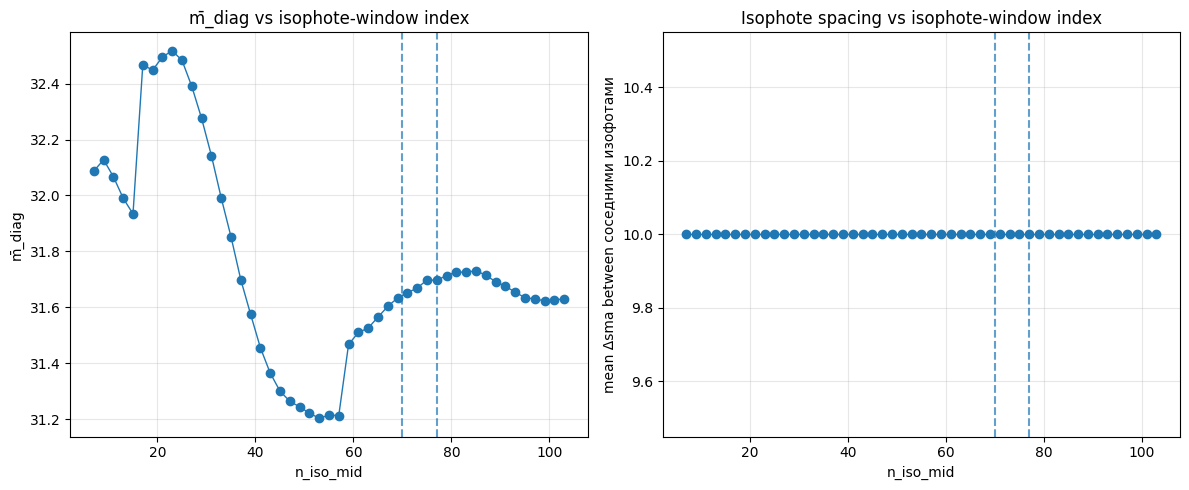

In [35]:

if not rows:
    raise RuntimeError("[PLOT-ISO] rows is empty")

# Сортируем по положению окна
rows_plot = sorted(rows, key=lambda r: r["i0"])

# X = середина окна в индексах fitted isophotes
n_iso_mid = np.array([r["i1"] for r in rows_plot], dtype=float)

# Y1 = диагностический mbar
mbar_diag = np.array([r["mbar"] for r in rows_plot], dtype=float)

# Y2 = средний зазор между соседними изофотами внутри окна
dsma_mean_arr = np.array([r["dsma_mean"] for r in rows_plot], dtype=float)

# Для наглядности отметим выбранное окно
#chosen_mid = 0.5 * (chosen["i0"] + chosen["i1"])

plt.figure(figsize=(12, 5))

# --- График 1: mbar vs n_iso_mid
plt.subplot(1, 2, 1)
plt.plot(n_iso_mid, mbar_diag, marker="o", linewidth=1)
plt.axvline(chosen["i0"], linestyle="--", alpha=0.7)
plt.axvline(chosen["i1"], linestyle="--", alpha=0.7)
plt.xlabel("n_iso_mid")
plt.ylabel("m̄_diag")
plt.title("m̄_diag vs isophote-window index")
plt.grid(True, alpha=0.3)

# --- График 2: dsma_mean vs n_iso_mid
plt.subplot(1, 2, 2)
plt.plot(n_iso_mid, dsma_mean_arr, marker="o", linewidth=1)
plt.axvline(chosen["i0"], linestyle="--", alpha=0.7)
plt.axvline(chosen["i1"], linestyle="--", alpha=0.7)
plt.xlabel("n_iso_mid")
plt.ylabel("mean Δsma between соседними изофотами")
plt.title("Isophote spacing vs isophote-window index")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

[03:44:48] plotting sigma-clipped residual-pixel distribution inside chosen SBF zone...
[03:44:48] [PLOT-HIST] raw N=204356, clipped N=204356, median=1.015e-01, std=6.536e-01, dyn=3.997e+00


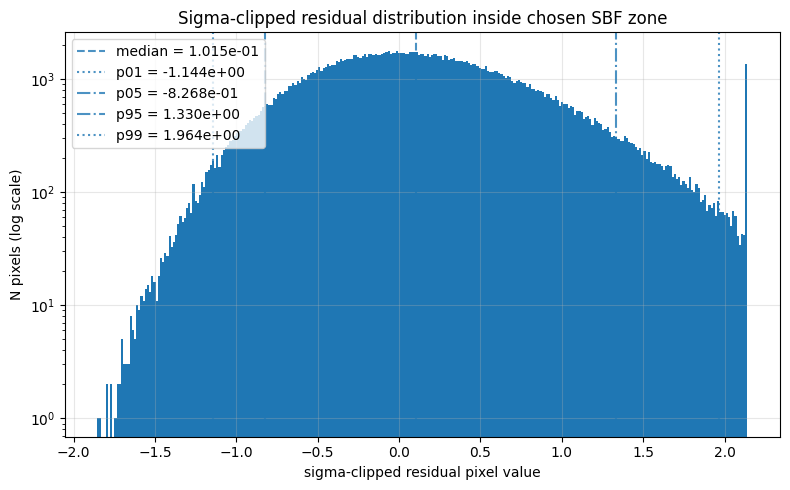

In [36]:
print("plotting sigma-clipped residual-pixel distribution inside chosen SBF zone...")

use_hist = (~mask_sbf) & np.isfinite(science_resid)
vals_hist = science_resid[use_hist]

if vals_hist.size < MIN_PIXELS_SBF:
    raise RuntimeError(f"[PLOT-HIST] too few residual pixels: N={vals_hist.size}")

# ------------------------------------------------------------
# 1. Sigma-clipping той же логикой, что и в выборе окон
# ------------------------------------------------------------
mean_clip, med_clip, std_clip = sigma_clipped_stats(
    vals_hist,
    sigma=CLIP_SIGMA_QC,
    maxiters=CLIP_MAXIT_QC
)

if (not np.isfinite(std_clip)) or std_clip <= 0:
    raise RuntimeError(f"[PLOT-HIST] bad clipped std={std_clip}")

lo_rob = med_clip - CLIP_SIGMA_QC * std_clip
hi_rob = med_clip + CLIP_SIGMA_QC * std_clip

vals_hist_rob = vals_hist[(vals_hist >= lo_rob) & (vals_hist <= hi_rob)]

if vals_hist_rob.size < MIN_PIXELS_SIGMA_CLIP:
    raise RuntimeError(f"[PLOT-HIST] too few sigma-clipped residual pixels: N={vals_hist_rob.size}")

# ------------------------------------------------------------
# 2. Статистики уже по clipped-распределению
# ------------------------------------------------------------
med_hist = float(np.nanmedian(vals_hist_rob))
p01 = float(np.nanpercentile(vals_hist_rob, 1.0))
p05 = float(np.nanpercentile(vals_hist_rob, 5.0))
p95 = float(np.nanpercentile(vals_hist_rob, 95.0))
p99 = float(np.nanpercentile(vals_hist_rob, 99.0))

dyn_hist = float(np.nanmax(vals_hist_rob) - np.nanmin(vals_hist_rob))
std_hist = float(np.nanstd(vals_hist_rob))

print(
    f"[PLOT-HIST] raw N={vals_hist.size}, clipped N={vals_hist_rob.size}, "
    f"median={med_hist:.3e}, std={std_hist:.3e}, dyn={dyn_hist:.3e}"
)

# ------------------------------------------------------------
# 3. Гистограмма clipped-распределения
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(vals_hist_rob, bins=300, log=True)

plt.axvline(med_hist, linestyle="--", alpha=0.8, label=f"median = {med_hist:.3e}")
plt.axvline(p01, linestyle=":", alpha=0.8, label=f"p01 = {p01:.3e}")
plt.axvline(p05, linestyle="-.", alpha=0.8, label=f"p05 = {p05:.3e}")
plt.axvline(p95, linestyle="-.", alpha=0.8, label=f"p95 = {p95:.3e}")
plt.axvline(p99, linestyle=":", alpha=0.8, label=f"p99 = {p99:.3e}")

plt.xlabel("sigma-clipped residual pixel value")
plt.ylabel("N pixels (log scale)")
plt.title("Sigma-clipped residual distribution inside chosen SBF zone")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Проверяем область + базовые статы

In [37]:
print("checking chosen SBF zone...")

use = (~mask_sbf) & np.isfinite(science_resid) & np.isfinite(science_model) & (science_model > 0.0)
n_use = int(use.sum())

if n_use < MIN_PIXELS_SBF:
    raise RuntimeError(f"[SBF-ZONE] too few usable pixels: N={n_use}")

vals = science_resid[use]

# ------------------------------------------------------------
# 1. Сырые статистики
# ------------------------------------------------------------
vmin = float(np.nanmin(vals))
vmax = float(np.nanmax(vals))
vmed = float(np.nanmedian(vals))
vmean = float(np.nanmean(vals))
vstd = float(np.nanstd(vals))
vdyn = float(vmax - vmin)

p01 = float(np.nanpercentile(vals, 1.0))
p05 = float(np.nanpercentile(vals, 5.0))
p95 = float(np.nanpercentile(vals, 95.0))
p99 = float(np.nanpercentile(vals, 99.0))

print(
    f"[SBF-ZONE][raw] N={n_use}, "
    f"min={vmin:.3e}, p01={p01:.3e}, p05={p05:.3e}, \n"
    f"med={vmed:.3e}, mean={vmean:.3e}, std={vstd:.3e}, \n"
    f"p95={p95:.3e}, p99={p99:.3e}, max={vmax:.3e}, dyn={vdyn:.3e}"
)

# ------------------------------------------------------------
# 2. Sigma-clipped статистики
# ------------------------------------------------------------
mean_clip, med_clip, std_clip = sigma_clipped_stats(
    vals,
    sigma=CLIP_SIGMA_QC,
    maxiters=CLIP_MAXIT_QC
)

if (not np.isfinite(std_clip)) or std_clip <= 0:
    raise RuntimeError(f"[SBF-ZONE] bad clipped std={std_clip}")

lo_rob = med_clip - CLIP_SIGMA_QC * std_clip
hi_rob = med_clip + CLIP_SIGMA_QC * std_clip

vals_rob = vals[(vals >= lo_rob) & (vals <= hi_rob)]

if vals_rob.size < MIN_PIXELS_SIGMA_CLIP:
    raise RuntimeError(f"[SBF-ZONE] too few clipped pixels: N={vals_rob.size}")

vmin_rob = float(np.nanmin(vals_rob))
vmax_rob = float(np.nanmax(vals_rob))
vmed_rob = float(np.nanmedian(vals_rob))
vmean_rob = float(np.nanmean(vals_rob))
vstd_rob = float(np.nanstd(vals_rob))
vdyn_rob = float(vmax_rob - vmin_rob)

p01_rob = float(np.nanpercentile(vals_rob, 1.0))
p05_rob = float(np.nanpercentile(vals_rob, 5.0))
p95_rob = float(np.nanpercentile(vals_rob, 95.0))
p99_rob = float(np.nanpercentile(vals_rob, 99.0))

print(
    f"[SBF-ZONE][clipped] N={vals_rob.size}, "
    f"min={vmin_rob:.3e}, p01={p01_rob:.3e}, p05={p05_rob:.3e}, \n"
    f"med={vmed_rob:.3e}, mean={vmean_rob:.3e}, std={vstd_rob:.3e}, \n"
    f"p95={p95_rob:.3e}, p99={p99_rob:.3e}, max={vmax_rob:.3e}, dyn={vdyn_rob:.3e}"
)

[03:44:49] checking chosen SBF zone...
[03:44:49] [SBF-ZONE][raw] N=204356, min=-1.856e+00, p01=-1.144e+00, p05=-8.268e-01, 
med=1.015e-01, mean=1.546e-01, std=6.536e-01, 
p95=1.330e+00, p99=1.964e+00, max=2.141e+00, dyn=3.997e+00
[03:44:49] [SBF-ZONE][clipped] N=204356, min=-1.856e+00, p01=-1.144e+00, p05=-8.268e-01, 
med=1.015e-01, mean=1.546e-01, std=6.536e-01, 
p95=1.330e+00, p99=1.964e+00, max=2.141e+00, dyn=3.997e+00


## PSF (с кэшем)

Это лучше оставить отдельной ячейкой, потому что PSF — независимая боль.

In [38]:
print("loading/building PSF...")

psf_file = PSFREF if PSFREF is not None else f150w_path
psf_cache_path = out_dir / f"{stem}_psf_{PSF_SIZE}.fits"

if psf_cache_path.exists():
    with fits.open(psf_cache_path, memmap=False) as hd:
        psf = np.array(hd[0].data, dtype=float)
    psf = np.nan_to_num(psf, nan=0.0)
    psf /= psf.sum()
    print(f"[PSF] loaded cache → {psf_cache_path}")
else:
    sim = stpsf.setup_sim_to_match_file(psf_file)
    psf_hdul = sim.calc_psf(nlambda=PSF_NLAMBDA, fov_pixels=PSF_SIZE)

    if isinstance(psf_hdul, fits.HDUList):
        psf = np.array(psf_hdul[0].data, dtype=float)
    elif isinstance(psf_hdul, fits.PrimaryHDU):
        psf = np.array(psf_hdul.data, dtype=float)
    else:
        psf = np.array(psf_hdul, dtype=float)

    if psf.ndim == 3:
        psf = psf.sum(axis=0)

    psf = np.nan_to_num(psf, nan=0.0)
    psf /= psf.sum()

    fits.writeto(psf_cache_path, psf.astype(np.float32), overwrite=True)
    print(f"[PSF] saved cache → {psf_cache_path}")
print(f"[PSF] shape={psf.shape}, sum={psf.sum():.6f}, min={psf.min():.3e}, max={psf.max():.3e}")

[03:44:49] loading/building PSF...
[03:44:49] [PSF] loaded cache → data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_psf_129.fits
[03:44:49] [PSF] shape=(516, 516), sum=1.000000, min=6.482e-10, max=1.546e-02


##  FFT и P(k), E(k)

Это диагностика формы, не “истина по амплитуде”.

In [39]:
print(f"[FFT] workers={FFT_WORKERS}")

print(
    f"[FFT] spectral config: E-realizations={FFT_E_REALIZATIONS_MAIN}, "
    f"kbins={FFT_KBINS_N}, k-range={FFT_K_RANGE_MAIN}"
)

# ------------------------------------------------------------
# 1. Рабочее окно измерения
# ------------------------------------------------------------
window = (~mask_sbf) & np.isfinite(science_resid) & np.isfinite(science_model) & (science_model > 0.0)

n_use_fft = int(window.sum())
if n_use_fft < MIN_PIXELS_SBF:
    raise RuntimeError(f"[FFT] too few usable pixels for FFT: N={n_use_fft}")

W = window.astype(float)

# ------------------------------------------------------------
# 2. P(k) для реального residual
# ------------------------------------------------------------
data_fft = np.zeros_like(science_resid, dtype=float)
data_fft[window] = science_resid[window]

# Убираем среднее только в рабочей области
mean_fft = float(np.nanmean(data_fft[window]))
data_fft[window] -= mean_fft

print(f"[FFT] usable pixels={n_use_fft}, mean_removed={mean_fft:.3e}")

with set_workers(FFT_WORKERS):
    F = fft2(data_fft)

# Масштаб P2d пока оставляем простым:
# деление на число используемых пикселей.
P2d = (np.abs(F) ** 2) / float(n_use_fft)

# ------------------------------------------------------------
# 3. Общая k-сетка для 2D -> 1D
# ------------------------------------------------------------
ny, nx = science_resid.shape

ky = fftshift(fftfreq(ny))
kx = fftshift(fftfreq(nx))
KX, KY = np.meshgrid(kx, ky)
kr = np.hypot(KX, KY)

P2d_s = fftshift(P2d)

kbins = np.linspace(0.0, float(kr.max()), FFT_KBINS_N)

Pk_vals = np.full(len(kbins) - 1, np.nan, dtype=float)
Pk_k = np.full_like(Pk_vals, np.nan)

for i in range(len(Pk_vals)):
    sel = (kr >= kbins[i]) & (kr < kbins[i + 1])
    vals = P2d_s[sel]
    if vals.size >= MIN_POINTS_PK_BIN:
        Pk_vals[i] = float(np.nanmedian(vals))
        Pk_k[i] = 0.5 * (kbins[i] + kbins[i + 1])

mP = np.isfinite(Pk_vals) & np.isfinite(Pk_k) & (Pk_k > 0)
Pk = (Pk_k[mP], Pk_vals[mP])

print(f"[FFT] P(k) bins kept = {mP.sum()}")

# ------------------------------------------------------------
# 4. Подготовка большого PSF-ядра для свёртки шума
# ------------------------------------------------------------
big_psf = np.zeros((ny, nx), dtype=float)

py, px = psf.shape
y0_psf = ny // 2 - py // 2
x0_psf = nx // 2 - px // 2
big_psf[y0_psf:y0_psf + py, x0_psf:x0_psf + px] = psf

# ------------------------------------------------------------
# 5. Эмпирический E(k):
#    белый шум -> свёртка с PSF -> то же окно -> то же вычитание среднего -> FFT
# ------------------------------------------------------------
Ek_stack = []

rng = np.random.default_rng(None)

for i_real in range(FFT_E_REALIZATIONS_MAIN):
    # Белый шум N(0,1) на полном кадре
    noise = rng.normal(loc=0.0, scale=1.0, size=(ny, nx))

    # Свёртка белого шума с PSF через FFT
    with set_workers(FFT_WORKERS):
        F_noise = fft2(noise)
        F_psf = fft2(big_psf)
        sim = np.real(np.fft.ifft2(F_noise * F_psf))

    # Применяем ТО ЖЕ окно, что и для данных
    sim_masked = np.zeros_like(sim, dtype=float)
    sim_masked[window] = sim[window]

    # Вычитаем среднее по той же рабочей области
    sim_mean = float(np.nanmean(sim_masked[window]))
    sim_masked[window] -= sim_mean

    # FFT симулированного поля
    with set_workers(FFT_WORKERS):
        F_sim = fft2(sim_masked)

    E2d_sim = (np.abs(F_sim) ** 2) / float(n_use_fft)
    E2d_sim_s = fftshift(E2d_sim)

    Ek_vals_i = np.full(len(kbins) - 1, np.nan, dtype=float)

    for j in range(len(Ek_vals_i)):
        sel = (kr >= kbins[j]) & (kr < kbins[j + 1])
        vals = E2d_sim_s[sel]
        if vals.size >= MIN_POINTS_PK_BIN:
            Ek_vals_i[j] = float(np.nanmedian(vals))

    Ek_stack.append(Ek_vals_i)

Ek_stack = np.array(Ek_stack, dtype=float)

# Усредняем expectation spectrum по реализациям
Ek_vals = np.nanmedian(Ek_stack, axis=0)
Ek_k = 0.5 * (kbins[:-1] + kbins[1:])

mE = np.isfinite(Ek_vals) & np.isfinite(Ek_k) & (Ek_k > 0)
Ek = (Ek_k[mE], Ek_vals[mE])

print(f"[FFT] E(k) bins kept = {mE.sum()}")
print(f"[FFT] E(k) realizations = {FFT_E_REALIZATIONS_MAIN}")
print("[FFT] P(k) and empirical E(k) ready")

[03:44:49] [FFT] workers=-1
[03:44:49] [FFT] spectral config: E-realizations=16, kbins=80, k-range=(0.03, 0.4)
[03:44:49] [FFT] usable pixels=204356, mean_removed=1.546e-01
[03:44:55] [FFT] P(k) bins kept = 79
[03:47:24] [FFT] E(k) bins kept = 79
[03:47:24] [FFT] E(k) realizations = 16
[03:47:24] [FFT] P(k) and empirical E(k) ready


## Фит P0

In [40]:
print("fitting P(k) = P0 * E(k) + P1 ...")

# ------------------------------------------------------------------
# 1. Рабочее окно по пространственным частотам
# ------------------------------------------------------------------
# kmin=0.03:
#   отрезаем самые низкие частоты, где обычно сидят ошибки гладкой модели,
#   остаточные градиенты и оконная функция аннулуса.
#
# kmax=0.40:
#   отрезаем самые высокие частоты, где уже доминируют шум, дискретизация
#   и прочие мелкие гадости.
#
# Это пока эвристический диапазон, но для первой проверки он разумный.
kmin, kmax = FFT_K_RANGE_MAIN

kP, P = Pk
kE, E = Ek

sel = (kP >= kmin) & (kP <= kmax)

if int(sel.sum()) < MIN_POINTS_FIT:
    raise RuntimeError(f"[FIT] too few P(k) points in k-window: N={int(sel.sum())}")

# Интерполируем E(k) на сетку P(k), чтобы сравнивать одно с другим по одним и тем же k.
E_int = np.interp(kP[sel], kE, E, left=np.nan, right=np.nan)

x = E_int
y = P[sel]

# Оставляем только конечные и положительные значения.
# P(k) и E(k) физически должны быть > 0.
m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
x = x[m]
y = y[m]

if x.size < MIN_POINTS_FIT:
    raise RuntimeError(f"[FIT] too few valid points after cleaning: N={x.size}")

# ------------------------------------------------------------------
# 2. Диагностика: насколько форма P(k) вообще похожа на E(k)
# ------------------------------------------------------------------
corr = float(np.corrcoef(x, y)[0, 1])
print(f"[FIT] window k={kmin:.3f}..{kmax:.3f}, N={x.size}, corr(E,P)≈{corr:.3f}")

# Если корреляция совсем слабая, P0 интерпретировать будет опасно.
# Но пока не падаем, а просто честно печатаем предупреждение.
if not np.isfinite(corr) or abs(corr) < FIT_CORR_WARN:
    print("[FIT] WARNING: weak correlation between E(k) and P(k)")

# ------------------------------------------------------------------
# 3. Линейный фит y = P0 * x + P1
# ------------------------------------------------------------------
A = np.vstack([x, np.ones_like(x)]).T
P0, P1 = np.linalg.lstsq(A, y, rcond=None)[0]

# frac = какая доля модели приходится на PSF-подобную компоненту
den = P0 + P1
frac = float(P0 / den) if np.isfinite(den) and den != 0 else np.nan

print(f"[FIT] P0={P0:.3e}, P1={P1:.3e}, frac={frac:.3f}")
print(
    f"[FIT] x-range=[{np.nanmin(x):.3e}, {np.nanmax(x):.3e}], "
    f"y-range=[{np.nanmin(y):.3e}, {np.nanmax(y):.3e}]"
)
y_fit = P0 * x + P1
fit_resid = y - y_fit
print(
    f"[FIT] residuals: med={np.nanmedian(fit_resid):.3e}, "
    f"std={np.nanstd(fit_resid):.3e}"
)
# ------------------------------------------------------------------
# 4. Доп. sanity-check
# ------------------------------------------------------------------
if not np.isfinite(P0) or not np.isfinite(P1):
    print("[FIT] WARNING: non-finite fit coefficients")

if P0 <= 0:
    print("[FIT] WARNING: P0 <= 0, physical SBF interpretation is doubtful")

if np.isfinite(P1) and abs(P1) > FIT_P1_WARN_FACTOR * max(P0, 1e-30):
    print("[FIT] WARNING: |P1| >> P0, white-noise term dominates fit")

[03:47:24] fitting P(k) = P0 * E(k) + P1 ...
[03:47:24] [FIT] window k=0.030..0.400, N=42, corr(E,P)≈0.893
[03:47:24] [FIT] P0=1.855e+01, P1=5.780e-01, frac=0.970
[03:47:24] [FIT] x-range=[3.277e-05, 2.394e-01], y-range=[3.846e-02, 4.164e+00]
[03:47:24] [FIT] residuals: med=-1.700e-01, std=5.023e-01


## Коррекция $P_r$ и расчёт mbar

Здесь `P0` остаётся raw PSF-like spectral component. Для science-result нужно вычитать `Pr` от unresolved contaminants и использовать уже `P_fluc = P0 - Pr`.


In [41]:
print("computing corrected mbar from spectral P0 - Pr ...")

# ------------------------------------------------------------
# 1. Средняя яркость галактики в том же эллиптическом annulus
# ------------------------------------------------------------
window_main = (~mask_sbf) & np.isfinite(science_resid) & np.isfinite(science_model) & (science_model > 0.0)
if "window" not in globals() or not np.array_equal(window, window_main):
    raise RuntimeError("[SBF] window does not match current mask_sbf/resid/model; rerun FFT and fit cells before mbar")

n_I = int(window_main.sum())
if n_I < MIN_PIXELS_SBF:
    raise RuntimeError(f"[SBF] too few model pixels in annulus: N={n_I}")

Imean = float(np.nanmean(science_model[window_main]))
print(
    f"[SBF] model in zone: N={n_I}, "
    f"min={np.nanmin(science_model[window_main]):.3e}, "
    f"med={np.nanmedian(science_model[window_main]):.3e}, "
    f"max={np.nanmax(science_model[window_main]):.3e}"
)
if (not np.isfinite(Imean)) or (Imean <= 0.0):
    raise RuntimeError(f"[SBF] bad Imean={Imean}")

# ------------------------------------------------------------
# 2. Formal uncertainty of the raw P(k)=P0*E(k)+P1 fit
# ------------------------------------------------------------
n_fit_main = 0
fit_resid_std_main = np.nan
P0_fit_sigma_main = np.nan
P1_fit_sigma_main = np.nan
mbar_fit_sigma_raw = np.nan
fit_uncertainty_note = "fit covariance unavailable"

if "x" in globals() and "y" in globals():
    x_fit = np.asarray(x, dtype=float)
    y_fit_data = np.asarray(y, dtype=float)
    good_fit = np.isfinite(x_fit) & np.isfinite(y_fit_data)
    x_fit = x_fit[good_fit]
    y_fit_data = y_fit_data[good_fit]

    if x_fit.size >= 3:
        A_fit = np.vstack([x_fit, np.ones_like(x_fit)]).T
        fit_resid_main = y_fit_data - (P0 * x_fit + P1)
        n_fit_main = int(x_fit.size)
        dof_fit = max(n_fit_main - 2, 1)
        fit_resid_std_main = float(np.nanstd(fit_resid_main, ddof=1))

        try:
            sigma2_fit = float(np.nansum(fit_resid_main * fit_resid_main) / dof_fit)
            cov_fit = sigma2_fit * np.linalg.pinv(A_fit.T @ A_fit)
            P0_fit_sigma_main = float(np.sqrt(max(cov_fit[0, 0], 0.0)))
            P1_fit_sigma_main = float(np.sqrt(max(cov_fit[1, 1], 0.0)))
            if np.isfinite(P0_fit_sigma_main) and P0_fit_sigma_main > 0.0:
                mbar_fit_sigma_raw = float((2.5 / np.log(10.0)) * P0_fit_sigma_main / P0)
                fit_uncertainty_note = "formal covariance of raw P(k)=P0*E(k)+P1"
        except Exception as err:
            fit_uncertainty_note = f"fit covariance failed: {err}"
    else:
        fit_uncertainty_note = f"too few fit points: N={x_fit.size}"
else:
    fit_uncertainty_note = "x/y from the fit cell are unavailable"

# ------------------------------------------------------------
# 3. Residual variance Pr from unresolved contaminants
# ------------------------------------------------------------
pr_main_info = estimate_pr_for_region(
    region_mask=annulus_ell,
    model=science_model,
    region_name="elliptical_chosen",
    region_origin_x=0,
    region_origin_y=0,
)
src_main_summary = summarize_sources_in_region_mask(
    annulus_ell,
    region_origin_x=0,
    region_origin_y=0,
)

# P0 is the raw PSF-like component in the power spectrum. It contains both
# stellar SBF and residual power from unresolved contaminants.
# Pr estimates the contaminant part. The corrected stellar fluctuation power is
# therefore P_fluc = P0 - Pr and only P_fluc should be turned into mbar.
power_main = solve_sbf_power_budget(
    P0=P0,
    Imean=Imean,
    Pr=pr_main_info.get("Pr", np.nan),
    pix_area=pix_area,
    P0_fit_sigma=P0_fit_sigma_main,
)

Pf_spec_raw = power_main.get("Pf_spec_raw", np.nan)
mbar_spec_raw = power_main.get("mbar_spec_raw", np.nan)
Pr = power_main.get("Pr", np.nan)
P_fluc = power_main.get("P_fluc", np.nan)
Pr_over_P0 = power_main.get("Pr_over_P0", np.nan)
Pf_spec = power_main.get("Pf_spec", np.nan)
Pf_spec_sigma_formal_raw = power_main.get("Pf_spec_sigma_formal_raw", np.nan)
Pf_spec_sigma_formal = power_main.get("Pf_spec_sigma_formal", np.nan)
mbar_fit_sigma = power_main.get("mbar_fit_sigma", np.nan)
mbar_spec = power_main.get("mbar_spec", np.nan)
measurement_ok = bool(power_main.get("measurement_ok", False))
failure_reason = power_main.get("failure_reason", "")

print(f"[SBF] science residual/model = {science_resid_name} / {science_model_name}")
print(f"[SBF] Imean={Imean:.3e}")
print(f"[SBF] raw fit: P0={P0:.3e}, P1={P1:.3e}, frac={frac:.3f}, corr={corr:.3f}")
print(f"[SBF] raw Pf_spec={Pf_spec_raw:.3e}, raw mbar={mbar_spec_raw:.4f} mag")
print(
    f"[SRC-CAT-REGION] elliptical_chosen: overlap={src_main_summary['n_overlap']}, "
    f"valid={src_main_summary['n_valid']}, nonpositive_flux={src_main_summary['n_nonpositive_flux']}, "
    f"mag_med={src_main_summary['mag_med']:.3f}"
)
print(
    f"[Pr] Nsrc_valid={pr_main_info.get('n_detected_sources', 0)}, "
    f"Nsrc_overlap={pr_main_info.get('n_detected_sources_total', 0)}, "
    f"m_lim={pr_main_info.get('m_lim', np.nan):.3f} ({pr_main_info.get('m_lim_method', 'unknown')}), "
    f"gamma={pr_main_info.get('lf_gamma', np.nan):.3f}, "
    f"phi(m_lim)={pr_main_info.get('lf_phi_mlim', np.nan):.3e}, "
    f"Pr={Pr:.3e}"
)
print(f"[Pr] fit={pr_main_info.get('lf_fit_method', 'unknown')}; note={pr_main_info.get('pr_note', '')}")
print(f"[Pr] correction fraction Pr/P0 = {Pr_over_P0:.3%}" if np.isfinite(Pr_over_P0) else "[Pr] correction fraction unavailable")

if np.isfinite(Pr_over_P0) and Pr_over_P0 > SBF_PR_MAX_CORRECTION_WARN:
    print("[Pr] WARNING: unresolved-source correction is large compared to raw P0")

if measurement_ok:
    print(f"[SBF] corrected stellar power P_fluc={P_fluc:.3e}")
    print(f"[SBF] corrected Pf_spec={Pf_spec:.3e}")
    print(f"m̄(F150W) [spectral, corrected] = {mbar_spec:.3f} mag")
else:
    print(f"[SBF] corrected measurement is invalid: {failure_reason}")

print(
    f"[SBF-UNC][formal-fit] N_fit={n_fit_main}, "
    f"fit_resid_std={fit_resid_std_main:.3e} power-units"
)
if np.isfinite(P0_fit_sigma_main) and P0_fit_sigma_main > 0.0:
    print(
        f"[SBF-UNC][formal-fit] sigma(P0)={P0_fit_sigma_main:.3e} "
        f"({P0_fit_sigma_main / P0:.3%}), "
        f"sigma(Pf_raw)={Pf_spec_sigma_formal_raw:.3e}, "
        f"sigma(Pf_corr)={Pf_spec_sigma_formal:.3e}"
    )
else:
    print(f"[SBF-UNC][formal-fit] {fit_uncertainty_note}")

sbf_main_diagnostics = {
    "region": "elliptical_chosen",
    "science_resid_name": science_resid_name,
    "science_model_name": science_model_name,
    "measurement_ok": measurement_ok,
    "failure_reason": failure_reason,
    "kmin": float(kmin),
    "kmax": float(kmax),
    "n_use": int(n_I),
    "n_fit": int(n_fit_main),
    "Imean": Imean,
    "P0": float(P0),
    "P1": float(P1),
    "Pr": Pr,
    "P_fluc": P_fluc,
    "Pr_over_P0": Pr_over_P0,
    "Pf_spec_raw": Pf_spec_raw,
    "Pf_spec": Pf_spec,
    "mbar_spec_raw": mbar_spec_raw,
    "mbar_spec": mbar_spec,
    "fit_resid_std": fit_resid_std_main,
    "P0_fit_sigma": P0_fit_sigma_main,
    "P1_fit_sigma": P1_fit_sigma_main,
    "Pf_spec_sigma_formal_raw": Pf_spec_sigma_formal_raw,
    "Pf_spec_sigma_formal": Pf_spec_sigma_formal,
    "mbar_fit_sigma_raw": mbar_fit_sigma_raw,
    "mbar_fit_sigma": mbar_fit_sigma,
    "n_detected_sources": pr_main_info.get("n_detected_sources", 0),
    "n_detected_sources_total": pr_main_info.get("n_detected_sources_total", 0),
    "m_lim": pr_main_info.get("m_lim", np.nan),
    "m_lim_method": pr_main_info.get("m_lim_method", "unknown"),
    "lf_model": pr_main_info.get("lf_model", "combined_power_law"),
    "lf_gamma": pr_main_info.get("lf_gamma", np.nan),
    "lf_phi_mlim": pr_main_info.get("lf_phi_mlim", np.nan),
    "lf_fit_method": pr_main_info.get("lf_fit_method", "unknown"),
    "lf_fit_rmse": pr_main_info.get("lf_fit_rmse", np.nan),
    "lf_n_fit_bins": pr_main_info.get("lf_n_fit_bins", 0),
    "lf_n_fit_sources": pr_main_info.get("lf_n_fit_sources", 0),
    "pr_note": pr_main_info.get("pr_note", ""),
    "notes": "corrected stellar fluctuation power uses P_fluc = P0 - Pr",
}

pd.DataFrame([sbf_main_diagnostics])


[03:47:24] computing corrected mbar from spectral P0 - Pr ...
[03:47:25] [SBF] model in zone: N=204356, min=7.219e+00, med=7.893e+00, max=8.845e+00
[03:47:25] [SBF] science residual/model = resid_full_clip_3p5sigma / model_full
[03:47:25] [SBF] Imean=7.931e+00
[03:47:25] [SBF] raw fit: P0=1.855e+01, P1=5.780e-01, frac=0.970, corr=0.893
[03:47:25] [SBF] raw Pf_spec=2.338e+00, raw mbar=27.0774 mag
[03:47:25] [SRC-CAT-REGION] elliptical_chosen: overlap=856, valid=856, nonpositive_flux=0, mag_med=25.459
[03:47:25] [Pr] Nsrc_valid=856, Nsrc_overlap=856, m_lim=25.875 (region_turnover_hist), gamma=0.406, phi(m_lim)=3.995e-03, Pr=2.205e-01
[03:47:25] [Pr] fit=local_histogram; note=local combined contaminant LF
[03:47:25] [Pr] correction fraction Pr/P0 = 1.189%
[03:47:25] [SBF] corrected stellar power P_fluc=1.832e+01
[03:47:25] [SBF] corrected Pf_spec=2.310e+00
[03:47:25] m̄(F150W) [spectral, corrected] = 27.090 mag
[03:47:25] [SBF-UNC][formal-fit] N_fit=42, fit_resid_std=5.084e-01 power-units

,region,science_resid_name,science_model_name,measurement_ok,failure_reason,kmin,kmax,n_use,n_fit,Imean,...,m_lim_method,lf_model,lf_gamma,lf_phi_mlim,lf_fit_method,lf_fit_rmse,lf_n_fit_bins,lf_n_fit_sources,pr_note,notes
0,elliptical_chosen,resid_full_clip_3p5sigma,model_full,True,,0.03,0.4,204356,42,7.931408,...,region_turnover_hist,combined_power_law,0.405973,0.003995,local_histogram,0.064668,6,652,local combined contaminant LF,corrected stellar fluctuation power uses P_flu...


## spectral mbar across plateau windows

In [42]:
print("measuring spectral mbar across plateau windows...")
print(f"[SBF-SPEC-PLATEAU] unified science path: residual={science_resid_name}, model={science_model_name}")

if best_plateau is None:
    subset = [chosen]
else:
    subset = rows_sorted[best_plateau["i0"]:best_plateau["i1"] + 1]

spec_rows = []
spec_rows_invalid = []
for j, row in enumerate(subset):
    print(
        f"[SBF-SPEC-PLATEAU] window {j+1}/{len(subset)}: "
        f"sma={row['sma_in']:.1f}..{row['sma_out']:.1f}"
    )

    out = measure_sbf_spec_for_row(
        row=row,
        resid=science_resid,
        model=science_model,
        premask=premask,
        psf=psf,
        pix_area=pix_area,
        kmin=FFT_K_RANGE_MAIN[0],
        kmax=FFT_K_RANGE_MAIN[1],
        fft_workers=FFT_WORKERS,
        n_e_realizations=FFT_E_REALIZATIONS_DIAG,
        kbins_n=FFT_KBINS_N,
    )

    if out is None:
        print("[SBF-SPEC-PLATEAU]   -> raw spectral fit failed")
        continue

    corr_text = f"{out['Pr_over_P0']:.3%}" if np.isfinite(out.get("Pr_over_P0", np.nan)) else "n/a"
    corr_mbar_text = f"{out['mbar_spec']:.4f}" if np.isfinite(out.get("mbar_spec", np.nan)) else "nan"
    print(
        f"[SBF-SPEC-PLATEAU]   raw mbar={out['mbar_spec_raw']:.4f}, corrected mbar={corr_mbar_text}, "
        f"P0={out['P0']:.3e}, Pr={out['Pr']:.3e}, P_fluc={out['P_fluc']:.3e}, Pr/P0={corr_text}"
    )
    print(
        f"[SBF-SPEC-PLATEAU]   Nsrc_valid={out['n_detected_sources']}, "
        f"Nsrc_overlap={out.get('n_detected_sources_total', 0)}, "
        f"m_lim={out['m_lim']:.3f} ({out['m_lim_method']}), "
        f"gamma={out['lf_gamma']:.3f}, fit={out['lf_fit_method']}, corr(E,P)={out['corr']:.3f}, frac={out['frac']:.3f}, Npix={out['n_use']}"
    )

    if out.get("measurement_ok", False):
        spec_rows.append(out)
    else:
        spec_rows_invalid.append(out)
        print(f"[SBF-SPEC-PLATEAU]   -> corrected measurement invalid: {out.get('failure_reason', '')}")

min_success = SINGLE_WINDOW_SPEC_MIN_SUCCESS if best_plateau is None else PLATEAU_SPEC_MIN_SUCCESS
if len(spec_rows) < min_success:
    raise RuntimeError(
        f"[SBF-SPEC-PLATEAU] too few successful corrected spectral windows: N={len(spec_rows)}"
    )

mbar_spec_arr = np.array([r["mbar_spec"] for r in spec_rows], dtype=float)
mbar_spec_raw_arr = np.array([r["mbar_spec_raw"] for r in spec_rows], dtype=float)
P0_arr = np.array([r["P0"] for r in spec_rows], dtype=float)
Pr_arr = np.array([r["Pr"] for r in spec_rows], dtype=float)
Pfluc_arr = np.array([r["P_fluc"] for r in spec_rows], dtype=float)
Pr_over_P0_arr = np.array([r["Pr_over_P0"] for r in spec_rows], dtype=float)
corr_arr = np.array([r["corr"] for r in spec_rows], dtype=float)

mbar_spec_med = float(np.nanmedian(mbar_spec_arr))
mbar_spec_std = float(np.nanstd(mbar_spec_arr))
mbar_spec_raw_med = float(np.nanmedian(mbar_spec_raw_arr))

mbar_spec_mad = float(np.nanmedian(np.abs(mbar_spec_arr - mbar_spec_med)))
sigma_zone_spec = 1.4826 * mbar_spec_mad

print(f"[SBF-SPEC-PLATEAU] successful corrected windows = {len(spec_rows)}")
print(f"[SBF-SPEC-PLATEAU] invalid corrected windows     = {len(spec_rows_invalid)}")
print(f"[SBF-SPEC-PLATEAU] corrected mbar median        = {mbar_spec_med:.4f} mag")
print(f"[SBF-SPEC-PLATEAU] raw mbar median              = {mbar_spec_raw_med:.4f} mag")
print(f"[SBF-SPEC-PLATEAU] corrected mbar std           = {mbar_spec_std:.4e} mag")
print(f"[SBF-SPEC-PLATEAU] sigma_zone_spec              = {sigma_zone_spec:.4e} mag")
print(f"[SBF-SPEC-PLATEAU] P0 median                    = {np.nanmedian(P0_arr):.4e}")
print(f"[SBF-SPEC-PLATEAU] Pr median                    = {np.nanmedian(Pr_arr):.4e}")
print(f"[SBF-SPEC-PLATEAU] P_fluc median                = {np.nanmedian(Pfluc_arr):.4e}")
print(f"[SBF-SPEC-PLATEAU] median Pr/P0                 = {np.nanmedian(Pr_over_P0_arr):.3%}")
print(f"[SBF-SPEC-PLATEAU] corr median                  = {np.nanmedian(corr_arr):.4f}")


[03:47:25] measuring spectral mbar across plateau windows...
[03:47:25] [SBF-SPEC-PLATEAU] unified science path: residual=resid_full_clip_3p5sigma, model=model_full
[03:47:25] [SBF-SPEC-PLATEAU] window 1/6: sma=640.0..710.0
[03:48:47] [SBF-SPEC-PLATEAU]   raw mbar=27.0043, corrected mbar=27.0143, P0=2.321e+01, Pr=2.134e-01, P_fluc=2.299e+01, Pr/P0=0.919%
[03:48:47] [SBF-SPEC-PLATEAU]   Nsrc_valid=1251, Nsrc_overlap=1251, m_lim=25.875 (region_turnover_hist), gamma=0.273, fit=local_histogram, corr(E,P)=0.909, frac=0.972, Npix=185498
[03:48:47] [SBF-SPEC-PLATEAU] window 2/6: sma=660.0..730.0
[03:50:07] [SBF-SPEC-PLATEAU]   raw mbar=27.0187, corrected mbar=27.0301, P0=2.203e+01, Pr=2.300e-01, P_fluc=2.180e+01, Pr/P0=1.044%
[03:50:07] [SBF-SPEC-PLATEAU]   Nsrc_valid=1164, Nsrc_overlap=1164, m_lim=25.875 (region_turnover_hist), gamma=0.322, fit=local_histogram, corr(E,P)=0.910, frac=0.972, Npix=190040
[03:50:07] [SBF-SPEC-PLATEAU] window 3/6: sma=680.0..750.0
[03:51:27] [SBF-SPEC-PLATEAU]   

## Цвет по F090W/F150W

Грубая диагностика, как и у тебя было.

In [43]:
print("computing color in the same chosen SBF zone...")

if img_f090 is not None:
    ny_c = min(img.shape[0], img_f090.shape[0])
    nx_c = min(img.shape[1], img_f090.shape[1])

    img150_c = img[:ny_c, :nx_c]
    img090_c = img_f090[:ny_c, :nx_c]

    valid150_c = valid150[:ny_c, :nx_c]
    valid090_c = valid090[:ny_c, :nx_c]
    mask_sbf_c = mask_sbf[:ny_c, :nx_c]

    use_color = (
        (~mask_sbf_c) &
        valid150_c & valid090_c &
        np.isfinite(img150_c) & np.isfinite(img090_c)
    )

    n_color = int(use_color.sum())
    if n_color <= MIN_COLOR_PIXELS:
        print(f"[COLOR] too few usable pixels: N={n_color}")
    else:
        vals150 = img150_c[use_color]
        vals090 = img090_c[use_color]

        # Робастно режем хвосты отдельно в каждом фильтре
        _, med150_clip, std150_clip = sigma_clipped_stats(
            vals150, sigma=COLOR_CLIP_SIGMA, maxiters=COLOR_CLIP_MAXIT
        )
        _, med090_clip, std090_clip = sigma_clipped_stats(
            vals090, sigma=COLOR_CLIP_SIGMA, maxiters=COLOR_CLIP_MAXIT
        )

        lo150 = med150_clip - COLOR_CLIP_SIGMA * std150_clip
        hi150 = med150_clip + COLOR_CLIP_SIGMA * std150_clip
        lo090 = med090_clip - COLOR_CLIP_SIGMA * std090_clip
        hi090 = med090_clip + COLOR_CLIP_SIGMA * std090_clip

        keep = (
            (vals150 >= lo150) & (vals150 <= hi150) &
            (vals090 >= lo090) & (vals090 <= hi090)
        )

        vals150_rob = vals150[keep]
        vals090_rob = vals090[keep]

        n_rob = int(vals150_rob.size)
        if n_rob <= MIN_COLOR_PIXELS:
            print(f"[COLOR] too few sigma-clipped pixels: N={n_rob}")
        else:
            f150_med = float(np.nanmedian(vals150_rob))
            f090_med = float(np.nanmedian(vals090_rob))

            if f150_med > 0 and f090_med > 0:
                color = float(-2.5 * np.log10(f090_med / f150_med))
                print(
                    f"[COLOR] N_raw={n_color}, N_clip={n_rob}, "
                    f"F150_med={f150_med:.3e}, F090_med={f090_med:.3e}, "
                    f"(F090W - F150W) ≈ {color:.3f} mag"
                )
            else:
                print("[COLOR] median brightness not positive, color skipped")

[03:55:23] computing color in the same chosen SBF zone...
[03:55:25] [COLOR] N_raw=204356, N_clip=202331, F150_med=8.029e+00, F090_med=5.413e+00, (F090W - F150W) ≈ 0.428 mag


## Circular-Annulus Spectral SBF

Helpers, audits and spectral measurements for the fixed 8.2–16.4" and 16.4–32.8" annuli.


In [44]:
def build_region_mask_ellipse(shape, x0, y0, q, pa, sma_in, sma_out):
    ny, nx = shape
    yy, xx = np.ogrid[:ny, :nx]

    dx = xx.astype(float) - float(x0)
    dy = yy.astype(float) - float(y0)

    cosp = np.cos(pa)
    sinp = np.sin(pa)

    xp = dx * cosp + dy * sinp
    yp = -dx * sinp + dy * cosp

    r_ell = np.sqrt(xp * xp + (yp / q) * (yp / q))
    return (r_ell >= sma_in) & (r_ell <= sma_out)


def build_region_mask_circle(shape, x0, y0, r_in, r_out):
    ny, nx = shape
    yy, xx = np.ogrid[:ny, :nx]
    rr2 = (xx.astype(float) - float(x0)) ** 2 + (yy.astype(float) - float(y0)) ** 2
    return (rr2 >= float(r_in) ** 2) & (rr2 <= float(r_out) ** 2)


## Science Residual Audit

Эта таблица нужна, чтобы по одному и тому же `science_resid/science_model` сравнить
статистику остатков в `elliptical_chosen`, `circular_inner_lit` и `circular_outer_lit`
до самих spectral SBF fit-ов.


In [45]:
print("auditing unified science residual/model path across SBF regions...")

if "science_resid" not in globals() or "science_model" not in globals():
    raise RuntimeError("[SCIENCE-AUDIT] unified science path is unavailable")

pix_scale = float(np.sqrt(pix_area))
r1_in_audit = SBF_LIT_INNER_ARCSEC[0] / pix_scale
r1_out_audit = SBF_LIT_INNER_ARCSEC[1] / pix_scale
r2_in_audit = SBF_LIT_OUTER_ARCSEC[0] / pix_scale
r2_out_audit = SBF_LIT_OUTER_ARCSEC[1] / pix_scale

audit_regions = [
    {
        "region": "elliptical_chosen",
        "mask": build_region_mask_ellipse(science_resid.shape, x0_ann, y0_ann, q_ann, pa_ann, sma_in, sma_out),
    },
    {
        "region": "circular_inner_lit",
        "mask": build_region_mask_circle(science_resid.shape, x0_sbf_circ, y0_sbf_circ, r1_in_audit, r1_out_audit),
    },
    {
        "region": "circular_outer_lit",
        "mask": build_region_mask_circle(science_resid.shape, x0_sbf_circ, y0_sbf_circ, r2_in_audit, r2_out_audit),
    },
]

audit_rows = []
for reg in audit_regions:
    region_mask = np.asarray(reg["mask"], dtype=bool)
    use = region_mask & (~premask) & np.isfinite(science_resid) & np.isfinite(science_model) & (science_model > 0.0)
    vals_resid = science_resid[use]
    vals_model = science_model[use]
    n_use = int(use.sum())

    if n_use > 0:
        resid_median = float(np.nanmedian(vals_resid))
        resid_mean = float(np.nanmean(vals_resid))
        resid_std = float(np.nanstd(vals_resid))
        resid_p01 = float(np.nanpercentile(vals_resid, 1.0))
        resid_p99 = float(np.nanpercentile(vals_resid, 99.0))
        model_mean = float(np.nanmean(vals_model))
    else:
        resid_median = np.nan
        resid_mean = np.nan
        resid_std = np.nan
        resid_p01 = np.nan
        resid_p99 = np.nan
        model_mean = np.nan

    audit_rows.append({
        "region": reg["region"],
        "n_use": n_use,
        "resid_median": resid_median,
        "resid_mean": resid_mean,
        "resid_std": resid_std,
        "resid_p01": resid_p01,
        "resid_p99": resid_p99,
        "model_mean": model_mean,
        "science_resid_name": science_resid_name,
        "science_model_name": science_model_name,
    })

    print(
        f"[SCIENCE-AUDIT] {reg['region']}: N={n_use}, "
        f"resid med={resid_median:.3e}, mean={resid_mean:.3e}, std={resid_std:.3e}, "
        f"p01={resid_p01:.3e}, p99={resid_p99:.3e}, model_mean={model_mean:.3e}"
    )

df_resid_audit = pd.DataFrame(audit_rows)
display(df_resid_audit)


[03:55:25] auditing unified science residual/model path across SBF regions...
[03:55:26] [SCIENCE-AUDIT] elliptical_chosen: N=204356, resid med=1.015e-01, mean=1.546e-01, std=6.536e-01, p01=-1.144e+00, p99=1.964e+00, model_mean=7.931e+00
[03:55:26] [SCIENCE-AUDIT] circular_inner_lit: N=649914, resid med=6.844e-01, mean=7.497e-01, std=9.459e-01, p01=-1.294e+00, p99=2.141e+00, model_mean=1.373e+01
[03:55:26] [SCIENCE-AUDIT] circular_outer_lit: N=2559050, resid med=-1.704e-01, mean=-9.896e-02, std=5.377e-01, p01=-1.092e+00, p99=1.579e+00, model_mean=4.892e+00


,region,n_use,resid_median,resid_mean,resid_std,resid_p01,resid_p99,model_mean,science_resid_name,science_model_name
0,elliptical_chosen,204356,0.101455,0.154599,0.653639,-1.144475,1.963599,7.931408,resid_full_clip_3p5sigma,model_full
1,circular_inner_lit,649914,0.684442,0.749652,0.945920,-1.293568,2.140952,13.725893,resid_full_clip_3p5sigma,model_full
2,circular_outer_lit,2559050,-0.170430,-0.098962,0.537669,-1.092247,1.578897,4.892125,resid_full_clip_3p5sigma,model_full


# Model-full radial bias diagnostics

Локальная диагностика для `model_full`, без изменения scientific path. Здесь сравниваются
`img`, `model_full`, raw `img - model_full` и clipped residual по радиусу, чтобы понять,
где full-frame smooth model начинает систематически недо- или перевычитать свет галактики.

## Elliptical-radius profiles

Эллиптический радиус строится по full-model geometry, если она уже есть в памяти;
иначе используется ближайший доступный эквивалент из текущего scope.

## Circular-radius profiles

Круговой радиус строится от того же центра, что и fixed circular annuli.



[03:55:26] building model_full radial-bias diagnostics...


,radius_type,r_in_px,r_out_px,r_mid_px,r_mid_arcsec,n_pix,img_median,model_median,resid_raw_median,resid_raw_mean,resid_clip_median,resid_clip_mean
0,ellipse,0.000000,75.204586,37.602293,1.174188,10358,171.018807,147.806152,17.435283,14.681314,2.140952,0.717336
1,ellipse,75.204586,150.409172,112.806879,3.522564,31859,88.579696,80.334366,6.873769,10.475362,2.140952,1.320533
2,ellipse,150.409172,225.613758,188.011465,5.870941,53241,54.871962,50.238346,3.434016,4.729048,2.140952,1.420955
3,ellipse,225.613758,300.818344,263.216051,8.219317,74551,36.587220,32.783466,3.086515,3.843916,2.140952,1.508195
4,ellipse,300.818344,376.022930,338.420637,10.567693,95849,26.041001,23.196236,2.432270,2.904947,2.140952,1.435891
5,ellipse,376.022930,451.227517,413.625223,12.916070,117166,19.685766,17.827817,1.626861,1.927130,1.626861,1.230812
6,ellipse,451.227517,526.432103,488.829810,15.264446,138463,15.626832,14.447150,1.046001,1.229827,1.046001,0.984183
7,ellipse,526.432103,601.636689,564.034396,17.612822,159750,12.806901,12.234086,0.531972,0.639583,0.531972,0.582507
8,ellipse,601.636689,676.841275,639.238982,19.961198,181069,10.642280,10.360550,0.282172,0.367148,0.282172,0.336723
9,ellipse,676.841275,752.045861,714.443568,22.309575,202351,8.982263,8.837332,0.173860,0.235326,0.173860,0.226632


[03:55:34] [MODEL-BIAS][REGION] elliptical_chosen: N=204356, raw med=1.015e-01, raw mean=1.587e-01, raw sign=positive, clip med=1.015e-01, clip mean=1.546e-01
[03:55:34] [MODEL-BIAS][REGION] circular_inner_lit: N=649914, raw med=6.844e-01, raw mean=9.122e-01, raw sign=positive, clip med=6.844e-01, clip mean=7.497e-01
[03:55:34] [MODEL-BIAS][REGION] circular_outer_lit: N=2559050, raw med=-1.704e-01, raw mean=-8.899e-02, raw sign=negative, clip med=-1.704e-01, clip mean=-9.896e-02


,region,n_pix,resid_raw_median,resid_raw_mean,resid_raw_std,resid_clip_median,resid_clip_mean,resid_clip_std,raw_sign,clip_sign
0,elliptical_chosen,204356,0.101455,0.158669,0.683471,0.101455,0.154599,0.653639,positive,positive
1,circular_inner_lit,649914,0.684442,0.912248,1.358310,0.684442,0.749652,0.945920,positive,positive
2,circular_outer_lit,2559050,-0.170430,-0.088992,0.853569,-0.170430,-0.098962,0.537669,negative,negative


[03:55:34] [MODEL-BIAS][SUMMARY] inner circular raw-median sign = positive; outer circular raw-median sign = negative
[03:55:34] [MODEL-BIAS][SUMMARY] ellipse raw-median zero-cross at r≈834.5 px (26.06 arcsec)
[03:55:34] [MODEL-BIAS][SUMMARY] circle raw-median zero-cross at r≈587.3 px (18.34 arcsec)
[03:55:34] [MODEL-BIAS][SUMMARY] ellipse onset vs fitted range: negative raw-median bias appears already inside fitted isophote range
[03:55:34] [MODEL-BIAS][SUMMARY] circle onset vs fitted range: negative raw-median bias appears already inside fitted isophote range


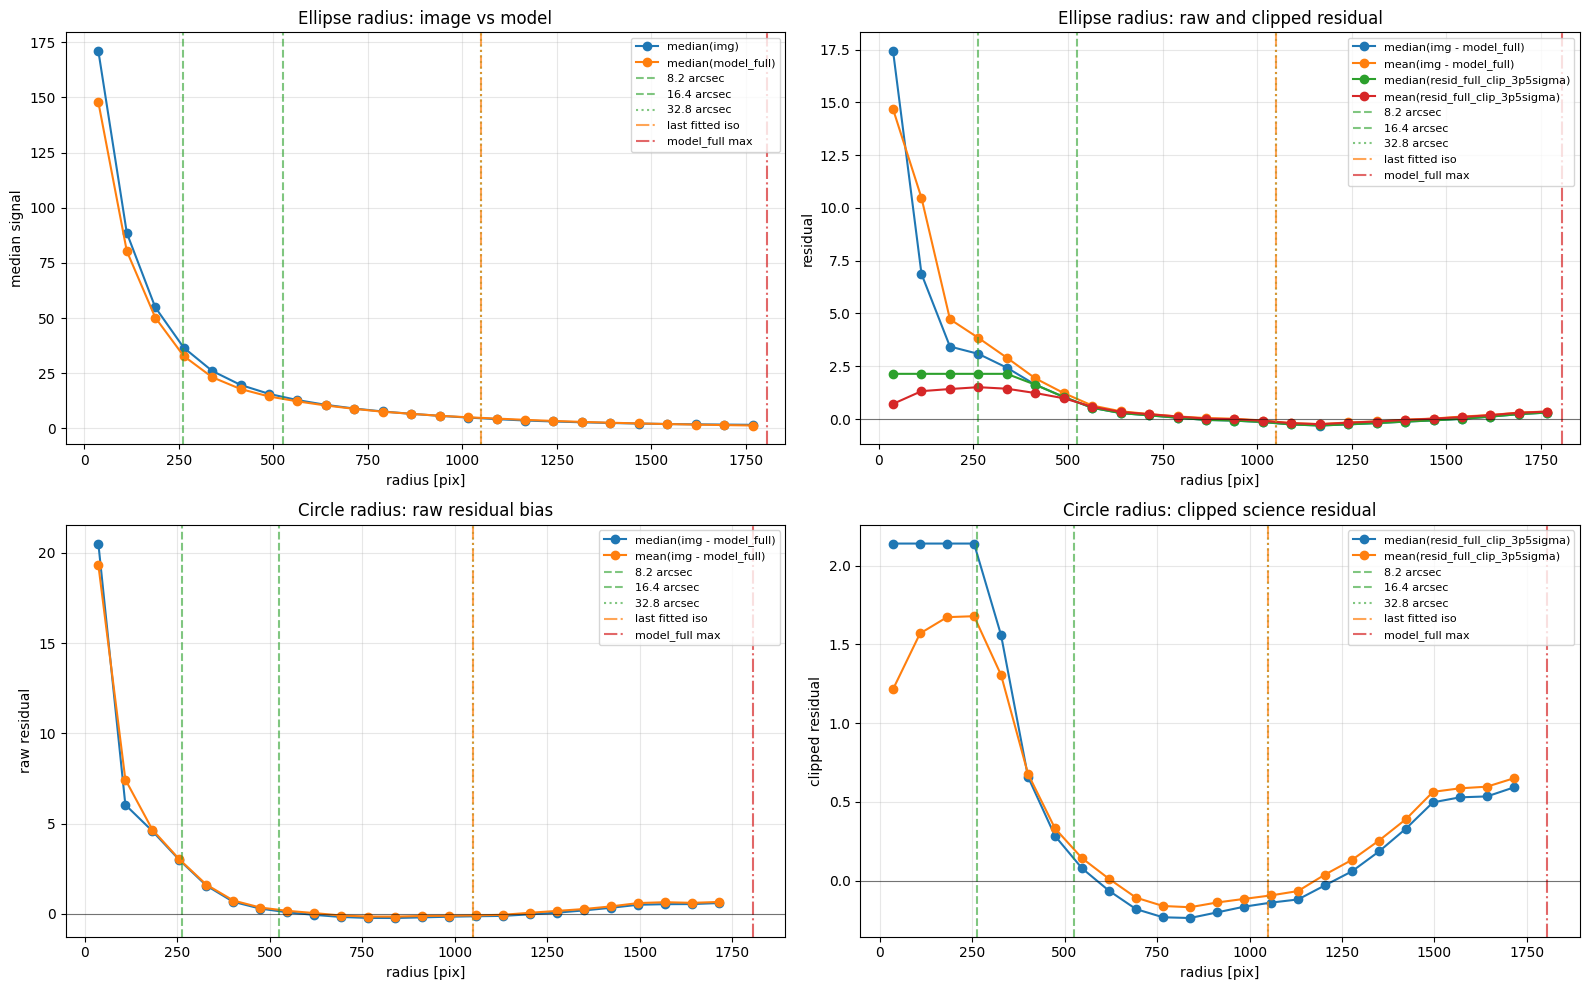

In [46]:
print("building model_full radial-bias diagnostics...")

if "img" not in globals() or "model_full" not in globals():
    raise RuntimeError("[MODEL-BIAS] img/model_full are unavailable")
if "premask" not in globals():
    raise RuntimeError("[MODEL-BIAS] premask is unavailable")

science_model_bias = globals().get("science_model", model_full)
science_model_bias_name = globals().get("science_model_name", "model_full")

if "science_resid" in globals():
    science_resid_bias = science_resid
    science_resid_bias_name = globals().get("science_resid_name", "science_resid")
elif "resid_full_clip" in globals():
    science_resid_bias = resid_full_clip
    if "CLIP_TAG_QC" in globals():
        science_resid_bias_name = f"resid_full_clip_{CLIP_TAG_QC}sigma"
    else:
        science_resid_bias_name = "resid_full_clip"
else:
    raise RuntimeError("[MODEL-BIAS] no clipped science residual is available")

pix_scale_bias = float(globals().get("pix_scale", np.sqrt(pix_area)))


def _optional_finite_float(value, default=np.nan):
    try:
        value = float(value)
    except Exception:
        return float(default)
    return value if np.isfinite(value) else float(default)


x0_bias = _optional_finite_float(
    globals().get("x0_model_full", globals().get("x0_sbf_circ", globals().get("x0_ann", np.nan)))
)
y0_bias = _optional_finite_float(
    globals().get("y0_model_full", globals().get("y0_sbf_circ", globals().get("y0_ann", np.nan)))
)
q_bias = max(
    GEOM_Q_FLOOR,
    _optional_finite_float(globals().get("q_model_full", globals().get("q_ann", np.nan)), GEOM_Q_FLOOR),
)
pa_bias = _optional_finite_float(globals().get("pa_model_full", globals().get("pa_ann", np.nan)), 0.0)

x0_circ_bias = _optional_finite_float(globals().get("x0_sbf_circ", x0_bias))
y0_circ_bias = _optional_finite_float(globals().get("y0_sbf_circ", y0_bias))

if not (np.isfinite(x0_bias) and np.isfinite(y0_bias) and np.isfinite(q_bias) and np.isfinite(pa_bias)):
    raise RuntimeError("[MODEL-BIAS] ellipse geometry is unavailable")
if not (np.isfinite(x0_circ_bias) and np.isfinite(y0_circ_bias)):
    raise RuntimeError("[MODEL-BIAS] circular center is unavailable")

fitted_sma_boundary_px = _optional_finite_float(globals().get("fitted_sma_max_px", np.nan))
model_full_boundary_px = _optional_finite_float(globals().get("sma_model_full_max_px", np.nan))

model_bias_n_bins = int(globals().get("MODEL_BIAS_N_BINS", 24))
model_bias_min_pix = int(globals().get("MODEL_BIAS_MIN_PIX", 200))

model_support_bias = np.isfinite(model_full) & np.isfinite(img) & (model_full > 0.0)
science_use_bias = model_support_bias & (~premask) & np.isfinite(science_resid_bias)

resid_raw_bias = np.asarray(img - model_full, dtype=float)
img_bias = np.asarray(img, dtype=float)
model_bias = np.asarray(model_full, dtype=float)
resid_clip_bias = np.asarray(science_resid_bias, dtype=float)

yy_bias, xx_bias = np.indices(model_full.shape, dtype=float)

dx_ell = xx_bias - x0_bias
dy_ell = yy_bias - y0_bias
cos_ell = np.cos(pa_bias)
sin_ell = np.sin(pa_bias)
xp_ell = dx_ell * cos_ell + dy_ell * sin_ell
yp_ell = -dx_ell * sin_ell + dy_ell * cos_ell
r_ell_bias = np.sqrt(xp_ell * xp_ell + (yp_ell / q_bias) ** 2)

r_circ_bias = np.hypot(xx_bias - x0_circ_bias, yy_bias - y0_circ_bias)

circ_inner_in_px = float(SBF_LIT_INNER_ARCSEC[0] / pix_scale_bias)
circ_inner_out_px = float(SBF_LIT_INNER_ARCSEC[1] / pix_scale_bias)
circ_outer_in_px = float(SBF_LIT_OUTER_ARCSEC[0] / pix_scale_bias)
circ_outer_out_px = float(SBF_LIT_OUTER_ARCSEC[1] / pix_scale_bias)


def build_bias_profile(radius_map, radius_type, r_max):
    edges = np.linspace(0.0, float(r_max), model_bias_n_bins + 1)
    rows = []
    for r_in_px, r_out_px in zip(edges[:-1], edges[1:]):
        bin_mask = science_use_bias & (radius_map >= r_in_px) & (radius_map < r_out_px)
        n_pix = int(bin_mask.sum())
        if n_pix < model_bias_min_pix:
            continue

        vals_img = img_bias[bin_mask]
        vals_model = model_bias[bin_mask]
        vals_raw = resid_raw_bias[bin_mask]
        vals_clip = resid_clip_bias[bin_mask]

        rows.append({
            "radius_type": radius_type,
            "r_in_px": float(r_in_px),
            "r_out_px": float(r_out_px),
            "r_mid_px": float(0.5 * (r_in_px + r_out_px)),
            "r_mid_arcsec": float(0.5 * (r_in_px + r_out_px) * pix_scale_bias),
            "n_pix": n_pix,
            "img_median": float(np.nanmedian(vals_img)),
            "img_mean": float(np.nanmean(vals_img)),
            "img_std": float(np.nanstd(vals_img)),
            "model_median": float(np.nanmedian(vals_model)),
            "model_mean": float(np.nanmean(vals_model)),
            "model_std": float(np.nanstd(vals_model)),
            "resid_raw_median": float(np.nanmedian(vals_raw)),
            "resid_raw_mean": float(np.nanmean(vals_raw)),
            "resid_raw_std": float(np.nanstd(vals_raw)),
            "resid_clip_median": float(np.nanmedian(vals_clip)),
            "resid_clip_mean": float(np.nanmean(vals_clip)),
            "resid_clip_std": float(np.nanstd(vals_clip)),
            "science_resid_name": science_resid_bias_name,
            "science_model_name": science_model_bias_name,
        })
    return rows


r_max_ellipse = float(np.nanpercentile(r_ell_bias[science_use_bias], 99.5))
r_max_circle = float(np.nanpercentile(r_circ_bias[science_use_bias], 99.5))
if np.isfinite(model_full_boundary_px):
    r_max_ellipse = max(r_max_ellipse, float(model_full_boundary_px))
if np.isfinite(circ_outer_out_px):
    r_max_circle = max(r_max_circle, float(circ_outer_out_px))

profile_rows = []
profile_rows.extend(build_bias_profile(r_ell_bias, "ellipse", r_max_ellipse))
profile_rows.extend(build_bias_profile(r_circ_bias, "circle", r_max_circle))

df_model_bias_profile = pd.DataFrame(profile_rows)
display(df_model_bias_profile[[
    "radius_type", "r_in_px", "r_out_px", "r_mid_px", "r_mid_arcsec", "n_pix",
    "img_median", "model_median",
    "resid_raw_median", "resid_raw_mean",
    "resid_clip_median", "resid_clip_mean",
]])

bias_region_masks = {}
if all(name in globals() for name in ["x0_ann", "y0_ann", "q_ann", "pa_ann", "sma_in", "sma_out"]):
    bias_region_masks["elliptical_chosen"] = build_region_mask_ellipse(
        science_resid_bias.shape,
        float(x0_ann), float(y0_ann), max(float(q_ann), GEOM_Q_FLOOR), float(pa_ann),
        float(sma_in), float(sma_out),
    )
bias_region_masks["circular_inner_lit"] = build_region_mask_circle(
    science_resid_bias.shape, x0_circ_bias, y0_circ_bias, circ_inner_in_px, circ_inner_out_px,
)
bias_region_masks["circular_outer_lit"] = build_region_mask_circle(
    science_resid_bias.shape, x0_circ_bias, y0_circ_bias, circ_outer_in_px, circ_outer_out_px,
)


def _sign_label(value):
    if not np.isfinite(value):
        return "nan"
    if value > 0:
        return "positive"
    if value < 0:
        return "negative"
    return "zero"


bias_region_rows = []
for reg_name, reg_mask in bias_region_masks.items():
    reg_use = science_use_bias & np.asarray(reg_mask, dtype=bool)
    n_reg = int(reg_use.sum())
    raw_med = float(np.nanmedian(resid_raw_bias[reg_use])) if n_reg > 0 else np.nan
    raw_mean = float(np.nanmean(resid_raw_bias[reg_use])) if n_reg > 0 else np.nan
    raw_std = float(np.nanstd(resid_raw_bias[reg_use])) if n_reg > 0 else np.nan
    clip_med = float(np.nanmedian(resid_clip_bias[reg_use])) if n_reg > 0 else np.nan
    clip_mean = float(np.nanmean(resid_clip_bias[reg_use])) if n_reg > 0 else np.nan
    clip_std = float(np.nanstd(resid_clip_bias[reg_use])) if n_reg > 0 else np.nan
    bias_region_rows.append({
        "region": reg_name,
        "n_pix": n_reg,
        "resid_raw_median": raw_med,
        "resid_raw_mean": raw_mean,
        "resid_raw_std": raw_std,
        "resid_clip_median": clip_med,
        "resid_clip_mean": clip_mean,
        "resid_clip_std": clip_std,
        "raw_sign": _sign_label(raw_med),
        "clip_sign": _sign_label(clip_med),
    })
    print(
        f"[MODEL-BIAS][REGION] {reg_name}: N={n_reg}, "
        f"raw med={raw_med:.3e}, raw mean={raw_mean:.3e}, raw sign={_sign_label(raw_med)}, "
        f"clip med={clip_med:.3e}, clip mean={clip_mean:.3e}"
    )

df_model_bias_regions = pd.DataFrame(bias_region_rows)
display(df_model_bias_regions)


def _zero_cross_radius(profile_df, value_col):
    work = profile_df[["r_mid_px", "r_mid_arcsec", value_col]].dropna().sort_values("r_mid_px")
    if len(work) < 2:
        return (np.nan, np.nan)
    r_px = work["r_mid_px"].to_numpy(dtype=float)
    r_arc = work["r_mid_arcsec"].to_numpy(dtype=float)
    val = work[value_col].to_numpy(dtype=float)
    for i in range(1, len(val)):
        v0, v1 = val[i - 1], val[i]
        if not (np.isfinite(v0) and np.isfinite(v1)):
            continue
        if v0 == 0.0:
            return (float(r_px[i - 1]), float(r_arc[i - 1]))
        if v0 * v1 < 0.0:
            frac = abs(v0) / max(abs(v1 - v0), ROBUST_SCALE_FLOOR)
            r0_px, r1_px = r_px[i - 1], r_px[i]
            r0_arc, r1_arc = r_arc[i - 1], r_arc[i]
            return (
                float(r0_px + frac * (r1_px - r0_px)),
                float(r0_arc + frac * (r1_arc - r0_arc)),
            )
    return (np.nan, np.nan)


def _first_negative_radius(profile_df, value_col):
    work = profile_df[["r_mid_px", "r_mid_arcsec", value_col]].dropna().sort_values("r_mid_px")
    neg = work[work[value_col] < 0.0]
    if neg.empty:
        return (np.nan, np.nan)
    row = neg.iloc[0]
    return (float(row["r_mid_px"]), float(row["r_mid_arcsec"]))


def _range_note(first_negative_px, fitted_boundary_px):
    if not np.isfinite(first_negative_px):
        return "no negative raw-median bin found"
    if not np.isfinite(fitted_boundary_px):
        return "fitted boundary unavailable"
    if first_negative_px <= fitted_boundary_px:
        return "negative raw-median bias appears already inside fitted isophote range"
    return "negative raw-median bias appears only beyond last fitted isophote"


ellipse_profile = df_model_bias_profile[df_model_bias_profile["radius_type"].eq("ellipse")].copy()
circle_profile = df_model_bias_profile[df_model_bias_profile["radius_type"].eq("circle")].copy()

ellipse_zero_px, ellipse_zero_arc = _zero_cross_radius(ellipse_profile, "resid_raw_median")
circle_zero_px, circle_zero_arc = _zero_cross_radius(circle_profile, "resid_raw_median")
ellipse_first_neg_px, ellipse_first_neg_arc = _first_negative_radius(ellipse_profile, "resid_raw_median")
circle_first_neg_px, circle_first_neg_arc = _first_negative_radius(circle_profile, "resid_raw_median")

inner_raw_med = np.nan
outer_raw_med = np.nan
if not df_model_bias_regions.empty:
    inner_match = df_model_bias_regions[df_model_bias_regions["region"].eq("circular_inner_lit")]
    outer_match = df_model_bias_regions[df_model_bias_regions["region"].eq("circular_outer_lit")]
    if not inner_match.empty:
        inner_raw_med = float(inner_match.iloc[0]["resid_raw_median"])
    if not outer_match.empty:
        outer_raw_med = float(outer_match.iloc[0]["resid_raw_median"])

print(
    f"[MODEL-BIAS][SUMMARY] inner circular raw-median sign = {_sign_label(inner_raw_med)}; "
    f"outer circular raw-median sign = {_sign_label(outer_raw_med)}"
)
if np.isfinite(ellipse_zero_px):
    print(
        f"[MODEL-BIAS][SUMMARY] ellipse raw-median zero-cross at "
        f"r≈{ellipse_zero_px:.1f} px ({ellipse_zero_arc:.2f} arcsec)"
    )
else:
    print("[MODEL-BIAS][SUMMARY] ellipse raw-median zero-cross not found")
if np.isfinite(circle_zero_px):
    print(
        f"[MODEL-BIAS][SUMMARY] circle raw-median zero-cross at "
        f"r≈{circle_zero_px:.1f} px ({circle_zero_arc:.2f} arcsec)"
    )
else:
    print("[MODEL-BIAS][SUMMARY] circle raw-median zero-cross not found")
print(
    f"[MODEL-BIAS][SUMMARY] ellipse onset vs fitted range: "
    f"{_range_note(ellipse_first_neg_px, fitted_sma_boundary_px)}"
)
print(
    f"[MODEL-BIAS][SUMMARY] circle onset vs fitted range: "
    f"{_range_note(circle_first_neg_px, fitted_sma_boundary_px)}"
)


def _add_radius_markers(ax):
    ax.axvline(circ_inner_in_px, color="tab:green", linestyle="--", alpha=0.6, label="8.2 arcsec")
    ax.axvline(circ_inner_out_px, color="tab:green", linestyle="--", alpha=0.6, label="16.4 arcsec")
    ax.axvline(circ_outer_out_px, color="tab:green", linestyle=":", alpha=0.6, label="32.8 arcsec")
    if np.isfinite(fitted_sma_boundary_px):
        ax.axvline(fitted_sma_boundary_px, color="tab:orange", linestyle="-.", alpha=0.7, label="last fitted iso")
    if np.isfinite(model_full_boundary_px):
        ax.axvline(model_full_boundary_px, color="tab:red", linestyle="-.", alpha=0.7, label="model_full max")


fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)

ellipse_sub = ellipse_profile.sort_values("r_mid_px")
circle_sub = circle_profile.sort_values("r_mid_px")

if not ellipse_sub.empty:
    x = ellipse_sub["r_mid_px"].to_numpy(dtype=float)
    ax = axes[0, 0]
    ax.plot(x, ellipse_sub["img_median"], marker="o", label="median(img)")
    ax.plot(x, ellipse_sub["model_median"], marker="o", label="median(model_full)")
    _add_radius_markers(ax)
    ax.set_title("Ellipse radius: image vs model")
    ax.set_xlabel("radius [pix]")
    ax.set_ylabel("median signal")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    ax = axes[0, 1]
    ax.plot(x, ellipse_sub["resid_raw_median"], marker="o", label="median(img - model_full)")
    ax.plot(x, ellipse_sub["resid_raw_mean"], marker="o", label="mean(img - model_full)")
    ax.plot(x, ellipse_sub["resid_clip_median"], marker="o", label=f"median({science_resid_bias_name})")
    ax.plot(x, ellipse_sub["resid_clip_mean"], marker="o", label=f"mean({science_resid_bias_name})")
    _add_radius_markers(ax)
    ax.axhline(0.0, color="k", linewidth=0.8, alpha=0.5)
    ax.set_title("Ellipse radius: raw and clipped residual")
    ax.set_xlabel("radius [pix]")
    ax.set_ylabel("residual")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

if not circle_sub.empty:
    x = circle_sub["r_mid_px"].to_numpy(dtype=float)
    ax = axes[1, 0]
    ax.plot(x, circle_sub["resid_raw_median"], marker="o", label="median(img - model_full)")
    ax.plot(x, circle_sub["resid_raw_mean"], marker="o", label="mean(img - model_full)")
    _add_radius_markers(ax)
    ax.axhline(0.0, color="k", linewidth=0.8, alpha=0.5)
    ax.set_title("Circle radius: raw residual bias")
    ax.set_xlabel("radius [pix]")
    ax.set_ylabel("raw residual")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    ax = axes[1, 1]
    ax.plot(x, circle_sub["resid_clip_median"], marker="o", label=f"median({science_resid_bias_name})")
    ax.plot(x, circle_sub["resid_clip_mean"], marker="o", label=f"mean({science_resid_bias_name})")
    _add_radius_markers(ax)
    ax.axhline(0.0, color="k", linewidth=0.8, alpha=0.5)
    ax.set_title("Circle radius: clipped science residual")
    ax.set_xlabel("radius [pix]")
    ax.set_ylabel("clipped residual")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()



# Model-full vs fitted-model diagnostics

Прямое сравнение исходной fitted isophote model в crop с `model_full` на той же overlap-области.
Это отдельная диагностика: она не меняет scientific path и нужна только чтобы понять,
начинает ли `model_full` расходиться с fitted-model уже внутри надёжного fitted range.

## Overlap-region comparison

Сравниваем `model_c` (или ближайший эквивалент fitted-model из текущего scope) с
`model_full[y1:y2, x1:x2]` и сохраняем диагностические FITS.

## Radial comparison inside fitted range

Профили строятся по эллиптическому радиусу на overlap-области; отдельно отмечается
последняя fitted isophote и, если доступно, внешний радиус `model_full`.



[03:55:35] comparing model_full against fitted crop-model on overlap region...
[03:55:35] [MODEL-OVERLAP] fitted reference = model_c
[03:55:35] [MODEL-OVERLAP] crop bounds = x[3616:9616], y[0:4167], shape=(4167, 6000)
[03:55:35] [MODEL-OVERLAP] fitted_model_crop: finite=2054742, min=4.760e+00, med=8.560e+00, max=3.676e+02
[03:55:35] [MODEL-OVERLAP] model_full_crop: finite=4694476, min=1.206e+00, med=4.147e+00, max=3.691e+02
[03:55:35] [MODEL-OVERLAP] img_crop: finite=17480373, min=-1.596e+00, med=2.331e-01, max=9.165e+02
[03:55:35] [MODEL-OVERLAP] delta_model = model_full_crop - fitted_model_crop: med=-9.779e-02, mean=-9.170e-01, std=3.248e+00, p01=-1.251e+01, p99=2.756e-01
[03:55:36] [OUT] fitted crop-model        -> data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_diag_model_c.fits
[03:55:36] [OUT] model_full crop          -> data/NGC 1380/jw03055-o001_t001_nircam_clear-f150w_i2d_diag_model_full_crop.fits
[03:55:36] [OUT] delta full - fitted      -> data/NGC 1380/jw03055-o001_t

,r_in_px,r_out_px,r_mid_px,r_mid_arcsec,n_pix,model_c_median,model_full_crop_median,delta_model_median,delta_model_mean
0,0.000000,75.204586,37.602293,1.174188,10301,169.612760,143.121384,-13.809268,-11.465625
1,75.204586,150.409172,112.806879,3.522564,32801,87.925261,79.512222,-6.937018,-10.538893
2,150.409172,225.613758,188.011465,5.870941,54653,53.964682,49.447590,-3.556155,-4.573677
3,225.613758,300.818344,263.216051,8.219317,76535,35.987996,32.185268,-3.379769,-3.801499
4,300.818344,376.022930,338.420637,10.567693,98397,25.595743,22.871805,-2.520993,-2.805400
5,376.022930,451.227517,413.625223,12.916070,120265,19.436998,17.586527,-1.627931,-1.856613
6,451.227517,526.432103,488.829810,15.264446,142128,15.363342,14.354839,-0.975395,-1.125973
7,526.432103,601.636689,564.034396,17.612822,163984,12.637670,12.019905,-0.499557,-0.580570
8,601.636689,676.841275,639.238982,19.961198,185836,10.435100,10.208548,-0.310360,-0.355980
9,676.841275,752.045861,714.443568,22.309575,207728,8.858725,8.671227,-0.190683,-0.212776


[03:55:38] [MODEL-OVERLAP][SUMMARY] inside fitted range: sign(model_full - model_c) = negative, median=-9.825e-02, mean=-9.183e-01
[03:55:38] [MODEL-OVERLAP][SUMMARY] model_full - model_c crosses zero near r≈922.9 px (28.82 arcsec)
[03:55:38] [MODEL-OVERLAP][SUMMARY] mismatch is already visible well inside fitted range
[03:55:38] [MODEL-OVERLAP][SUMMARY] mismatch weakens toward outer fitted radii


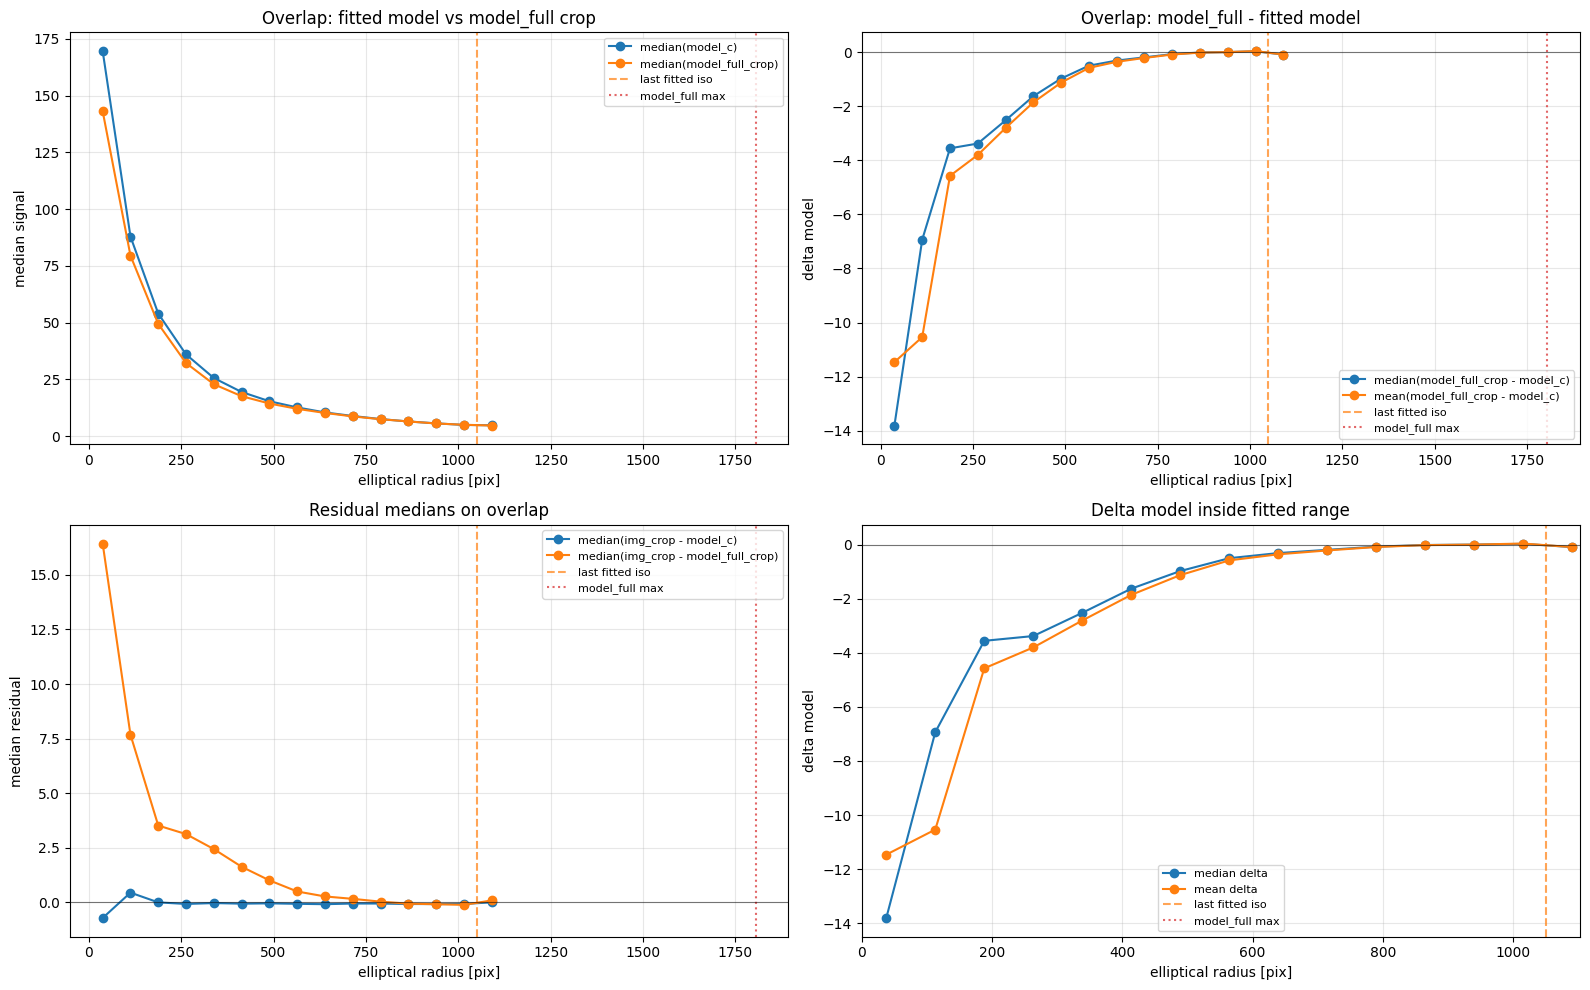

In [47]:
print("comparing model_full against fitted crop-model on overlap region...")

required_crop_names = ["model_full", "img", "x1", "x2", "y1", "y2"]
missing_crop_names = [name for name in required_crop_names if name not in globals()]
if missing_crop_names:
    raise RuntimeError(f"[MODEL-OVERLAP] missing crop variables: {missing_crop_names}")
if "out_dir" not in globals() or "stem" not in globals():
    raise RuntimeError("[MODEL-OVERLAP] out_dir/stem are unavailable")

x1_overlap = int(x1)
x2_overlap = int(x2)
y1_overlap = int(y1)
y2_overlap = int(y2)

model_full_crop = np.asarray(model_full[y1_overlap:y2_overlap, x1_overlap:x2_overlap], dtype=float)
img_crop = np.asarray(img[y1_overlap:y2_overlap, x1_overlap:x2_overlap], dtype=float)

fitted_model_source = None
if "model_c" in globals():
    fitted_model_crop = np.asarray(model_c, dtype=float)
    fitted_model_source = "model_c"
elif "model" in globals():
    fitted_model_crop = np.asarray(model[y1_overlap:y2_overlap, x1_overlap:x2_overlap], dtype=float)
    fitted_model_source = "model[y1:y2, x1:x2]"
else:
    fitted_model_path = out_dir / f"{stem}_sbf_model.fits"
    if not fitted_model_path.exists():
        raise RuntimeError("[MODEL-OVERLAP] no fitted crop-model is available in memory or on disk")
    fitted_model_full = fits.getdata(fitted_model_path).astype(float)
    fitted_model_crop = np.asarray(fitted_model_full[y1_overlap:y2_overlap, x1_overlap:x2_overlap], dtype=float)
    fitted_model_source = f"{fitted_model_path.name}[crop]"

if fitted_model_crop.shape != model_full_crop.shape:
    raise RuntimeError(
        f"[MODEL-OVERLAP] shape mismatch: fitted={fitted_model_crop.shape}, full_crop={model_full_crop.shape}"
    )

ny_overlap, nx_overlap = fitted_model_crop.shape
pix_scale_overlap = float(globals().get("pix_scale", np.sqrt(pix_area)))

x0_prof_full = float(globals().get("x0_ann", globals().get("x0_model_full", np.nan)))
y0_prof_full = float(globals().get("y0_ann", globals().get("y0_model_full", np.nan)))
q_prof = max(
    GEOM_Q_FLOOR,
    float(globals().get("q_ann", globals().get("q_model_full", GEOM_Q_FLOOR))),
)
pa_prof = float(globals().get("pa_ann", globals().get("pa_model_full", 0.0)))

if not (np.isfinite(x0_prof_full) and np.isfinite(y0_prof_full) and np.isfinite(q_prof) and np.isfinite(pa_prof)):
    raise RuntimeError("[MODEL-OVERLAP] profile geometry is unavailable")

x0_prof_crop = x0_prof_full - x1_overlap
y0_prof_crop = y0_prof_full - y1_overlap
fitted_sma_boundary_px = float(globals().get("fitted_sma_max_px", np.nan))
model_full_boundary_px = float(globals().get("sma_model_full_max_px", np.nan))

overlap_mask = np.isfinite(fitted_model_crop) & np.isfinite(model_full_crop)
img_mask_c = np.isfinite(img_crop) & np.isfinite(fitted_model_crop)
img_mask_full = np.isfinite(img_crop) & np.isfinite(model_full_crop)

delta_model = np.full_like(model_full_crop, np.nan, dtype=float)
delta_model[overlap_mask] = model_full_crop[overlap_mask] - fitted_model_crop[overlap_mask]

resid_crop_model_c = np.full_like(img_crop, np.nan, dtype=float)
resid_crop_model_c[img_mask_c] = img_crop[img_mask_c] - fitted_model_crop[img_mask_c]

resid_crop_model_full = np.full_like(img_crop, np.nan, dtype=float)
resid_crop_model_full[img_mask_full] = img_crop[img_mask_full] - model_full_crop[img_mask_full]

print(f"[MODEL-OVERLAP] fitted reference = {fitted_model_source}")
print(f"[MODEL-OVERLAP] crop bounds = x[{x1_overlap}:{x2_overlap}], y[{y1_overlap}:{y2_overlap}], shape={model_full_crop.shape}")


def _print_basic_stats(label, arr):
    finite = np.isfinite(arr)
    n_finite = int(finite.sum())
    if n_finite == 0:
        print(f"[MODEL-OVERLAP] {label}: finite=0")
        return
    vals = arr[finite]
    print(
        f"[MODEL-OVERLAP] {label}: finite={n_finite}, "
        f"min={np.nanmin(vals):.3e}, med={np.nanmedian(vals):.3e}, max={np.nanmax(vals):.3e}"
    )


_print_basic_stats("fitted_model_crop", fitted_model_crop)
_print_basic_stats("model_full_crop", model_full_crop)
_print_basic_stats("img_crop", img_crop)

if int(overlap_mask.sum()) == 0:
    raise RuntimeError("[MODEL-OVERLAP] no finite overlap pixels between fitted model and model_full crop")

delta_vals = delta_model[overlap_mask]
print(
    f"[MODEL-OVERLAP] delta_model = model_full_crop - fitted_model_crop: "
    f"med={np.nanmedian(delta_vals):.3e}, mean={np.nanmean(delta_vals):.3e}, std={np.nanstd(delta_vals):.3e}, "
    f"p01={np.nanpercentile(delta_vals, 1.0):.3e}, p99={np.nanpercentile(delta_vals, 99.0):.3e}"
)


def _build_crop_header(header_full, x0_crop, y0_crop, nx_crop, ny_crop):
    if header_full is None:
        return None
    hdr = header_full.copy()
    for key, val in [("NAXIS1", nx_crop), ("NAXIS2", ny_crop)]:
        try:
            hdr[key] = int(val)
        except Exception:
            pass
    for key, shift in [("CRPIX1", -x0_crop), ("CRPIX2", -y0_crop)]:
        if key in hdr:
            try:
                hdr[key] = float(hdr[key]) + float(shift)
            except Exception:
                pass
    hdr.add_history("Diagnostic crop header for model_full vs fitted-model comparison")
    return hdr


crop_header = _build_crop_header(globals().get("hdr150", None), x1_overlap, y1_overlap, nx_overlap, ny_overlap)
model_c_diag_path = out_dir / f"{stem}_diag_model_c.fits"
model_full_crop_diag_path = out_dir / f"{stem}_diag_model_full_crop.fits"
delta_model_diag_path = out_dir / f"{stem}_diag_model_delta_full_minus_c.fits"
img_crop_diag_path = out_dir / f"{stem}_diag_img_crop.fits"
resid_crop_c_diag_path = out_dir / f"{stem}_diag_resid_crop_minus_model_c.fits"
resid_crop_full_diag_path = out_dir / f"{stem}_diag_resid_crop_minus_model_full_crop.fits"

fits.writeto(model_c_diag_path, np.asarray(fitted_model_crop, dtype=np.float32), crop_header, overwrite=True)
fits.writeto(model_full_crop_diag_path, np.asarray(model_full_crop, dtype=np.float32), crop_header, overwrite=True)
fits.writeto(delta_model_diag_path, np.asarray(delta_model, dtype=np.float32), crop_header, overwrite=True)
fits.writeto(img_crop_diag_path, np.asarray(img_crop, dtype=np.float32), crop_header, overwrite=True)
fits.writeto(resid_crop_c_diag_path, np.asarray(resid_crop_model_c, dtype=np.float32), crop_header, overwrite=True)
fits.writeto(resid_crop_full_diag_path, np.asarray(resid_crop_model_full, dtype=np.float32), crop_header, overwrite=True)

print(f"[OUT] fitted crop-model        -> {model_c_diag_path}")
print(f"[OUT] model_full crop          -> {model_full_crop_diag_path}")
print(f"[OUT] delta full - fitted      -> {delta_model_diag_path}")
print(f"[OUT] img crop                 -> {img_crop_diag_path}")
print(f"[OUT] resid crop - model_c     -> {resid_crop_c_diag_path}")
print(f"[OUT] resid crop - model_full  -> {resid_crop_full_diag_path}")

yy_overlap, xx_overlap = np.indices(model_full_crop.shape, dtype=float)
dx_prof = xx_overlap - x0_prof_crop
dy_prof = yy_overlap - y0_prof_crop
cos_prof = np.cos(pa_prof)
sin_prof = np.sin(pa_prof)
xp_prof = dx_prof * cos_prof + dy_prof * sin_prof
yp_prof = -dx_prof * sin_prof + dy_prof * cos_prof
r_ell_overlap = np.sqrt(xp_prof * xp_prof + (yp_prof / q_prof) ** 2)

profile_mask = overlap_mask
model_overlap_n_bins = int(globals().get("MODEL_OVERLAP_N_BINS", 24))
model_overlap_min_pix = int(globals().get("MODEL_OVERLAP_MIN_PIX", 100))

r_max_overlap = float(np.nanpercentile(r_ell_overlap[profile_mask], 99.5))
if np.isfinite(fitted_sma_boundary_px):
    r_max_overlap = max(r_max_overlap, fitted_sma_boundary_px)
if np.isfinite(model_full_boundary_px):
    r_max_overlap = max(r_max_overlap, model_full_boundary_px)

profile_rows = []
edges = np.linspace(0.0, r_max_overlap, model_overlap_n_bins + 1)
for r_in_px, r_out_px in zip(edges[:-1], edges[1:]):
    bin_mask = profile_mask & (r_ell_overlap >= r_in_px) & (r_ell_overlap < r_out_px)
    n_pix = int(bin_mask.sum())
    if n_pix < model_overlap_min_pix:
        continue

    delta_bin = delta_model[bin_mask]
    resid_c_bin = resid_crop_model_c[bin_mask & np.isfinite(resid_crop_model_c)]
    resid_full_bin = resid_crop_model_full[bin_mask & np.isfinite(resid_crop_model_full)]

    profile_rows.append({
        "r_in_px": float(r_in_px),
        "r_out_px": float(r_out_px),
        "r_mid_px": float(0.5 * (r_in_px + r_out_px)),
        "r_mid_arcsec": float(0.5 * (r_in_px + r_out_px) * pix_scale_overlap),
        "n_pix": n_pix,
        "model_c_median": float(np.nanmedian(fitted_model_crop[bin_mask])),
        "model_full_crop_median": float(np.nanmedian(model_full_crop[bin_mask])),
        "delta_model_median": float(np.nanmedian(delta_bin)),
        "delta_model_mean": float(np.nanmean(delta_bin)),
        "delta_model_std": float(np.nanstd(delta_bin)),
        "resid_model_c_median": float(np.nanmedian(resid_c_bin)) if resid_c_bin.size > 0 else np.nan,
        "resid_model_c_mean": float(np.nanmean(resid_c_bin)) if resid_c_bin.size > 0 else np.nan,
        "resid_model_full_median": float(np.nanmedian(resid_full_bin)) if resid_full_bin.size > 0 else np.nan,
        "resid_model_full_mean": float(np.nanmean(resid_full_bin)) if resid_full_bin.size > 0 else np.nan,
    })

df_model_overlap_profile = pd.DataFrame(profile_rows)
display(df_model_overlap_profile[[
    "r_in_px", "r_out_px", "r_mid_px", "r_mid_arcsec", "n_pix",
    "model_c_median", "model_full_crop_median",
    "delta_model_median", "delta_model_mean",
]])


def _sign_label(value):
    if not np.isfinite(value):
        return "nan"
    if value > 0:
        return "positive"
    if value < 0:
        return "negative"
    return "zero"


def _zero_cross_radius(profile_df, value_col):
    work = profile_df[["r_mid_px", "r_mid_arcsec", value_col]].dropna().sort_values("r_mid_px")
    if len(work) < 2:
        return (np.nan, np.nan)
    r_px = work["r_mid_px"].to_numpy(dtype=float)
    r_arc = work["r_mid_arcsec"].to_numpy(dtype=float)
    val = work[value_col].to_numpy(dtype=float)
    for i in range(1, len(val)):
        v0, v1 = val[i - 1], val[i]
        if v0 == 0.0:
            return (float(r_px[i - 1]), float(r_arc[i - 1]))
        if np.isfinite(v0) and np.isfinite(v1) and (v0 * v1 < 0.0):
            frac = abs(v0) / max(abs(v1 - v0), ROBUST_SCALE_FLOOR)
            return (
                float(r_px[i - 1] + frac * (r_px[i] - r_px[i - 1])),
                float(r_arc[i - 1] + frac * (r_arc[i] - r_arc[i - 1])),
            )
    return (np.nan, np.nan)


inside_fitted_mask = overlap_mask.copy()
if np.isfinite(fitted_sma_boundary_px):
    inside_fitted_mask &= (r_ell_overlap <= fitted_sma_boundary_px)

delta_inside = delta_model[inside_fitted_mask]
inside_med = float(np.nanmedian(delta_inside)) if delta_inside.size > 0 else np.nan
inside_mean = float(np.nanmean(delta_inside)) if delta_inside.size > 0 else np.nan
inside_sign = _sign_label(inside_med)

profile_inside = df_model_overlap_profile.copy()
if np.isfinite(fitted_sma_boundary_px):
    profile_inside = profile_inside[profile_inside["r_mid_px"] <= fitted_sma_boundary_px].copy()
zero_px, zero_arc = _zero_cross_radius(profile_inside, "delta_model_median")

inner_half = profile_inside[profile_inside["r_mid_px"] <= 0.5 * fitted_sma_boundary_px] if np.isfinite(fitted_sma_boundary_px) else profile_inside.head(max(len(profile_inside) // 2, 1))
outer_third = profile_inside[profile_inside["r_mid_px"] >= (2.0 / 3.0) * fitted_sma_boundary_px] if np.isfinite(fitted_sma_boundary_px) else profile_inside.tail(max(len(profile_inside) // 3, 1))
inner_abs = float(np.nanmedian(np.abs(inner_half["delta_model_median"]))) if not inner_half.empty else np.nan
outer_abs = float(np.nanmedian(np.abs(outer_third["delta_model_median"]))) if not outer_third.empty else np.nan
model_scale_inside = float(np.nanmedian(profile_inside["model_c_median"])) if not profile_inside.empty else np.nan

if np.isfinite(inner_abs) and np.isfinite(model_scale_inside) and (inner_abs > 0.01 * max(model_scale_inside, ROBUST_SCALE_FLOOR)):
    inside_note = "mismatch is already visible well inside fitted range"
else:
    inside_note = "mismatch is small in the inner fitted range"

if np.isfinite(inner_abs) and np.isfinite(outer_abs):
    if outer_abs > 1.25 * max(inner_abs, ROBUST_SCALE_FLOOR):
        growth_note = "mismatch grows toward outer fitted radii"
    elif outer_abs < 0.80 * max(inner_abs, ROBUST_SCALE_FLOOR):
        growth_note = "mismatch weakens toward outer fitted radii"
    else:
        growth_note = "mismatch amplitude stays comparable across fitted radii"
else:
    growth_note = "could not determine radial growth of mismatch"

print(
    f"[MODEL-OVERLAP][SUMMARY] inside fitted range: sign(model_full - model_c) = {inside_sign}, "
    f"median={inside_med:.3e}, mean={inside_mean:.3e}"
)
if np.isfinite(zero_px):
    print(
        f"[MODEL-OVERLAP][SUMMARY] model_full - model_c crosses zero near "
        f"r≈{zero_px:.1f} px ({zero_arc:.2f} arcsec)"
    )
else:
    print("[MODEL-OVERLAP][SUMMARY] no zero-cross found inside fitted range")
print(f"[MODEL-OVERLAP][SUMMARY] {inside_note}")
print(f"[MODEL-OVERLAP][SUMMARY] {growth_note}")


def _add_overlap_markers(ax):
    if np.isfinite(fitted_sma_boundary_px):
        ax.axvline(fitted_sma_boundary_px, color="tab:orange", linestyle="--", alpha=0.7, label="last fitted iso")
    if np.isfinite(model_full_boundary_px):
        ax.axvline(model_full_boundary_px, color="tab:red", linestyle=":", alpha=0.7, label="model_full max")


fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
prof = df_model_overlap_profile.sort_values("r_mid_px")
if not prof.empty:
    x = prof["r_mid_px"].to_numpy(dtype=float)

    ax = axes[0, 0]
    ax.plot(x, prof["model_c_median"], marker="o", label="median(model_c)")
    ax.plot(x, prof["model_full_crop_median"], marker="o", label="median(model_full_crop)")
    _add_overlap_markers(ax)
    ax.set_title("Overlap: fitted model vs model_full crop")
    ax.set_xlabel("elliptical radius [pix]")
    ax.set_ylabel("median signal")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    ax = axes[0, 1]
    ax.plot(x, prof["delta_model_median"], marker="o", label="median(model_full_crop - model_c)")
    ax.plot(x, prof["delta_model_mean"], marker="o", label="mean(model_full_crop - model_c)")
    _add_overlap_markers(ax)
    ax.axhline(0.0, color="k", linewidth=0.8, alpha=0.5)
    ax.set_title("Overlap: model_full - fitted model")
    ax.set_xlabel("elliptical radius [pix]")
    ax.set_ylabel("delta model")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    ax = axes[1, 0]
    ax.plot(x, prof["resid_model_c_median"], marker="o", label="median(img_crop - model_c)")
    ax.plot(x, prof["resid_model_full_median"], marker="o", label="median(img_crop - model_full_crop)")
    _add_overlap_markers(ax)
    ax.axhline(0.0, color="k", linewidth=0.8, alpha=0.5)
    ax.set_title("Residual medians on overlap")
    ax.set_xlabel("elliptical radius [pix]")
    ax.set_ylabel("median residual")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    ax = axes[1, 1]
    ax.plot(x, prof["delta_model_median"], marker="o", label="median delta")
    ax.plot(x, prof["delta_model_mean"], marker="o", label="mean delta")
    _add_overlap_markers(ax)
    ax.axhline(0.0, color="k", linewidth=0.8, alpha=0.5)
    if np.isfinite(fitted_sma_boundary_px):
        ax.set_xlim(0.0, 1.05 * fitted_sma_boundary_px)
    ax.set_title("Delta model inside fitted range")
    ax.set_xlabel("elliptical radius [pix]")
    ax.set_ylabel("delta model")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()



In [48]:
def measure_sbf_for_mask(
    region_mask,
    resid,
    model,
    premask,
    psf,
    pix_area,
    kmin,
    kmax,
    fft_workers=None,
    n_e_realizations=None,
    kbins_n=None,
    region_name="region",
    region_role="science",
    region_origin_x=0,
    region_origin_y=0,
):
    return measure_sbf_spectral_region(
        region_mask=region_mask,
        resid=resid,
        model=model,
        premask=premask,
        psf=psf,
        pix_area=pix_area,
        kmin=kmin,
        kmax=kmax,
        fft_workers=fft_workers,
        n_e_realizations=n_e_realizations,
        kbins_n=kbins_n,
        region_name=region_name,
        region_role=region_role,
        region_origin_x=region_origin_x,
        region_origin_y=region_origin_y,
    )


In [49]:
print("measuring SBF in Jensen/TRGB-SBF circular annuli plus elliptical diagnostic...")

if "science_model" not in globals() or "science_resid" not in globals():
    raise RuntimeError("[SBF-REGION] unified science path is unavailable; rerun the science-path cell")

pix_scale = float(np.sqrt(pix_area))   # arcsec/pix
r1_in, r1_out = SBF_LIT_INNER_ARCSEC[0] / pix_scale, SBF_LIT_INNER_ARCSEC[1] / pix_scale
r2_in, r2_out = SBF_LIT_OUTER_ARCSEC[0] / pix_scale, SBF_LIT_OUTER_ARCSEC[1] / pix_scale

print(
    f"[SBF-REGION] unified science path: residual={science_resid_name}, model={science_model_name}; "
    "elliptical_chosen remains a geometric diagnostic but uses the same residual/model pair"
)
print(
    f"[SBF-REGION] circular center = ({x0_sbf_circ:.2f}, {y0_sbf_circ:.2f}), "
    f"radii = {r1_in:.1f}-{r1_out:.1f} px and {r2_in:.1f}-{r2_out:.1f} px"
)

regions = [
    {
        "region": "elliptical_chosen",
        "role": "diagnostic",
        "shape": "ellipse",
        "mask": build_region_mask_ellipse(
            science_resid.shape, x0_ann, y0_ann, q_ann, pa_ann, sma_in, sma_out
        ),
        "rin_px": sma_in,
        "rout_px": sma_out,
        "rin_arcsec": float(sma_in * pix_scale),
        "rout_arcsec": float(sma_out * pix_scale),
        "resid_data": science_resid,
        "model_data": science_model,
        "resid_source": science_resid_name,
        "model_source": science_model_name,
        "origin_x": 0,
        "origin_y": 0,
    },
    {
        "region": "circular_inner_lit",
        "role": "science",
        "shape": "circle",
        "mask": build_region_mask_circle(
            science_resid.shape, x0_sbf_circ, y0_sbf_circ, r1_in, r1_out
        ),
        "rin_px": r1_in,
        "rout_px": r1_out,
        "rin_arcsec": SBF_LIT_INNER_ARCSEC[0],
        "rout_arcsec": SBF_LIT_INNER_ARCSEC[1],
        "resid_data": science_resid,
        "model_data": science_model,
        "resid_source": science_resid_name,
        "model_source": science_model_name,
        "origin_x": 0,
        "origin_y": 0,
    },
    {
        "region": "circular_outer_lit",
        "role": "science",
        "shape": "circle",
        "mask": build_region_mask_circle(
            science_resid.shape, x0_sbf_circ, y0_sbf_circ, r2_in, r2_out
        ),
        "rin_px": r2_in,
        "rout_px": r2_out,
        "rin_arcsec": SBF_LIT_OUTER_ARCSEC[0],
        "rout_arcsec": SBF_LIT_OUTER_ARCSEC[1],
        "resid_data": science_resid,
        "model_data": science_model,
        "resid_source": science_resid_name,
        "model_source": science_model_name,
        "origin_x": 0,
        "origin_y": 0,
    },
]

k_windows = list(SBF_REGION_K_WINDOWS)
rows_df = []

for reg in regions:
    region_mask = reg["mask"]
    reg_resid = reg["resid_data"]
    reg_model = reg["model_data"]
    region_pixels = int(region_mask.sum())
    usable_region = region_mask & (~premask) & np.isfinite(reg_resid) & np.isfinite(reg_model) & (reg_model > 0.0)
    usable_pixels = int(usable_region.sum())
    usable_fraction = float(usable_pixels / region_pixels) if region_pixels > 0 else np.nan

    print(
        f"[SBF-REGION] {reg['region']} ({reg['role']}): "
        f"N_region={region_pixels}, N_usable={usable_pixels}, "
        f"usable_fraction={usable_fraction:.3f}, residual={reg['resid_source']}, model={reg['model_source']}"
    )
    src_reg_summary = summarize_sources_in_region_mask(
        region_mask,
        region_origin_x=reg['origin_x'],
        region_origin_y=reg['origin_y'],
    )
    print(
        f"[SRC-CAT-REGION] {reg['region']}: overlap={src_reg_summary['n_overlap']}, "
        f"valid={src_reg_summary['n_valid']}, nonpositive_flux={src_reg_summary['n_nonpositive_flux']}, "
        f"mag_med={src_reg_summary['mag_med']:.3f}"
    )

    for kmin, kmax in k_windows:
        out = measure_sbf_for_mask(
            region_mask=region_mask,
            resid=reg_resid,
            model=reg_model,
            premask=premask,
            psf=psf,
            pix_area=pix_area,
            kmin=kmin,
            kmax=kmax,
            fft_workers=FFT_WORKERS,
            n_e_realizations=FFT_E_REALIZATIONS_DIAG,
            kbins_n=FFT_KBINS_N,
            region_name=reg["region"],
            region_role=reg["role"],
            region_origin_x=reg["origin_x"],
            region_origin_y=reg["origin_y"],
        )

        base_row = {
            "region": reg["region"],
            "role": reg["role"],
            "shape": reg["shape"],
            "rin_px": reg["rin_px"],
            "rout_px": reg["rout_px"],
            "rin_arcsec": reg["rin_arcsec"],
            "rout_arcsec": reg["rout_arcsec"],
            "resid_source": reg["resid_source"],
            "model_source": reg["model_source"],
            "region_pixels": region_pixels,
            "usable_pixels": usable_pixels,
            "usable_fraction": usable_fraction,
            "kmin": kmin,
            "kmax": kmax,
        }

        if out is None:
            rows_df.append({**base_row, "status": "failed_raw"})
            print(f"[SBF-REGION]   k={kmin:.3f}..{kmax:.3f} -> raw spectral fit failed")
            continue

        status = "ok" if out.get("measurement_ok", False) else "invalid_corrected"
        rows_df.append({**base_row, "status": status, **out})

        if status == "ok":
            corr_text = f"{out['Pr_over_P0']:.3%}" if np.isfinite(out.get("Pr_over_P0", np.nan)) else "n/a"
            print(
                f"[SBF-REGION]   k={kmin:.3f}..{kmax:.3f}: raw mbar={out['mbar_spec_raw']:.4f}, "
                f"corrected mbar={out['mbar_spec']:.4f}, P0={out['P0']:.3e}, Pr={out['Pr']:.3e}, "
                f"P_fluc={out['P_fluc']:.3e}, Pr/P0={corr_text}, "
                f"Nsrc_valid={out['n_detected_sources']}, Nsrc_overlap={out.get('n_detected_sources_total', 0)}, "
                f"m_lim={out['m_lim']:.3f}, gamma={out['lf_gamma']:.3f}"
            )
        else:
            print(
                f"[SBF-REGION]   k={kmin:.3f}..{kmax:.3f}: raw mbar={out['mbar_spec_raw']:.4f}, "
                f"corrected measurement invalid ({out.get('failure_reason', '')}), "
                f"P0={out['P0']:.3e}, Pr={out['Pr']:.3e}, P_fluc={out['P_fluc']:.3e}"
            )


[03:55:39] measuring SBF in Jensen/TRGB-SBF circular annuli plus elliptical diagnostic...
[03:55:39] [SBF-REGION] unified science path: residual=resid_full_clip_3p5sigma, model=model_full; elliptical_chosen remains a geometric diagnostic but uses the same residual/model pair
[03:55:39] [SBF-REGION] circular center = (6608.14, 1168.18), radii = 262.6-525.2 px and 525.2-1050.4 px
[03:55:40] [SBF-REGION] elliptical_chosen (diagnostic): N_region=204356, N_usable=204356, usable_fraction=1.000, residual=resid_full_clip_3p5sigma, model=model_full
[03:55:40] [SRC-CAT-REGION] elliptical_chosen: overlap=856, valid=856, nonpositive_flux=0, mag_med=25.459
[03:56:57] [SBF-REGION]   k=0.020..0.350: raw mbar=27.1407, corrected mbar=27.1544, P0=1.750e+01, Pr=2.205e-01, P_fluc=1.727e+01, Pr/P0=1.260%, Nsrc_valid=856, Nsrc_overlap=856, m_lim=25.875, gamma=0.406
[03:58:16] [SBF-REGION]   k=0.030..0.400: raw mbar=27.0976, corrected mbar=27.1109, P0=1.820e+01, Pr=2.205e-01, P_fluc=1.798e+01, Pr/P0=1.211%, 

In [50]:

df_sbf = pd.DataFrame(rows_df)
display(df_sbf)

,region,role,shape,rin_px,rout_px,rin_arcsec,rout_arcsec,resid_source,model_source,region_pixels,...,lf_model,lf_gamma,lf_phi_mlim,lf_fit_method,lf_fit_rmse,lf_n_fit_bins,lf_n_fit_sources,lf_fit_mbright,lf_fit_mfaint,pr_note
0,elliptical_chosen,diagnostic,ellipse,720.000000,790.000000,22.483083,24.668938,resid_full_clip_3p5sigma,model_full,204356,...,combined_power_law,0.405973,0.003995,local_histogram,0.064668,6,652,24.375,25.875,local combined contaminant LF
1,elliptical_chosen,diagnostic,ellipse,720.000000,790.000000,22.483083,24.668938,resid_full_clip_3p5sigma,model_full,204356,...,combined_power_law,0.405973,0.003995,local_histogram,0.064668,6,652,24.375,25.875,local combined contaminant LF
2,elliptical_chosen,diagnostic,ellipse,720.000000,790.000000,22.483083,24.668938,resid_full_clip_3p5sigma,model_full,204356,...,combined_power_law,0.405973,0.003995,local_histogram,0.064668,6,652,24.375,25.875,local combined contaminant LF
3,circular_inner_lit,science,circle,262.597443,525.194886,8.200000,16.400000,resid_full_clip_3p5sigma,model_full,649915,...,combined_power_law,0.327680,0.005882,local_window_norm_fixed_gamma,NaN,6,3433,24.375,25.875,local combined contaminant LF
4,circular_inner_lit,science,circle,262.597443,525.194886,8.200000,16.400000,resid_full_clip_3p5sigma,model_full,649915,...,combined_power_law,0.327680,0.005882,local_window_norm_fixed_gamma,NaN,6,3433,24.375,25.875,local combined contaminant LF
5,circular_inner_lit,science,circle,262.597443,525.194886,8.200000,16.400000,resid_full_clip_3p5sigma,model_full,649915,...,combined_power_law,0.327680,0.005882,local_window_norm_fixed_gamma,NaN,6,3433,24.375,25.875,local combined contaminant LF
6,circular_outer_lit,science,circle,525.194886,1050.389772,16.400000,32.800000,resid_full_clip_3p5sigma,model_full,2599673,...,combined_power_law,0.558066,0.001330,local_histogram,0.040604,6,2249,24.375,25.875,local combined contaminant LF
7,circular_outer_lit,science,circle,525.194886,1050.389772,16.400000,32.800000,resid_full_clip_3p5sigma,model_full,2599673,...,combined_power_law,0.558066,0.001330,local_histogram,0.040604,6,2249,24.375,25.875,local combined contaminant LF
8,circular_outer_lit,science,circle,525.194886,1050.389772,16.400000,32.800000,resid_full_clip_3p5sigma,model_full,2599673,...,combined_power_law,0.558066,0.001330,local_histogram,0.040604,6,2249,24.375,25.875,local combined contaminant LF


## Raw vs corrected spectral SBF

Эта таблица нужна именно для sanity-check correction: видно raw `P0`-based результат, оценку `Pr` и corrected `P_fluc`/`mbar_spec` по каждому региону и каждому `k`-окну.


In [51]:
compare_columns = [
    "region", "role", "status", "kmin", "kmax",
    "mbar_spec_raw", "mbar_spec",
    "P0", "Pr", "P_fluc", "Pr_over_P0",
    "Imean", "n_detected_sources", "m_lim", "lf_gamma", "lf_fit_method",
]

compare_columns = [col for col in compare_columns if col in df_sbf.columns]
df_sbf_compare = df_sbf[compare_columns].copy()
display(df_sbf_compare.sort_values(["region", "kmin", "kmax"]).reset_index(drop=True))


,region,role,status,kmin,kmax,mbar_spec_raw,mbar_spec,P0,Pr,P_fluc,Pr_over_P0,Imean,n_detected_sources,m_lim,lf_gamma,lf_fit_method
0,circular_inner_lit,science,ok,0.02,0.35,27.346339,27.358143,25.051552,0.270868,24.780684,0.010812,13.725893,5265,25.875,0.327680,local_window_norm_fixed_gamma
1,circular_inner_lit,science,ok,0.03,0.40,27.332143,27.343792,25.381264,0.270868,25.110396,0.010672,13.725893,5265,25.875,0.327680,local_window_norm_fixed_gamma
2,circular_inner_lit,science,ok,0.04,0.35,27.289701,27.300902,26.393066,0.270868,26.122198,0.010263,13.725893,5265,25.875,0.327680,local_window_norm_fixed_gamma
3,circular_outer_lit,science,ok,0.02,0.35,27.152542,27.164776,10.673591,0.119596,10.553995,0.011205,4.892125,3004,25.875,0.558066,local_histogram
4,circular_outer_lit,science,ok,0.03,0.40,27.018937,27.029747,12.071259,0.119596,11.951664,0.009907,4.892125,3004,25.875,0.558066,local_histogram
5,circular_outer_lit,science,ok,0.04,0.35,26.935598,26.945606,13.034309,0.119596,12.914713,0.009175,4.892125,3004,25.875,0.558066,local_histogram
6,elliptical_chosen,diagnostic,ok,0.02,0.35,27.140651,27.154421,17.495239,0.220486,17.274753,0.012603,7.931408,856,25.875,0.405973,local_histogram
7,elliptical_chosen,diagnostic,ok,0.03,0.40,27.097633,27.110865,18.202329,0.220486,17.981842,0.012113,7.931408,856,25.875,0.405973,local_histogram
8,elliptical_chosen,diagnostic,ok,0.04,0.35,26.984273,26.996186,20.205561,0.220486,19.985074,0.010912,7.931408,856,25.875,0.405973,local_histogram


## Main SBF result from fixed circular annuli

Основной science result теперь строится по двум фиксированным круговым annuli 8.2-16.4" и 16.4-32.8". `elliptical_chosen` остаётся только diagnostic/comparison.


In [52]:
print("combining fixed circular SBF annuli with weighted mean (main science result)...")

required_annuli = ["circular_inner_lit", "circular_outer_lit"]
df_sbf_ok = df_sbf[df_sbf["status"].eq("ok")].copy()


def _finite_positive(value):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return False
    return np.isfinite(value) and value > 0.0


def _robust_mag_scatter(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]

    if arr.size >= 3:
        med = float(np.nanmedian(arr))
        mad_sigma = float(1.4826 * np.nanmedian(np.abs(arr - med)))
        std_sigma = float(np.nanstd(arr, ddof=1))
        if _finite_positive(mad_sigma):
            return mad_sigma, "k-window MAD"
        if _finite_positive(std_sigma):
            return std_sigma, "k-window std"

    if arr.size >= 2:
        std_sigma = float(np.nanstd(arr, ddof=1))
        half_range = float(0.5 * (np.nanmax(arr) - np.nanmin(arr)))
        if _finite_positive(std_sigma):
            return std_sigma, "k-window std"
        if _finite_positive(half_range):
            return half_range, "k-window half-range"

    return np.nan, "no k-window scatter"


region_sigma_info = {}
for region_name, grp in df_sbf_ok.groupby("region"):
    sigma_k, sigma_method = _robust_mag_scatter(grp["mbar_spec"].values)
    region_sigma_info[region_name] = {
        "sigma_kwindow": sigma_k,
        "sigma_method": sigma_method,
    }


def _fit_resid_proxy_mag(row):
    fit_resid_std = row.get("fit_resid_std", np.nan)
    power_ref = row.get("P_fluc", np.nan)
    if not _finite_positive(power_ref):
        power_ref = row.get("P0", np.nan)
    if _finite_positive(fit_resid_std) and _finite_positive(abs(power_ref)):
        return float((2.5 / np.log(10.0)) * fit_resid_std / abs(power_ref))
    return np.nan


def _measurement_sigma_for_row(row):
    candidates = []
    info = region_sigma_info.get(row["region"], {})

    sigma_k = info.get("sigma_kwindow", np.nan)
    if _finite_positive(sigma_k):
        candidates.append((float(sigma_k), info.get("sigma_method", "k-window scatter")))

    sigma_fit = row.get("mbar_fit_sigma", np.nan)
    if _finite_positive(sigma_fit):
        candidates.append((float(sigma_fit), "fit covariance"))

    if candidates:
        sigma, method = max(candidates, key=lambda item: item[0])
        if len(candidates) > 1:
            method = "max(" + ", ".join(m for _, m in candidates) + ")"
        return sigma, method

    sigma_proxy = _fit_resid_proxy_mag(row)
    if _finite_positive(sigma_proxy):
        return sigma_proxy, "fit_resid_std/P_fluc proxy"

    return np.nan, "sigma unavailable"


def _row_for(region_name, kmin_value, kmax_value):
    if df_sbf_ok.empty:
        return None
    match = df_sbf_ok[
        df_sbf_ok["region"].eq(region_name)
        & np.isclose(df_sbf_ok["kmin"].astype(float), float(kmin_value))
        & np.isclose(df_sbf_ok["kmax"].astype(float), float(kmax_value))
    ]
    if match.empty:
        return None
    return match.iloc[0]


def _annulus_measurement(region_name, kmin_value, kmax_value):
    row = _row_for(region_name, kmin_value, kmax_value)
    if row is None:
        return np.nan, np.nan, "not ok", None

    mbar = float(row["mbar_spec"]) if np.isfinite(row.get("mbar_spec", np.nan)) else np.nan
    sigma, sigma_method = _measurement_sigma_for_row(row)
    return mbar, sigma, sigma_method, row


pairs_from_df = df_sbf[df_sbf["region"].isin(required_annuli)][["kmin", "kmax"]].dropna().drop_duplicates()
k_pairs = sorted({(float(r.kmin), float(r.kmax)) for r in pairs_from_df.itertuples(index=False)})

sigma_pipeline = globals().get("sigma_pipeline", np.nan)
summary_rows = []
for kmin_value, kmax_value in k_pairs:
    mbar_inner, sigma_inner, method_inner, row_inner = _annulus_measurement(
        "circular_inner_lit", kmin_value, kmax_value
    )
    mbar_outer, sigma_outer, method_outer, row_outer = _annulus_measurement(
        "circular_outer_lit", kmin_value, kmax_value
    )

    mbar_inner_raw = float(row_inner["mbar_spec_raw"]) if row_inner is not None and np.isfinite(row_inner.get("mbar_spec_raw", np.nan)) else np.nan
    mbar_outer_raw = float(row_outer["mbar_spec_raw"]) if row_outer is not None and np.isfinite(row_outer.get("mbar_spec_raw", np.nan)) else np.nan
    inner_ok = np.isfinite(mbar_inner) and _finite_positive(sigma_inner)
    outer_ok = np.isfinite(mbar_outer) and _finite_positive(sigma_outer)
    both_measured = np.isfinite(mbar_inner) and np.isfinite(mbar_outer)

    mbar_weighted = np.nan
    mbar_weighted_raw = np.nan
    sigma_weighted_formal = np.nan
    annulus_scatter = float(abs(mbar_inner - mbar_outer) / 2.0) if both_measured else np.nan
    sigma_adopted = np.nan

    if inner_ok and outer_ok:
        mvals = np.array([mbar_inner, mbar_outer], dtype=float)
        sigmas = np.array([sigma_inner, sigma_outer], dtype=float)
        weights = 1.0 / (sigmas * sigmas)
        mbar_weighted = float(np.sum(weights * mvals) / np.sum(weights))
        sigma_weighted_formal = float(np.sqrt(1.0 / np.sum(weights)))
        if np.isfinite(mbar_inner_raw) and np.isfinite(mbar_outer_raw):
            mbar_weighted_raw = float(np.sum(weights * np.array([mbar_inner_raw, mbar_outer_raw])) / np.sum(weights))

        if _finite_positive(sigma_pipeline):
            sigma_adopted = float(
                np.sqrt(sigma_weighted_formal**2 + annulus_scatter**2 + float(sigma_pipeline)**2)
            )
            notes = "inner+outer weighted; adopted includes pipeline systematic"
        else:
            sigma_adopted = float(max(sigma_weighted_formal, annulus_scatter))
            notes = "inner+outer weighted; no pipeline systematic yet"

    elif inner_ok or outer_ok:
        if inner_ok:
            mbar_weighted = float(mbar_inner)
            mbar_weighted_raw = float(mbar_inner_raw) if np.isfinite(mbar_inner_raw) else np.nan
            sigma_weighted_formal = float(sigma_inner)
            sigma_adopted = float(sigma_inner)
            notes = "only circular_inner_lit ok; annulus scatter unavailable"
        else:
            mbar_weighted = float(mbar_outer)
            mbar_weighted_raw = float(mbar_outer_raw) if np.isfinite(mbar_outer_raw) else np.nan
            sigma_weighted_formal = float(sigma_outer)
            sigma_adopted = float(sigma_outer)
            notes = "only circular_outer_lit ok; annulus scatter unavailable"
    else:
        notes = "no circular annulus has both corrected mbar and sigma_meas"

    if method_inner != "not ok" or method_outer != "not ok":
        notes += f"; sigma_inner={method_inner}; sigma_outer={method_outer}"

    summary_rows.append({
        "kmin": float(kmin_value),
        "kmax": float(kmax_value),
        "mbar_inner_raw": mbar_inner_raw,
        "mbar_inner": mbar_inner,
        "sigma_inner": sigma_inner,
        "Pr_inner": float(row_inner.get("Pr", np.nan)) if row_inner is not None else np.nan,
        "Pr_over_P0_inner": float(row_inner.get("Pr_over_P0", np.nan)) if row_inner is not None else np.nan,
        "mbar_outer_raw": mbar_outer_raw,
        "mbar_outer": mbar_outer,
        "sigma_outer": sigma_outer,
        "Pr_outer": float(row_outer.get("Pr", np.nan)) if row_outer is not None else np.nan,
        "Pr_over_P0_outer": float(row_outer.get("Pr_over_P0", np.nan)) if row_outer is not None else np.nan,
        "mbar_weighted_raw": mbar_weighted_raw,
        "mbar_weighted": mbar_weighted,
        "sigma_weighted_formal": sigma_weighted_formal,
        "annulus_scatter": annulus_scatter,
        "sigma_adopted": sigma_adopted,
        "notes": notes,
    })

summary_columns = [
    "kmin",
    "kmax",
    "mbar_inner_raw",
    "mbar_inner",
    "sigma_inner",
    "Pr_inner",
    "Pr_over_P0_inner",
    "mbar_outer_raw",
    "mbar_outer",
    "sigma_outer",
    "Pr_outer",
    "Pr_over_P0_outer",
    "mbar_weighted_raw",
    "mbar_weighted",
    "sigma_weighted_formal",
    "annulus_scatter",
    "sigma_adopted",
    "notes",
]
df_annulus_summary = pd.DataFrame(summary_rows, columns=summary_columns)
display(df_annulus_summary)

recommendable = df_annulus_summary[
    np.isfinite(df_annulus_summary["mbar_weighted"])
    & np.isfinite(df_annulus_summary["sigma_adopted"])
].copy()

recommended_sbf = None
if recommendable.empty:
    print("[SBF-ANNULI] no recommended annulus-combined SBF result available")
else:
    recommendable["uses_two_annuli"] = recommendable["notes"].str.contains(r"inner\+outer weighted", regex=True)
    recommendable = recommendable.sort_values(
        ["uses_two_annuli", "sigma_adopted", "sigma_weighted_formal"],
        ascending=[False, True, True],
    )
    best = recommendable.iloc[0]
    recommended_sbf = best.to_dict()

    print(
        "[SBF-SCIENCE] recommended fixed-circular-annuli k-window "
        f"{best['kmin']:.3f}..{best['kmax']:.3f}"
    )
    print(f"[SBF-SCIENCE] weighted raw mbar       = {best['mbar_weighted_raw']:.4f} mag")
    print(f"[SBF-SCIENCE] weighted corrected mbar = {best['mbar_weighted']:.4f} mag")
    print(
        "[SBF-SCIENCE] formal={:.4f} mag, annulus_scatter={:.4f} mag, adopted={:.4f} mag".format(
            best["sigma_weighted_formal"],
            best["annulus_scatter"] if np.isfinite(best["annulus_scatter"]) else np.nan,
            best["sigma_adopted"],
        )
    )
    print(
        f"[SBF-SCIENCE] Pr/P0 inner={best['Pr_over_P0_inner']:.3%}, "
        f"outer={best['Pr_over_P0_outer']:.3%}"
    )
    print("[SBF-SCIENCE] adopted sigma = max(formal, annulus scatter); pipeline systematic is not measured yet")

pipeline_variants = pd.DataFrame([
    {
        "variant": "raw_current_residual",
        "status": "available",
        "mbar_spec": recommended_sbf["mbar_weighted"] if recommended_sbf is not None else np.nan,
        "notes": "science residual for circular annuli = sigma-capped resid_full_clip built from data - model_full; unresolved-source correction included via P_fluc = P0 - Pr",
    },
    {
        "variant": "sigma_clipped_or_capped_residual",
        "status": "not_run",
        "mbar_spec": np.nan,
        "notes": "future branch: rerun SBF after clipping/capping residual outliers",
    },
    {
        "variant": "spline_cleaned_residual",
        "status": "not_run",
        "mbar_spec": np.nan,
        "notes": "future branch: rerun SBF after spline-cleaned large-scale residuals",
    },
])

print("[SBF-PIPELINE] pipeline systematic placeholder:")
print("[SBF-PIPELINE] fill pipeline_variants with independent branch results, then use their mbar scatter as sigma_pipeline")
display(pipeline_variants)


[04:07:28] combining fixed circular SBF annuli with weighted mean (main science result)...


,kmin,kmax,mbar_inner_raw,mbar_inner,sigma_inner,Pr_inner,Pr_over_P0_inner,mbar_outer_raw,mbar_outer,sigma_outer,Pr_outer,Pr_over_P0_outer,mbar_weighted_raw,mbar_weighted,sigma_weighted_formal,annulus_scatter,sigma_adopted,notes
0,0.02,0.35,27.346339,27.358143,0.059552,0.270868,0.010812,27.152542,27.164776,0.124747,0.119596,0.011205,27.310371,27.322255,0.053742,0.096683,0.096683,inner+outer weighted; no pipeline systematic y...
1,0.03,0.40,27.332143,27.343792,0.078439,0.270868,0.010672,27.018937,27.029747,0.124747,0.119596,0.009907,27.243398,27.254809,0.066403,0.157022,0.157022,inner+outer weighted; no pipeline systematic y...
2,0.04,0.35,27.289701,27.300902,0.094524,0.270868,0.010263,26.935598,26.945606,0.124747,0.119596,0.009175,27.160548,27.171314,0.075339,0.177648,0.177648,inner+outer weighted; no pipeline systematic y...


[04:07:28] [SBF-SCIENCE] recommended fixed-circular-annuli k-window 0.020..0.350
[04:07:28] [SBF-SCIENCE] weighted raw mbar       = 27.3104 mag
[04:07:28] [SBF-SCIENCE] weighted corrected mbar = 27.3223 mag
[04:07:28] [SBF-SCIENCE] formal=0.0537 mag, annulus_scatter=0.0967 mag, adopted=0.0967 mag
[04:07:28] [SBF-SCIENCE] Pr/P0 inner=1.081%, outer=1.120%
[04:07:28] [SBF-SCIENCE] adopted sigma = max(formal, annulus scatter); pipeline systematic is not measured yet
[04:07:28] [SBF-PIPELINE] pipeline systematic placeholder:
[04:07:28] [SBF-PIPELINE] fill pipeline_variants with independent branch results, then use their mbar scatter as sigma_pipeline


,variant,status,mbar_spec,notes
0,raw_current_residual,available,27.322255,science residual for circular annuli = sigma-c...
1,sigma_clipped_or_capped_residual,not_run,NaN,future branch: rerun SBF after clipping/cappin...
2,spline_cleaned_residual,not_run,NaN,future branch: rerun SBF after spline-cleaned ...


## Annulus-matched colors for fixed circular SBF regions

Цвет теперь считается отдельно в тех же двух круговых annuli, что и основной SBF.

In [53]:
print("computing colors in the same fixed circular annuli used for SBF...")

required_annuli = ["circular_inner_lit", "circular_outer_lit"]
region_lookup = {reg["region"]: reg for reg in regions}
color_rows = []

if img_f090 is None:
    print("[COLOR-ANNULI] F090W image unavailable; annulus-matched colors skipped")
else:
    ny_c = min(img.shape[0], img_f090.shape[0])
    nx_c = min(img.shape[1], img_f090.shape[1])

    img150_c = img[:ny_c, :nx_c]
    img090_c = img_f090[:ny_c, :nx_c]
    valid150_c = valid150[:ny_c, :nx_c]
    valid090_c = valid090[:ny_c, :nx_c]
    premask_c = premask[:ny_c, :nx_c]

    for region_name in required_annuli:
        reg = region_lookup[region_name]
        reg_mask = reg["mask"][:ny_c, :nx_c]

        use_color = (
            reg_mask
            & (~premask_c)
            & valid150_c
            & valid090_c
            & np.isfinite(img150_c)
            & np.isfinite(img090_c)
        )

        n_raw = int(use_color.sum())
        row = {
            "region": region_name,
            "rin_arcsec": reg["rin_arcsec"],
            "rout_arcsec": reg["rout_arcsec"],
            "n_raw": n_raw,
            "n_clip": 0,
            "F150_med": np.nan,
            "F090_med": np.nan,
            "color_F090W_F150W": np.nan,
            "color_scatter": np.nan,
            "color_sem_proxy": np.nan,
            "notes": "",
        }

        if n_raw <= MIN_COLOR_PIXELS:
            row["notes"] = "too few usable pixels"
            color_rows.append(row)
            continue

        vals150 = img150_c[use_color]
        vals090 = img090_c[use_color]

        _, med150_clip, std150_clip = sigma_clipped_stats(vals150, sigma=COLOR_CLIP_SIGMA, maxiters=COLOR_CLIP_MAXIT)
        _, med090_clip, std090_clip = sigma_clipped_stats(vals090, sigma=COLOR_CLIP_SIGMA, maxiters=COLOR_CLIP_MAXIT)

        keep = (
            (vals150 >= med150_clip - COLOR_CLIP_SIGMA * std150_clip)
            & (vals150 <= med150_clip + COLOR_CLIP_SIGMA * std150_clip)
            & (vals090 >= med090_clip - COLOR_CLIP_SIGMA * std090_clip)
            & (vals090 <= med090_clip + COLOR_CLIP_SIGMA * std090_clip)
        )

        vals150_rob = vals150[keep]
        vals090_rob = vals090[keep]
        positive = (vals150_rob > 0.0) & (vals090_rob > 0.0)
        vals150_rob = vals150_rob[positive]
        vals090_rob = vals090_rob[positive]
        n_clip = int(vals150_rob.size)

        row["n_clip"] = n_clip
        if n_clip <= MIN_COLOR_PIXELS:
            row["notes"] = "too few positive sigma-clipped pixels"
            color_rows.append(row)
            continue

        f150_med = float(np.nanmedian(vals150_rob))
        f090_med = float(np.nanmedian(vals090_rob))
        color = float(-2.5 * np.log10(f090_med / f150_med))

        pixel_colors = -2.5 * np.log10(vals090_rob / vals150_rob)
        color_med = float(np.nanmedian(pixel_colors))
        color_mad = float(1.4826 * np.nanmedian(np.abs(pixel_colors - color_med)))
        color_sem_proxy = float(color_mad / np.sqrt(n_clip)) if np.isfinite(color_mad) else np.nan

        row.update({
            "F150_med": f150_med,
            "F090_med": f090_med,
            "color_F090W_F150W": color,
            "color_scatter": color_mad,
            "color_sem_proxy": color_sem_proxy,
            "notes": "same circular annulus as SBF; scatter is pixel-color diagnostic, not full calibration error",
        })
        color_rows.append(row)


df_color_annuli = pd.DataFrame(color_rows)
display(df_color_annuli)

color_summary_rows = []
if not df_color_annuli.empty:
    ok_color = df_color_annuli[
        df_color_annuli["region"].isin(required_annuli)
        & np.isfinite(df_color_annuli["color_F090W_F150W"])
    ].copy()

    if len(ok_color) == 2 and recommended_sbf is not None:
        sigma_inner = float(recommended_sbf.get("sigma_inner", np.nan))
        sigma_outer = float(recommended_sbf.get("sigma_outer", np.nan))
        if _finite_positive(sigma_inner) and _finite_positive(sigma_outer):
            weights_by_region = {
                "circular_inner_lit": 1.0 / sigma_inner**2,
                "circular_outer_lit": 1.0 / sigma_outer**2,
            }
            weights = ok_color["region"].map(weights_by_region).to_numpy(dtype=float)
            colors = ok_color["color_F090W_F150W"].to_numpy(dtype=float)
            color_weighted = float(np.sum(weights * colors) / np.sum(weights))
            color_annulus_scatter = float(0.5 * (np.nanmax(colors) - np.nanmin(colors)))
            color_summary_rows.append({
                "summary": "SBF-weighted circular-annuli color",
                "color_F090W_F150W": color_weighted,
                "sigma_proxy": color_annulus_scatter,
                "notes": "uses same annulus weights as recommended SBF; sigma_proxy is half inner-outer color difference, not full calibration error",
            })

    if not ok_color.empty:
        color_summary_rows.append({
            "summary": "mean of available circular-annuli colors",
            "color_F090W_F150W": float(np.nanmean(ok_color["color_F090W_F150W"])),
            "sigma_proxy": float(np.nanstd(ok_color["color_F090W_F150W"], ddof=1)) if len(ok_color) > 1 else np.nan,
            "notes": "simple annulus-matched diagnostic color summary",
        })

df_color_summary = pd.DataFrame(color_summary_rows)
display(df_color_summary)


[04:07:28] computing colors in the same fixed circular annuli used for SBF...


,region,rin_arcsec,rout_arcsec,n_raw,n_clip,F150_med,F090_med,color_F090W_F150W,color_scatter,color_sem_proxy,notes
0,circular_inner_lit,8.2,16.4,649914,636774,13.658182,8.80032,0.477236,0.047438,0.000059,same circular annulus as SBF; scatter is pixel...
1,circular_outer_lit,16.4,32.8,2558916,2497098,4.239035,3.07591,0.348234,0.115171,0.000073,same circular annulus as SBF; scatter is pixel...


,summary,color_F090W_F150W,sigma_proxy,notes
0,SBF-weighted circular-annuli color,0.453294,0.064501,uses same annulus weights as recommended SBF; ...
1,mean of available circular-annuli colors,0.412735,0.091219,simple annulus-matched diagnostic color summary


## Debug / Legacy Checks


In [54]:
print("[DBG] model_c zeros:", np.sum(model_c == 0))
print("[DBG] model_c finite:", np.isfinite(model_c).sum())

zero_mask_c = np.isfinite(model_c) & (model_c == 0)

if np.any(zero_mask_c):
    print(
        "[DBG] img where model_c==0:",
        np.nanmin(img_real_c[zero_mask_c]),
        np.nanmedian(img_real_c[zero_mask_c]),
        np.nanmax(img_real_c[zero_mask_c]),
    )
else:
    print("[DBG] no finite model_c == 0 pixels")

[04:07:29] [DBG] model_c zeros: 0
[04:07:29] [DBG] model_c finite: 2054742
[04:07:29] [DBG] no finite model_c == 0 pixels


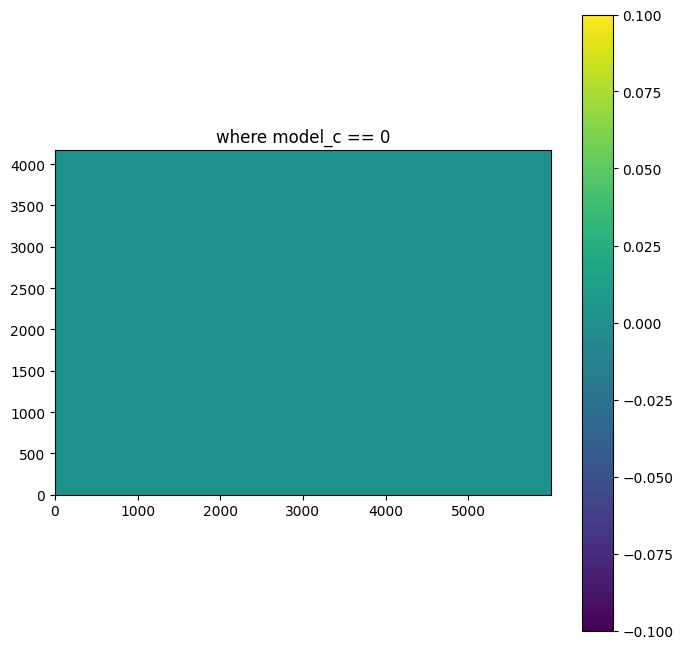

In [55]:
plt.figure(figsize=(8, 8))
plt.imshow((model_c == 0), origin="lower")
plt.title("where model_c == 0")
plt.colorbar()
plt.show()

In [56]:
h, w = resid.shape
regions = {
    "TL": resid[:h//2, :w//2],
    "TR": resid[:h//2, w//2:],
    "BL": resid[h//2:, :w//2],
    "BR": resid[h//2:, w//2:],
}

for name, arr in regions.items():
    vals = arr[np.isfinite(arr)]
    print(name,"med=" ,np.nanmedian(vals), "Mean=",np.nanmean(vals), "Std=",np.nanstd(vals))

[04:07:31] TL med= nan Mean= nan Std= nan
[04:07:31] TR med= -0.06709831151164991 Mean= -0.009720178408338642 Std= 2.1161253537494167
[04:07:32] BL med= nan Mean= nan Std= nan
[04:07:32] BR med= nan Mean= nan Std= nan


/Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/astro_env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/d4/pdhkc1y53l5bywltpcg3j0cm0000gp/T/ipykernel_32113/2357548346.py:11: RuntimeWarning: Mean of empty slice
  print(name,"med=" ,np.nanmedian(vals), "Mean=",np.nanmean(vals), "Std=",np.nanstd(vals))
/Users/zuha/Desktop/FKI/4 курс 2025-2026/course_work-SBF/astro_env/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


## Развёртка кольца SBF

In [57]:
# Runtime snapshot of the currently chosen elliptical SBF zone.
# Это не глобальный конфиг: геометрия зависит от выбранного окна выше.
unroll_sma_in = float(sma_in)
unroll_sma_out = float(sma_out)
unroll_x0 = float(x0_ann)
unroll_y0 = float(y0_ann)
unroll_q = float(q_ann)
unroll_pa = float(pa_ann)


[04:07:32] unrolling elliptical residual annulus into sub-annuli...
[04:07:32] [UNROLL] sma=720.0..790.0 px, sub_annuli=6, bins=360, pixels=204356, cutout=(1588, 1588)


,sub_annulus,sma_in_px,sma_out_px,x_ring_bin,theta_rad,resid_mean,n_pix
0,1,720.0,731.666667,0,0.008727,0.342275,91
1,1,720.0,731.666667,1,0.026180,0.272763,91
2,1,720.0,731.666667,2,0.043633,0.010731,91
3,1,720.0,731.666667,3,0.061087,1.383238,91
4,1,720.0,731.666667,4,0.078540,-0.080000,91


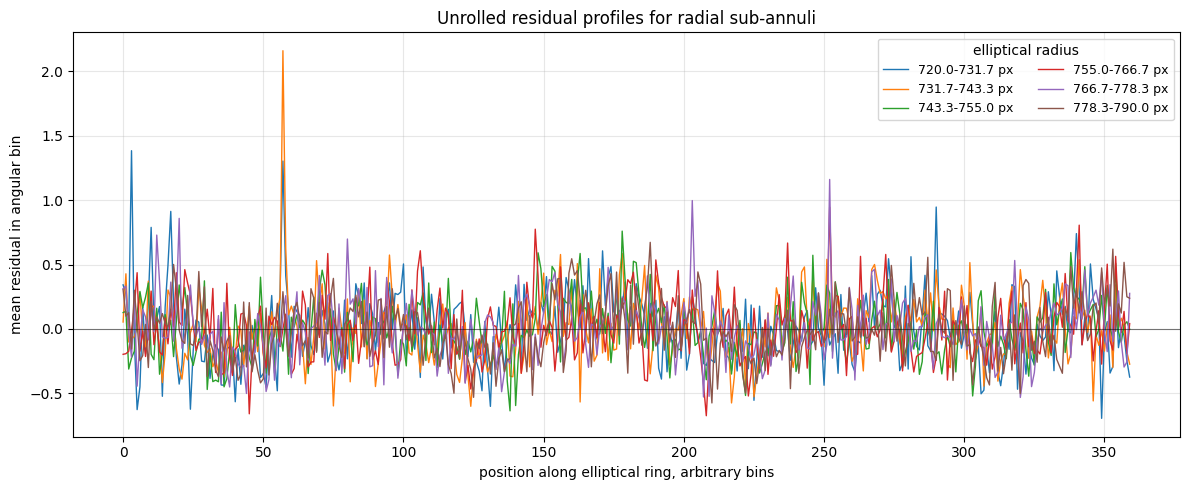

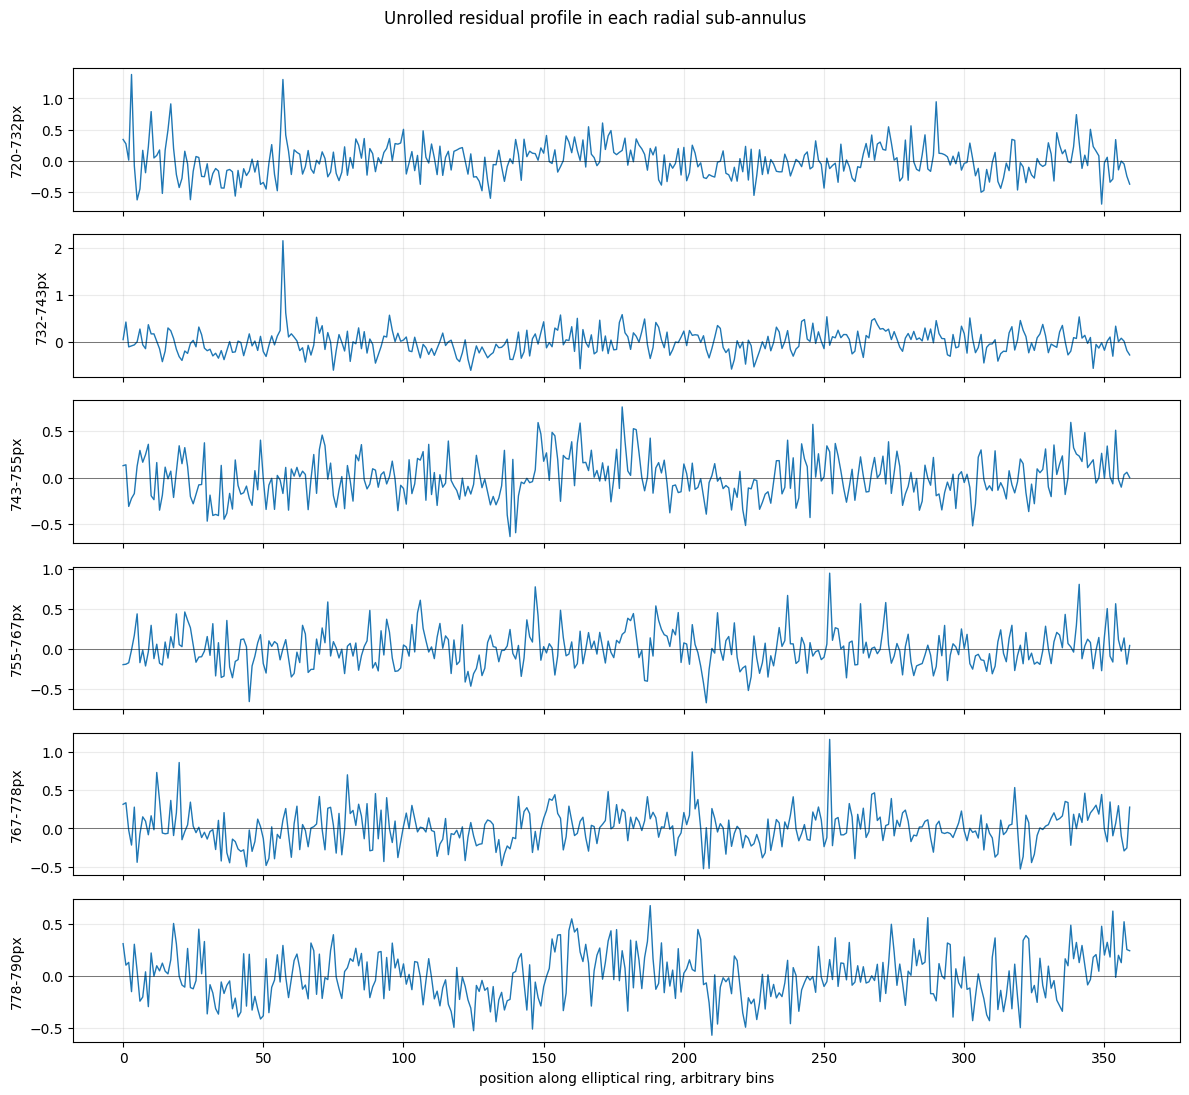

In [58]:
print("unrolling elliptical residual annulus into sub-annuli...")

# Работает только с маленьким квадратным cutout вокруг кольца, а не со всем кадром.
ny, nx = resid.shape
pad = int(np.ceil(unroll_sma_out)) + UNROLL_PAD_EXTRA
unroll_x1 = max(0, int(np.floor(unroll_x0 - pad)))
unroll_x2 = min(nx, int(np.ceil(unroll_x0 + pad + 1)))
unroll_y1 = max(0, int(np.floor(unroll_y0 - pad)))
unroll_y2 = min(ny, int(np.ceil(unroll_y0 + pad + 1)))

resid_cut = resid[unroll_y1:unroll_y2, unroll_x1:unroll_x2]
yy, xx = np.indices(resid_cut.shape, dtype=float)
xx += unroll_x1
yy += unroll_y1

# Переход в координаты эллипса.
dx = xx - unroll_x0
dy = yy - unroll_y0
cosp = np.cos(unroll_pa)
sinp = np.sin(unroll_pa)

xp = dx * cosp + dy * sinp
yp = -dx * sinp + dy * cosp
q_safe = max(unroll_q, GEOM_Q_FLOOR)

r_ell = np.sqrt(xp * xp + (yp / q_safe) ** 2)
theta = np.mod(np.arctan2(yp / q_safe, xp), 2.0 * np.pi)

use = (
    (r_ell >= unroll_sma_in) &
    (r_ell < unroll_sma_out) &
    np.isfinite(resid_cut)
)

if int(use.sum()) < UNROLL_MIN_PIXELS:
    raise RuntimeError(f"[UNROLL] too few pixels in annulus: N={int(use.sum())}")

vals = resid_cut[use]
r_vals = r_ell[use]
theta_vals = theta[use]

# X: номер сегмента вдоль кольца. Это простая координата в "попугаях".
theta_bin = np.floor(theta_vals / (2.0 * np.pi) * UNROLL_N_BINS).astype(int)
theta_bin = np.clip(theta_bin, 0, UNROLL_N_BINS - 1)

# Y/series: номер радиального под-аннулуса внутри sma_in..sma_out.
sub_id = np.floor(
    (r_vals - unroll_sma_in) / (unroll_sma_out - unroll_sma_in) * UNROLL_N_SUBANNULI
).astype(int)
sub_id = np.clip(sub_id, 0, UNROLL_N_SUBANNULI - 1)

# Один быстрый bincount по двум индексам сразу: sub-annulus × theta-bin.
flat_id = sub_id * UNROLL_N_BINS + theta_bin
n_flat = UNROLL_N_SUBANNULI * UNROLL_N_BINS
counts_2d = np.bincount(flat_id, minlength=n_flat).reshape(UNROLL_N_SUBANNULI, UNROLL_N_BINS)
sums_2d = np.bincount(flat_id, weights=vals, minlength=n_flat).reshape(UNROLL_N_SUBANNULI, UNROLL_N_BINS)
means_2d = np.divide(
    sums_2d,
    counts_2d,
    out=np.full_like(sums_2d, np.nan, dtype=float),
    where=counts_2d > 0,
)

x_bins = np.arange(UNROLL_N_BINS)
theta_centers = (x_bins + 0.5) * 2.0 * np.pi / UNROLL_N_BINS
sub_edges = np.linspace(unroll_sma_in, unroll_sma_out, UNROLL_N_SUBANNULI + 1)

unroll_rows = []
for j in range(UNROLL_N_SUBANNULI):
    unroll_rows.append(pd.DataFrame({
        "sub_annulus": j + 1,
        "sma_in_px": sub_edges[j],
        "sma_out_px": sub_edges[j + 1],
        "x_ring_bin": x_bins,
        "theta_rad": theta_centers,
        "resid_mean": means_2d[j],
        "n_pix": counts_2d[j].astype(int),
    }))

df_ring_unroll = pd.concat(unroll_rows, ignore_index=True)

print(
    f"[UNROLL] sma={unroll_sma_in:.1f}..{unroll_sma_out:.1f} px, "
    f"sub_annuli={UNROLL_N_SUBANNULI}, bins={UNROLL_N_BINS}, "
    f"pixels={int(use.sum())}, cutout={resid_cut.shape}"
)

display(df_ring_unroll.head())

plt.figure(figsize=(12, 5))
for j in range(UNROLL_N_SUBANNULI):
    row = df_ring_unroll[df_ring_unroll["sub_annulus"] == j + 1]
    label = f"{sub_edges[j]:.1f}-{sub_edges[j + 1]:.1f} px"
    plt.plot(row["x_ring_bin"], row["resid_mean"], lw=1.0, label=label)

plt.axhline(0.0, color="k", lw=0.8, alpha=0.5)
plt.xlabel("position along elliptical ring, arbitrary bins")
plt.ylabel("mean residual in angular bin")
plt.title("Unrolled residual profiles for radial sub-annuli")
plt.legend(title="elliptical radius", ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(UNROLL_N_SUBANNULI, 1, figsize=(12, 1.8 * UNROLL_N_SUBANNULI), sharex=True)
if UNROLL_N_SUBANNULI == 1:
    axes = [axes]

for j, ax in enumerate(axes):
    row = df_ring_unroll[df_ring_unroll["sub_annulus"] == j + 1]
    ax.plot(row["x_ring_bin"], row["resid_mean"], lw=1.0)
    ax.axhline(0.0, color="k", lw=0.7, alpha=0.5)
    ax.set_ylabel(f"{sub_edges[j]:.0f}-{sub_edges[j + 1]:.0f}px")
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("position along elliptical ring, arbitrary bins")
fig.suptitle("Unrolled residual profile in each radial sub-annulus", y=1.01)
plt.tight_layout()
plt.show()


[04:07:32] plotting lightly smoothed spline over unrolled annulus profiles...
[04:07:32] [unroll] spline smoothing window = 21 bins


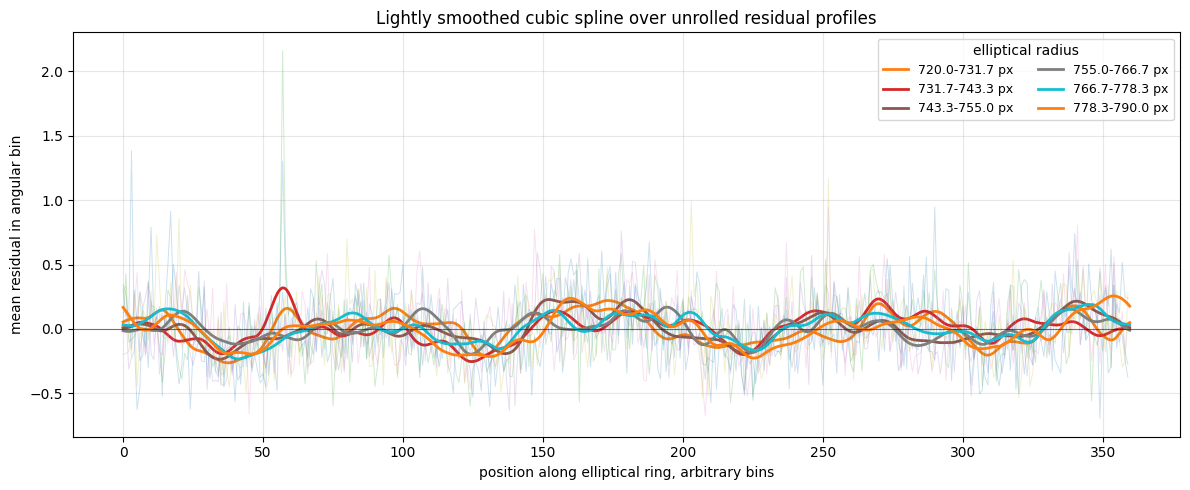

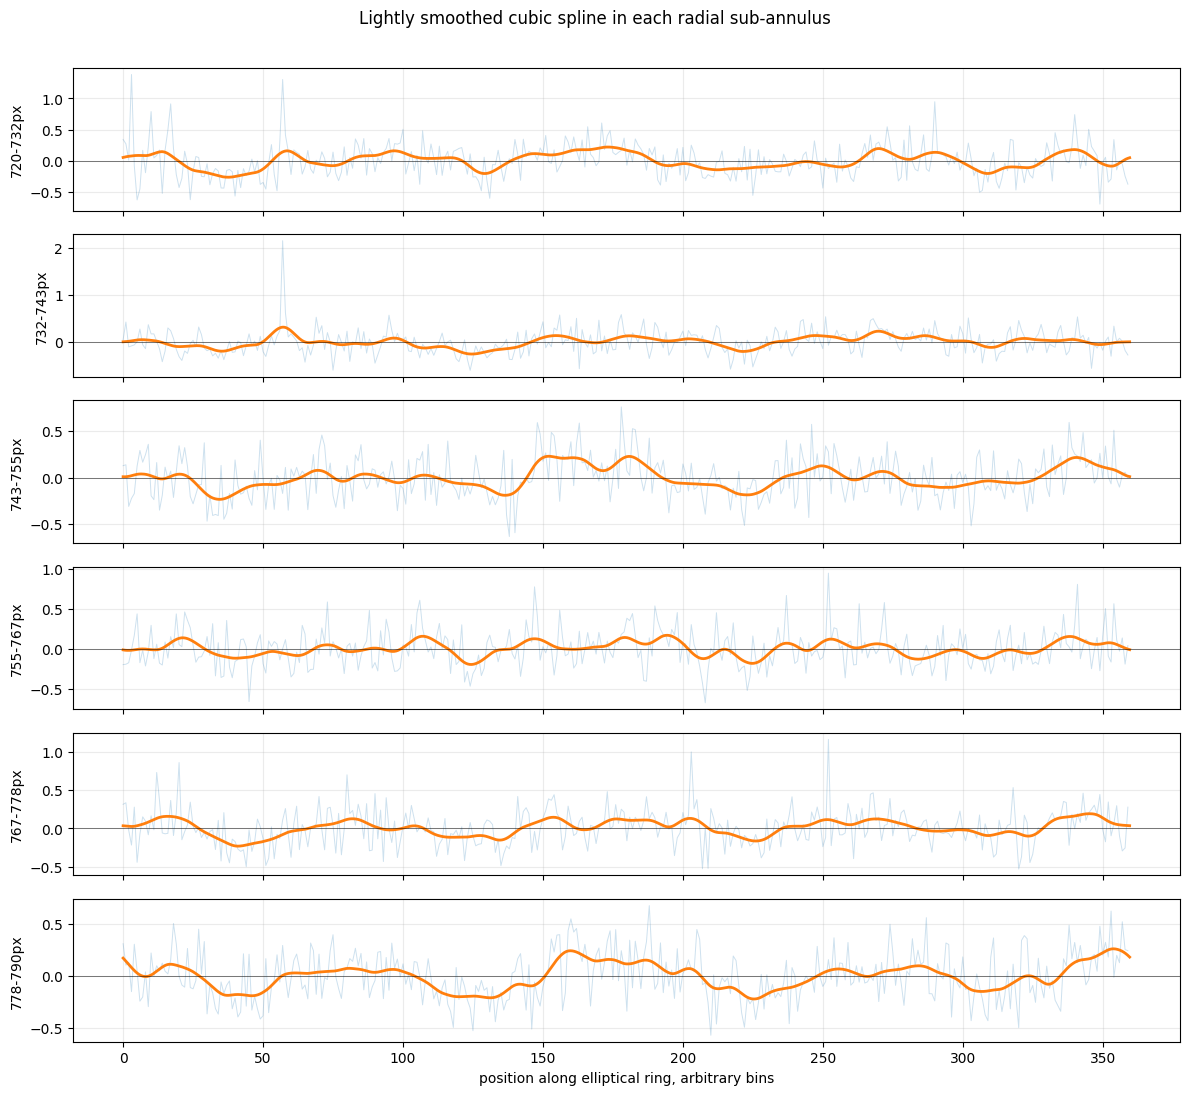

In [59]:
print("plotting lightly smoothed spline over unrolled annulus profiles...")

from scipy.interpolate import CubicSpline

# Компромиссный вариант: сначала слегка сглаживаем угловой профиль по кольцу,
# потом строим обычный CubicSpline. Это убирает зубцы, но не превращает профиль
# в почти прямую линию, как большой smoothing factor в UnivariateSpline.
def circular_hann_smooth(y, width):
    y = np.asarray(y, dtype=float)
    width = int(width)

    if width <= 1 or y.size < 3:
        return y.copy()

    if width % 2 == 0:
        width += 1

    max_width = y.size if y.size % 2 == 1 else y.size - 1
    width = max(3, min(width, max_width))

    kernel = np.hanning(width)
    if not np.any(kernel > 0):
        kernel = np.ones(width, dtype=float)
    kernel = kernel / kernel.sum()

    pad = width // 2
    y_pad = np.r_[y[-pad:], y, y[:pad]]
    return np.convolve(y_pad, kernel, mode="valid")


def periodic_cubic_spline_profile(x, y, period, n_points=None, smooth_bins=None):
    if n_points is None:
        n_points = UNROLL_SPLINE_POINTS
    if smooth_bins is None:
        smooth_bins = UNROLL_SPLINE_SMOOTH_BINS
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    if x.size < 4:
        return np.array([], dtype=float), np.array([], dtype=float)

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    # Если где-то в угловых bin нет пикселей, заполняем их линейной
    # циклической интерполяцией, чтобы CubicSpline получил регулярную сетку.
    xi = np.arange(int(period), dtype=float)
    x_ext = np.concatenate([x - period, x, x + period])
    y_ext = np.concatenate([y, y, y])
    yi = np.interp(xi, x_ext, y_ext)

    # Лёгкое циклическое сглаживание только для диагностического графика.
    # Исходные точки на графике остаются сырыми и полупрозрачными.
    yi_smooth = circular_hann_smooth(yi, smooth_bins)

    # Замыкаем кольцо: значение в x=period равно значению в x=0.
    x_closed = np.r_[xi, float(period)]
    y_closed = np.r_[yi_smooth, yi_smooth[0]]

    spline = CubicSpline(x_closed, y_closed, bc_type="periodic")
    xs = np.linspace(0.0, float(period), int(n_points), endpoint=False)
    ys = spline(xs)
    return xs, ys


period = int(UNROLL_N_BINS)
sub_edges = np.linspace(unroll_sma_in, unroll_sma_out, UNROLL_N_SUBANNULI + 1)
print(f"[unroll] spline smoothing window = {UNROLL_SPLINE_SMOOTH_BINS} bins")

plt.figure(figsize=(12, 5))
for j in range(UNROLL_N_SUBANNULI):
    row = df_ring_unroll[df_ring_unroll["sub_annulus"] == j + 1]
    label = f"{sub_edges[j]:.1f}-{sub_edges[j + 1]:.1f} px"

    plt.plot(
        row["x_ring_bin"],
        row["resid_mean"],
        lw=0.7,
        alpha=0.22,
    )

    xs, ys = periodic_cubic_spline_profile(
        row["x_ring_bin"],
        row["resid_mean"],
        period=period,
        n_points=UNROLL_SPLINE_POINTS,
        smooth_bins=UNROLL_SPLINE_SMOOTH_BINS,
    )
    if xs.size:
        plt.plot(xs, ys, lw=2.0, label=label)

plt.axhline(0.0, color="k", lw=0.8, alpha=0.5)
plt.xlabel("position along elliptical ring, arbitrary bins")
plt.ylabel("mean residual in angular bin")
plt.title("Lightly smoothed cubic spline over unrolled residual profiles")
plt.legend(title="elliptical radius", ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(UNROLL_N_SUBANNULI, 1, figsize=(12, 1.8 * UNROLL_N_SUBANNULI), sharex=True)
if UNROLL_N_SUBANNULI == 1:
    axes = [axes]

for j, ax in enumerate(axes):
    row = df_ring_unroll[df_ring_unroll["sub_annulus"] == j + 1]

    ax.plot(row["x_ring_bin"], row["resid_mean"], lw=0.7, alpha=0.22)

    xs, ys = periodic_cubic_spline_profile(
        row["x_ring_bin"],
        row["resid_mean"],
        period=period,
        n_points=UNROLL_SPLINE_POINTS,
        smooth_bins=UNROLL_SPLINE_SMOOTH_BINS,
    )
    if xs.size:
        ax.plot(xs, ys, lw=2.0)

    ax.axhline(0.0, color="k", lw=0.7, alpha=0.5)
    ax.set_ylabel(f"{sub_edges[j]:.0f}-{sub_edges[j + 1]:.0f}px")
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("position along elliptical ring, arbitrary bins")
fig.suptitle("Lightly smoothed cubic spline in each radial sub-annulus", y=1.01)
plt.tight_layout()
plt.show()
